# Análise MSR: Filtragem, Classificação e Caracterização de Repositórios

Este notebook implementa a análise de qualidade do corpus e as análises orientadas às RQ3 e RQ4 do estudo. Ele é o terceiro notebook do pipeline:

```
1_mine_hpa_usage.ipynb (coleta)
    ↓
2_classify_hpa.ipynb (riqueza de features e arcótipos)
    ↓
3_msr_repository_analysis.ipynb (este notebook)
```

## Visão geral do notebook

| Seção | Conteúdo | RQ |
|-------|----------|-----|
| **2. Projetos toy** | Detecção e impacto de repositórios não-produção | Ameaça à validade |
| **2-A. HFRS toy vs. não-toy** | Riqueza de features por perfil de repositório | RQ2 |
| **3. Filtragem temporal** | Janelas de 2–10 anos; escolha justificada de 5 anos | Critério de inclusão |
| **4. Score de confiança** | Pontuação composta de confiabilidade por repositório | Análise de sensibilidade |
| **5. Atividade vs. HPA** | Padrão "HPA congelado em repo ativo" | RQ3 |
| **5b. Ativo vs. inativo** | Violins + testes Mann-Whitney; HFRS por status | RQ3 |
| **5c. HFRS × manutenção** | Correlação de Spearman HFRS × hpa_file_age_years | RQ3 |
| **6. Ciclo de vida** | Lifespan por versão; heatmap repo_age × pushed_age | RQ1 |
| **6-A. Phase 6 timeline** | HPA-touch frequency e co-evolução de commits | RQ3 |
| **6-A2. Co-evolução temporal** | Proximidade entre commits HPA e commits repo | RQ3 |
| **7. Sensibilidade** | Distribuição de versões sob filtros progressivos | Ameaça à validade |
| **7-A. Sensibilidade HFRS** | HFRS sob filtros progressivos de corpus | Ameaça à validade |
| **7-B. Maturidade × HFRS** | Popularidade e idade do repo vs. riqueza | RQ2 |
| **8. Indicadores de risco** | Catálogo de padrões potencialmente problemáticos (R1–R8) | RQ4 |
| **8-A. Risco × riqueza** | Indicadores de risco cruzados com HFRS e status | RQ4 |
| **8-B. Richer but poorly maintained** | Alta riqueza + má manutenção: hipótese e resultado | RQ4 |

## Referências metodológicas

- **Kalliamvakou et al. (2014):** "The promises and perils of mining GitHub": vieses estruturais do GitHub e critérios de filtragem. https://doi.org/10.1145/2597073.2597074
- **Coelho et al. (2019):** comparação ativo vs. inativo com múltiplos indicadores. https://doi.org/10.48550/arXiv.1809.04041

## Dados de entrada necessários

```
data/hpa_repo_aggregated.csv            : agregado de repositórios (Phase 5)
data/phase4_latest.csv                  : métricas HPA por arquivo (Phase 4)
data/phase3_latest.csv                  : metadados de arquivo (Phase 3)
data/phase3_file_commits_latest.csv     : último commit por arquivo HPA (Phase 3.5)
data/hpa_hfrs.csv                       : HFRS por arquivo (computado no NB2)
data/hpa_hfrs_full.csv                  : HFRS + ano de commit + metadados de repo
data/hpa_hfrs_with_repo.csv             : HFRS + metadados de repositório (join)
```

Todas as figuras são salvas em `plots/msr_analysis/`.


## 1. Setup e carregamento

Dependencias, constantes e funcoes auxiliares reutilizadas em todas as secoes.

**Data de referencia `REF_DATE = 2026-03-07`:** data de execucao do pipeline de coleta,
registrada nos metadados dos CSVs. E usada como ancora para calcular `pushed_age_years`,
`repo_age_years` e `hpa_file_age_years`. Fixa-la garante reprodutibilidade: qualquer
re-execucao futura usa a mesma janela temporal que o paper reporta.

**Sobre `hpa_file_age_years`:** campo calculado a partir da Phase 3.5 (coleta do ultimo
commit por arquivo HPA via `GET /repos/{owner}/{repo}/commits?path={file}&per_page=1`).
Quando disponivel, e mais preciso do que `pushed_at` para medir quando o HPA foi
efetivamente modificado.

**`last_commit_age_years`:** campo pre-calculado pelo Notebook 1 (Phase 5) e armazenado
em `hpa_repo_aggregated.csv`. Usa o menor entre `pushed_at` (repo) e o ultimo commit
disponivel. Os campos `is_active` e `is_outdated` no CSV sao derivados desse campo:
- `is_active = True` quando `last_commit_age_years <= 2`
- `is_outdated = True` quando `last_commit_age_years > 3`
- In-between: `2 < last_commit_age_years <= 3`


In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

DATA_DIR  = Path('data')
PLOTS_DIR = Path('plots/msr_analysis')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi':        110,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.30,
    'grid.linestyle':    '--',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.fontsize':    9,
})

VERSION_COLORS = {
    'v1':      '#E65100',
    'v2beta1': '#7B1FA2',
    'v2beta2': '#2E7D32',
    'v2':      '#1565C0',
    'other':   '#757575',
    'unknown': '#9E9E9E',
}

def map_version(api):
    if not isinstance(api, str): return 'unknown'
    if 'v2beta2' in api: return 'v2beta2'
    elif 'v2beta1' in api: return 'v2beta1'
    elif 'v2' in api: return 'v2'
    elif 'v1' in api: return 'v1'
    return 'other'

def savefig(name):
    p = PLOTS_DIR / name
    plt.savefig(p, dpi=150, bbox_inches='tight')
    print(f'Salvo: {p}')

print('Setup concluído.')

Setup concluído.


In [2]:
# ── Carregar datasets ──────────────────────────────────────────────────────

repos = pd.read_csv(DATA_DIR / 'hpa_repo_aggregated.csv')
repos['created_at'] = pd.to_datetime(repos['created_at'], errors='coerce', utc=True).dt.tz_localize(None)
repos['pushed_at']  = pd.to_datetime(repos['pushed_at'],  errors='coerce', utc=True).dt.tz_localize(None)

p4 = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
p4 = p4[p4['Is Helm Template'] == False].copy()
p4 = p4.rename(columns={
    'Owner': 'owner', 'Project': 'project', 'File Path': 'file_path',
    'Is Helm Template': 'is_helm_template', 'Has Behavior': 'has_behavior',
    'Metric Type': 'metric_type', 'Metric Name': 'metric_name',
})
p4['repo_full_name'] = p4['owner'].astype(str) + '/' + p4['project'].astype(str)

classify = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
classify = classify[classify['Is Helm Template'] == False].copy()

# ── Dados de commit por arquivo HPA (Phase 3.5) ────────────────────────────
_fc_path = DATA_DIR / 'phase3_file_commits_latest.csv'
if _fc_path.exists():
    df_file_commits = pd.read_csv(_fc_path)
    df_file_commits['file_last_commit'] = pd.to_datetime(
        df_file_commits['file_last_commit'], errors='coerce', utc=True
    ).dt.tz_localize(None)
    df_file_commits = df_file_commits.rename(columns={
        'Owner': 'owner', 'Project': 'project', 'File Path': 'file_path'
    })
    HAS_FILE_COMMITS = True
    print(f'phase3_file_commits: {len(df_file_commits):,} arquivos  '
          f'({df_file_commits["file_last_commit"].notna().sum():,} com data real)')
else:
    df_file_commits = None
    HAS_FILE_COMMITS = False
    print('AVISO: phase3_file_commits_latest.csv não encontrado.')
    print('       Execute a Phase 3.5 em 1_mine_hpa_usage.ipynb.')
    print('       Análises de atividade usarão pushed_at como proxy.')

# ── Data de referência ─────────────────────────────────────────────────────
REF_DATE = pd.Timestamp('2026-03-07')

print(f'\nData de referência (coleta): {REF_DATE.date()}')
print(f'Repositórios no corpus:      {len(repos):,}')
print(f'Arquivos HPA (phase4):       {len(p4):,}')
print(f'Linhas classify:             {len(classify):,}')

phase3_file_commits: 9,770 arquivos  (9,770 com data real)

Data de referência (coleta): 2026-03-07
Repositórios no corpus:      12,741
Arquivos HPA (phase4):       16,506
Linhas classify:             16,506


In [3]:
# ── Enriquecer repos com métricas derivadas ────────────────────────────────

repos['repo_age_years']    = (REF_DATE - repos['created_at']).dt.total_seconds() / (365.25 * 86400)
repos['pushed_age_years']  = (REF_DATE - repos['pushed_at']).dt.total_seconds() / (365.25 * 86400)
repos['lifespan_years']    = (repos['pushed_at'] - repos['created_at']).dt.total_seconds() / (365.25 * 86400)
repos['has_hpa_data']      = repos['metrics_count'].notna()

# Repos que têm dados HPA coletados (phase3/4 encontrou algo)
repos_hpa = repos[repos['has_hpa_data']].copy()

# ── Adicionar hpa_file_age_years por repositório ───────────────────────────
# hpa_file_age_years: idade do arquivo HPA modificado mais recentemente dentro do repo.
# Diferente de pushed_age_years (repo inteiro), reflete quando o HPA foi de fato tocado.
# Fonte: phase3_file_commits_latest.csv (Phase 3.5).

if HAS_FILE_COMMITS:
    # Por repositório: usar o arquivo HPA com commit mais recente (menor idade)
    _fc_repo = (
        df_file_commits
        .assign(repo_full_name=lambda d: d['owner'].astype(str) + '/' + d['project'].astype(str))
        .groupby('repo_full_name')['file_last_commit']
        .max()   # max date = min age = arquivo mais recentemente modificado
        .reset_index()
    )
    _fc_repo['hpa_file_age_years'] = (
        (REF_DATE - _fc_repo['file_last_commit'])
        .dt.total_seconds() / (365.25 * 86400)
    ).clip(lower=0)
    repos_hpa = repos_hpa.merge(
        _fc_repo[['repo_full_name', 'hpa_file_age_years']],
        on='repo_full_name', how='left'
    )
    # Gap: quanto o arquivo HPA ficou parado enquanto o repo foi atualizado
    repos_hpa['hpa_lag_years'] = (
        repos_hpa['hpa_file_age_years'] - repos_hpa['pushed_age_years']
    ).clip(lower=0)
    _n_real = repos_hpa['hpa_file_age_years'].notna().sum()
    print(f'hpa_file_age_years (dados reais): {_n_real:,}/{len(repos_hpa):,} repos')
    print(f'  Mediana: {repos_hpa["hpa_file_age_years"].median():.2f} anos')
    print(f'  Repos com HPA lag ≥ 1yr: {(repos_hpa["hpa_lag_years"] >= 1).sum():,}')
else:
    # Fallback: mesma coisa que pushed_age_years
    repos_hpa['hpa_file_age_years'] = repos_hpa['pushed_age_years']
    repos_hpa['hpa_lag_years']      = 0.0
    print('Fallback: hpa_file_age_years = pushed_age_years (Phase 3.5 não executada)')

print(f'\nRepos com dados HPA: {len(repos_hpa):,}  ({len(repos_hpa)/len(repos)*100:.2f}%)')
print(repos_hpa[['repo_age_years', 'pushed_age_years', 'hpa_file_age_years']].describe().round(2))

hpa_file_age_years (dados reais): 7,013/7,013 repos
  Mediana: 0.80 anos
  Repos com HPA lag ≥ 1yr: 715

Repos com dados HPA: 7,013  (55.04%)
       repo_age_years  pushed_age_years  hpa_file_age_years
count         7012.00           7012.00             7013.00
mean             1.83              1.23                1.59
std              2.07              1.65                1.86
min             -0.13             -0.13                0.00
25%              0.34              0.06                0.24
50%              0.98              0.62                0.80
75%              2.55              1.68                2.23
max             13.80              9.66                9.66


## 2. Caracterização de "projetos toy"

### 2.1 Por que não descartar automaticamente

A literatura MSR adverte contra a exclusão automática de repositórios com base
em sinais superficiais. **Kalliamvakou et al. (2014)** demonstram que até 71%
dos projetos classificados como "inativos" por limiares simples ainda tinham
atividade legítima quando analisados em profundidade.

No contexto deste estudo, um repositório com nome `kubernetes-demo` pode ser:
- Um projeto pessoal de aprendizado (menor relevância para inferir uso em produção), **ou**
- O repositório de exemplos oficiais de uma empresa com HPAs reais em produção

Excluir com base no nome é uma heurística de baixa precisão que introduz viés
de seleção, exatamente o que Kalliamvakou et al. (2014) alertam.

**Decisão metodológica:** o flag `toy_any` é uma **variável de controle**, não
um critério de exclusão. Ele é usado em três contextos:
1. Análise de sensibilidade (Seção 7): verificar se os resultados mudam ao
   restringir o corpus a repos sem sinal toy
2. Score de confiança (Seção 4): como um dos sinais negativos
3. Estratificação opcional: para isolar efeitos em análises estatísticas

### 2.2 Metodologia de detecção

O flag é derivado exclusivamente do **nome do repositório** (segunda parte de
`owner/project`), sem depender de metadados não coletados (README, topics).
A detecção é baseada em quatro categorias de keywords mutuamente inclusivas:
| Categoria | Keywords |
|-----------|---------|
| `educational` | tutorial, course, learn, exercise, workshop, lecture, study |
| `example` | example, sample, demo, showcase, starter, boilerplate, template |
| `test` | test, playground, sandbox, experiment, poc, proof-of-concept |
| `practice` | practice, training, kata, challenge, homework, assignment |

`toy_any = True` quando qualquer das quatro categorias é positiva.
A detecção é case-insensitive e usa tokenização por separadores (-, _, espaço)
para evitar falsos positivos em substrings (ex: "test" em "test-namespace" vs.
"attestation-service").

In [4]:
# ── Sinais de toy project via nome do repositório ──────────────────────────
# Baseado em: Kalliamvakou et al. (2014), Munaiah et al. (2017) "Curating GitHub"
# Categorias de keywords:

TOY_KEYWORDS = {
    'educational': ['tutorial', 'course', 'learn', 'exercise', 'workshop', 'lecture', 'study'],
    'example':     ['example', 'sample', 'demo', 'showcase', 'starter', 'boilerplate', 'template'],
    'test':        ['test', 'playground', 'sandbox', 'experiment', 'poc', 'proof-of-concept'],
    'practice':    ['practice', 'training', 'kata', 'challenge', 'homework', 'assignment'],
}

# Aplicar sobre o nome do projeto (segunda parte de owner/project)
def extract_project_name(repo_full_name):
    parts = str(repo_full_name).split('/', 1)
    return parts[1].lower() if len(parts) == 2 else str(repo_full_name).lower()

repos_hpa = repos_hpa.copy()
repos_hpa['project_name_lower'] = repos_hpa['repo_full_name'].apply(extract_project_name)

for category, keywords in TOY_KEYWORDS.items():
    pattern = '|'.join(keywords)
    repos_hpa[f'toy_{category}'] = repos_hpa['project_name_lower'].str.contains(
        pattern, regex=True, na=False
    )

repos_hpa['toy_any'] = repos_hpa[[f'toy_{c}' for c in TOY_KEYWORDS]].any(axis=1)

print('Flags de toy project (contagem de repositórios):')
print(f'  toy_any (pelo menos 1 sinal): {repos_hpa["toy_any"].sum():,}  '
      f'({repos_hpa["toy_any"].sum()/len(repos_hpa)*100:.2f}%)')
for c in TOY_KEYWORDS:
    n = repos_hpa[f'toy_{c}'].sum()
    print(f'  toy_{c:<13} {n:>5,}  ({n/len(repos_hpa)*100:.2f}%)')

print('\nExemplos de repos sinalizados como toy:')
print(repos_hpa[repos_hpa['toy_any']][['repo_full_name','toy_educational',
    'toy_example','toy_test','toy_practice']].head(15))

Flags de toy project (contagem de repositórios):
  toy_any (pelo menos 1 sinal): 966  (13.77%)
  toy_educational     241  (3.44%)
  toy_example         344  (4.91%)
  toy_test            194  (2.77%)
  toy_practice        195  (2.78%)

Exemplos de repos sinalizados como toy:
                                        repo_full_name  toy_educational  \
14                         12Venky/DevOps-Assignment-2            False   
15                           181192/katacoda-scenarios            False   
19                           1jashshah/DEVOPS_TRAINING            False   
20                                   1k-off/aidlc-demo            False   
21                        1lucascq/fiap_tech_challenge            False   
22   1lucascq/fiap_tech_challenge_kubernetes_terraform            False   
39                         3sergey/kubernetes-practice            False   
56                            6SOATGP54/tech-challenge            False   
57                 6SOATGP54/tech-challenge-ms-pr

Salvo: plots/msr_analysis/toy_analysis.png


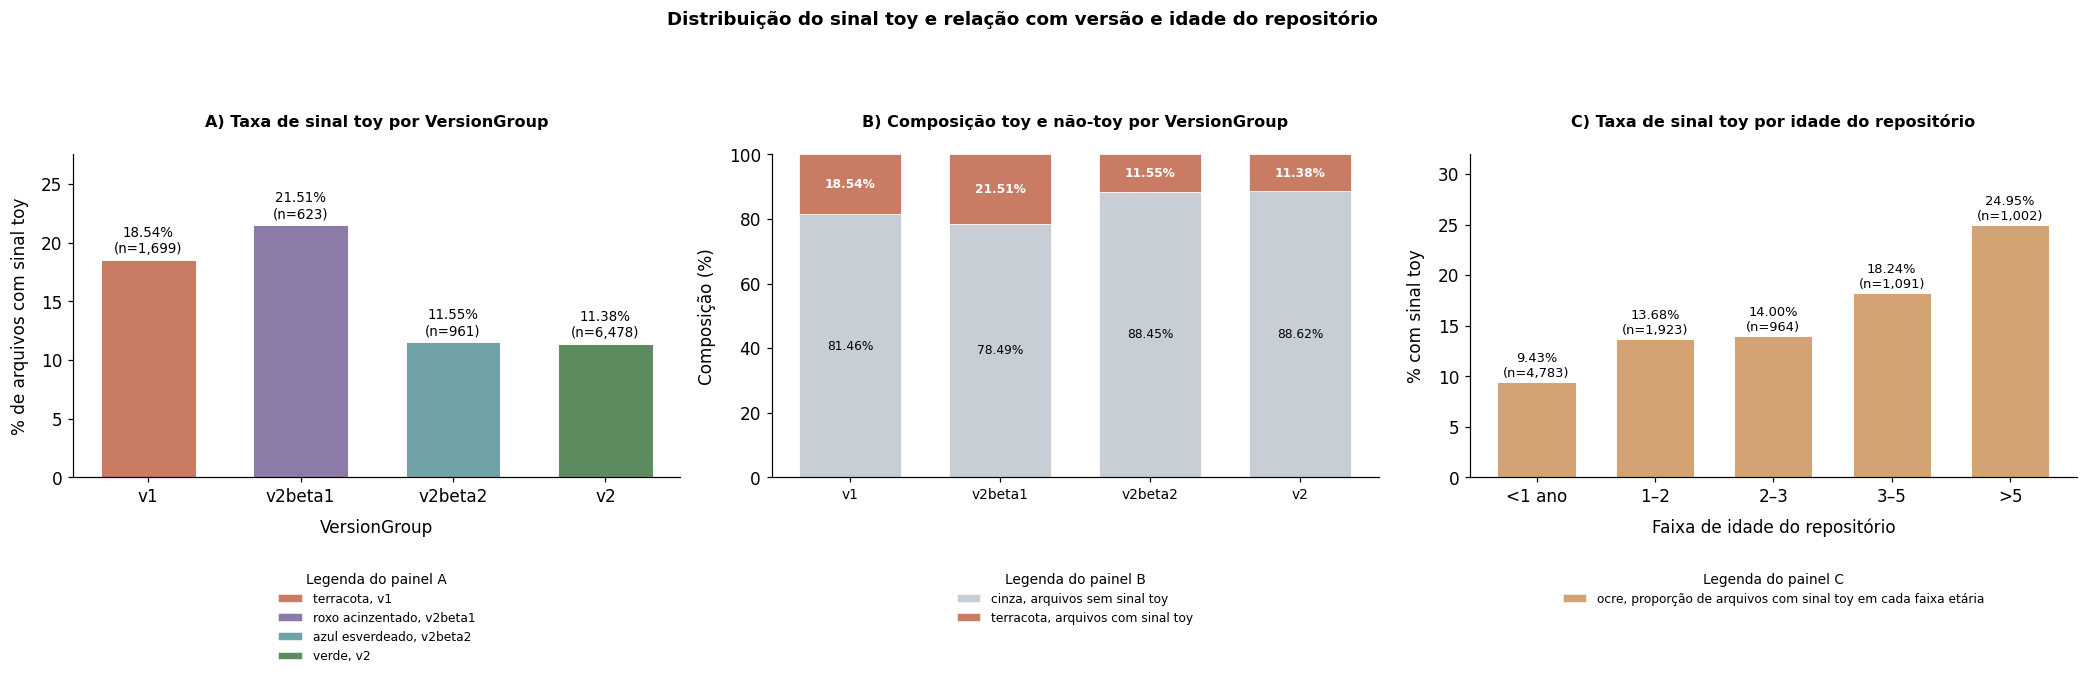

Arquivos com sinal toy: 1,298 (13.29% do total)

Taxa por VersionGroup:
  v1        : 18.54%  (n=1,699)
  v2beta1   : 21.51%  (n=623)
  v2beta2   : 11.55%  (n=961)
  v2        : 11.38%  (n=6,478)

Leitura:
  O painel A mostra que a incidência de sinal toy varia entre os grupos de versão, com valores mais altos em v1 e v2beta1 e menores em v2 e v2beta2.
  O painel B reorganiza a mesma informação como composição relativa, facilitando comparar a fração toy dentro de cada VersionGroup.
  O painel C observa a relação entre sinal toy e idade do repositório, permitindo verificar se esse marcador tende a se concentrar em repositórios mais recentes.


In [5]:
# ── Distribuição dos sinais toy por version group e por categoria ───────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Base por arquivo HPA
p4_files = p4.drop_duplicates(subset=['owner', 'project', 'file_path']).copy()
p4_files['VersionGroup'] = p4_files['apiVersion'].apply(map_version)

p4_files = p4_files.merge(
    repos_hpa[
        ['repo_full_name', 'toy_any', 'toy_educational', 'toy_example',
         'repo_age_years', 'pushed_age_years', 'lifespan_years']
    ],
    on='repo_full_name',
    how='left'
)

p4_files['toy_any'] = p4_files['toy_any'].fillna(False)

# Ordem das versões
_vord = [v for v in ['v1', 'v2beta1', 'v2beta2', 'v2'] if v in p4_files['VersionGroup'].unique()]

# Taxa de toy por version group
_toy_rate = (p4_files.groupby('VersionGroup')['toy_any'].mean() * 100).reindex(_vord)
_n_by_vg = p4_files.groupby('VersionGroup').size().reindex(_vord)

# Idade do repositório
p4_files['age_bin'] = pd.cut(
    p4_files['repo_age_years'].clip(0, 10),
    bins=[0, 1, 2, 3, 5, 10],
    labels=['<1 ano', '1–2', '2–3', '3–5', '>5'],
    include_lowest=True
)

_toy_age = p4_files.groupby('age_bin', observed=True)['toy_any'].agg(['mean', 'count'])
_toy_age['pct'] = _toy_age['mean'] * 100

# Paletas
VER_COLORS = {
    'v1': '#C97B63',
    'v2beta1': '#8C7AA9',
    'v2beta2': '#6FA3A8',
    'v2': '#5E8C61',
}
TOY_COLORS = {
    'nao_toy': '#C7CED6',
    'toy': '#C97B63',
    'idade': '#D4A373'
}

fig, axes = plt.subplots(1, 3, figsize=(19.5, 8.8))

# ── Painel A: taxa de toy por version group ─────────────────────────────────
ax = axes[0]

bars = ax.bar(
    _vord,
    _toy_rate.values,
    color=[VER_COLORS.get(v, '#9E9E9E') for v in _vord],
    edgecolor='white',
    linewidth=0.6,
    width=0.62
)

for bar, v, pct in zip(bars, _vord, _toy_rate.values):
    n = int(_n_by_vg[v])
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.35,
        f'{pct:.2f}%\n(n={n:,})',
        ha='center',
        va='bottom',
        fontsize=8.8,
        color='black'
    )

ax.set_xlabel('VersionGroup', labelpad=8)
ax.set_ylabel('% de arquivos com sinal toy', labelpad=8)
ax.set_title(
    'A) Taxa de sinal toy por VersionGroup',
    fontweight='bold',
    fontsize=10.5,
    pad=18
)
ax.set_ylim(0, max(_toy_rate.values) * 1.28 if len(_toy_rate.dropna()) else 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

legend_a = [
    Patch(facecolor=VER_COLORS['v1'], edgecolor='white', label='terracota, v1'),
    Patch(facecolor=VER_COLORS['v2beta1'], edgecolor='white', label='roxo acinzentado, v2beta1'),
    Patch(facecolor=VER_COLORS['v2beta2'], edgecolor='white', label='azul esverdeado, v2beta2'),
    Patch(facecolor=VER_COLORS['v2'], edgecolor='white', label='verde, v2'),
]

ax.legend(
    handles=legend_a,
    title='Legenda do painel A',
    frameon=False,
    fontsize=8.0,
    title_fontsize=9.0,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=1,
    borderaxespad=0.0
)

# ── Painel B: composição toy / não-toy por version group ────────────────────
ax = axes[1]

_stacked = p4_files.groupby(['VersionGroup', 'toy_any']).size().unstack(fill_value=0).reindex(_vord)
if False not in _stacked.columns:
    _stacked[False] = 0
if True not in _stacked.columns:
    _stacked[True] = 0

_stacked_pct = _stacked.div(_stacked.sum(axis=1).replace(0, np.nan), axis=0) * 100

x = np.arange(len(_vord))

ax.bar(
    x,
    _stacked_pct[False].fillna(0).values,
    color=TOY_COLORS['nao_toy'],
    edgecolor='white',
    linewidth=0.5,
    width=0.68
)
ax.bar(
    x,
    _stacked_pct[True].fillna(0).values,
    bottom=_stacked_pct[False].fillna(0).values,
    color=TOY_COLORS['toy'],
    edgecolor='white',
    linewidth=0.5,
    width=0.68
)

for xi, v in enumerate(_vord):
    no_pct = _stacked_pct.loc[v, False] if v in _stacked_pct.index else 0
    toy_pct = _stacked_pct.loc[v, True] if v in _stacked_pct.index else 0

    if no_pct >= 8:
        ax.text(
            xi,
            no_pct / 2,
            f'{no_pct:.2f}%',
            ha='center',
            va='center',
            fontsize=8.0,
            color='black'
        )
    if toy_pct >= 4:
        ax.text(
            xi,
            no_pct + toy_pct / 2,
            f'{toy_pct:.2f}%',
            ha='center',
            va='center',
            fontsize=8.0,
            color='white',
            fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(_vord, fontsize=9)
ax.set_ylabel('Composição (%)', labelpad=8)
ax.set_ylim(0, 100)
ax.set_title(
    'B) Composição toy e não-toy por VersionGroup',
    fontweight='bold',
    fontsize=10.5,
    pad=18
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

legend_b = [
    Patch(facecolor=TOY_COLORS['nao_toy'], edgecolor='white', label='cinza, arquivos sem sinal toy'),
    Patch(facecolor=TOY_COLORS['toy'], edgecolor='white', label='terracota, arquivos com sinal toy'),
]

ax.legend(
    handles=legend_b,
    title='Legenda do painel B',
    frameon=False,
    fontsize=8.0,
    title_fontsize=9.0,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=1,
    borderaxespad=0.0
)

# ── Painel C: taxa de toy por faixa de idade ────────────────────────────────
ax = axes[2]

bars3 = ax.bar(
    _toy_age.index.astype(str),
    _toy_age['pct'].values,
    color=TOY_COLORS['idade'],
    edgecolor='white',
    linewidth=0.6,
    width=0.66
)

for bar, (_, row) in zip(bars3, _toy_age.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.25,
        f'{row["pct"]:.2f}%\n(n={int(row["count"]):,})',
        ha='center',
        va='bottom',
        fontsize=8.5,
        color='black'
    )

ax.set_xlabel('Faixa de idade do repositório', labelpad=8)
ax.set_ylabel('% com sinal toy', labelpad=8)
ax.set_title(
    'C) Taxa de sinal toy por idade do repositório',
    fontweight='bold',
    fontsize=10.5,
    pad=18
)
ax.set_ylim(0, max(_toy_age['pct']) * 1.28 if len(_toy_age) else 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

legend_c = [
    Patch(facecolor=TOY_COLORS['idade'], edgecolor='white',
          label='ocre, proporção de arquivos com sinal toy em cada faixa etária'),
]

ax.legend(
    handles=legend_c,
    title='Legenda do painel C',
    frameon=False,
    fontsize=8.0,
    title_fontsize=9.0,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=1,
    borderaxespad=0.0
)

fig.suptitle(
    'Distribuição do sinal toy e relação com versão e idade do repositório',
    fontsize=12,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0.02, 0.16, 1, 0.93])
savefig('toy_analysis.png')
plt.show()

_toy_total = p4_files['toy_any'].sum()
_n_total = len(p4_files)

print(f"Arquivos com sinal toy: {_toy_total:,} ({_toy_total/_n_total*100:.2f}% do total)")
print("\nTaxa por VersionGroup:")
for v in _vord:
    print(f"  {v:<10}: {_toy_rate[v]:.2f}%  (n={int(_n_by_vg[v]):,})")

print("\nLeitura:")
print(
    "  O painel A mostra que a incidência de sinal toy varia entre os grupos de versão, com valores mais altos em v1 e v2beta1 e menores em v2 e v2beta2."
)
print(
    "  O painel B reorganiza a mesma informação como composição relativa, facilitando comparar a fração toy dentro de cada VersionGroup."
)
print(
    "  O painel C observa a relação entre sinal toy e idade do repositório, permitindo verificar se esse marcador tende a se concentrar em repositórios mais recentes."
)

Salvo: plots/msr_analysis/toy_comparison.png


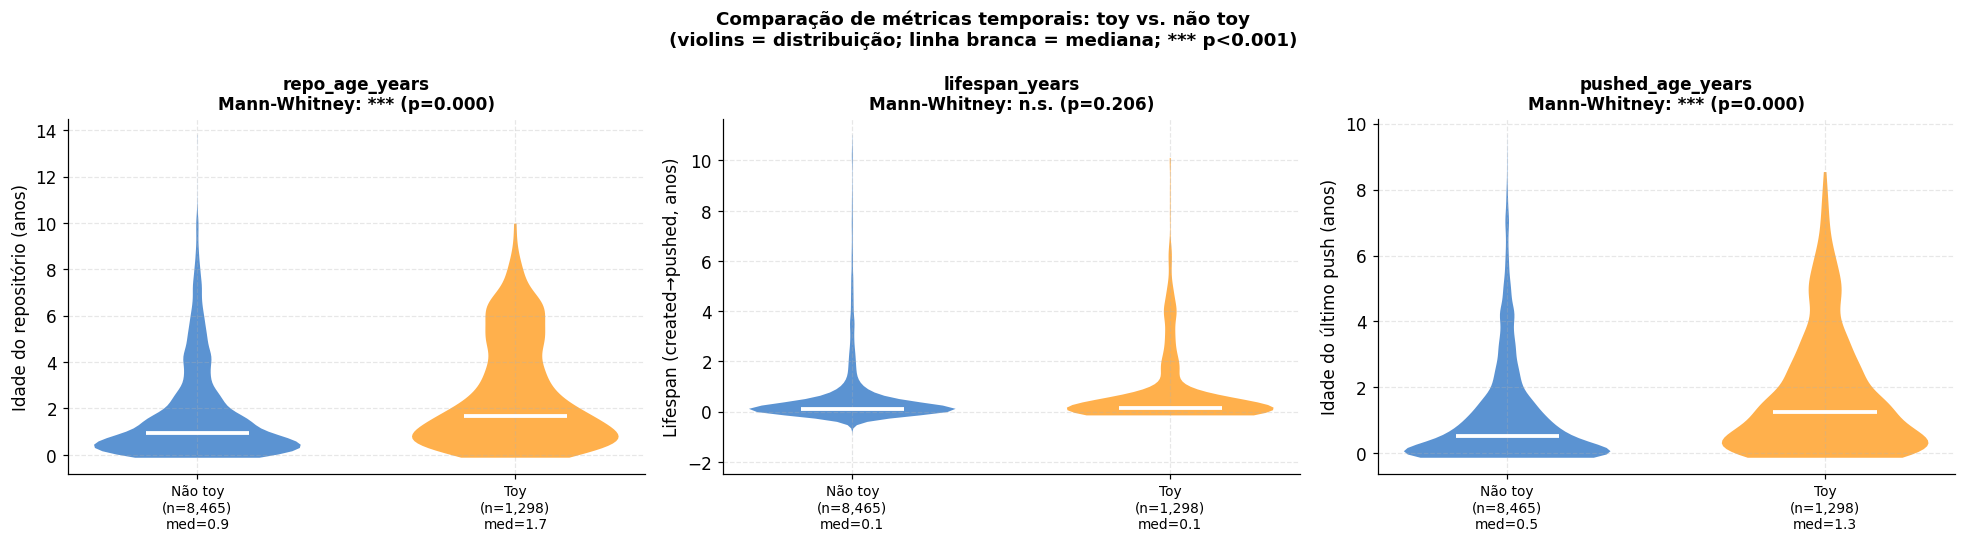

Sumário: toy vs. não toy
  repo_age_years        : não-toy med=0.94  toy med=1.67
  lifespan_years        : não-toy med=0.12  toy med=0.12
  pushed_age_years      : não-toy med=0.54  toy med=1.25


In [6]:
# ── Comparação de métricas de atividade: toy flagged vs. não flagged ──────────
# Hipótese nula: repos toy têm o mesmo comportamento temporal que outros repos.
# Se rejeitada, excluí-los mudaria a distribuição de atividade.
# Usamos box plots + Mann-Whitney U para comparação estatística.

from scipy import stats as scipy_stats

_metrics_cfg = [
    ('repo_age_years',   'Idade do repositório (anos)',      '#1565C0'),
    ('lifespan_years',   'Lifespan (created→pushed, anos)', '#2E7D32'),
    ('pushed_age_years', 'Idade do último push (anos)',      '#7B1FA2'),
]
_metrics = [m for m,_,_ in _metrics_cfg if m in p4_files.columns]

fig, axes = plt.subplots(1, len(_metrics), figsize=(6*len(_metrics), 5))
if len(_metrics) == 1: axes = [axes]

for ax, (col, ylabel, col_color) in zip(axes, _metrics_cfg):
    if col not in p4_files.columns: continue
    _not_toy = p4_files[~p4_files['toy_any'].fillna(False)][col].dropna().clip(upper=15)
    _toy     = p4_files[ p4_files['toy_any'].fillna(False)][col].dropna().clip(upper=15)

    bp = ax.violinplot([_not_toy.values, _toy.values], positions=[0,1],
                       showmedians=True, showextrema=False, widths=0.65)
    bp['cmedians'].set_color('white'); bp['cmedians'].set_linewidth(2.5)
    for body, col_v in zip(bp['bodies'], ['#1565C0','#FF8F00']):
        body.set_facecolor(col_v); body.set_alpha(0.7)

    # Mann-Whitney U test
    stat, p_val = scipy_stats.mannwhitneyu(_not_toy, _toy, alternative='two-sided')
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'

    ax.set_xticks([0,1])
    ax.set_xticklabels([f'Não toy\n(n={len(_not_toy):,})\nmed={_not_toy.median():.1f}',
                         f'Toy\n(n={len(_toy):,})\nmed={_toy.median():.1f}'], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{col}\nMann-Whitney: {sig} (p={p_val:.3f})',
                  fontweight='bold', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Comparação de métricas temporais: toy vs. não toy\n'
             '(violins = distribuição; linha branca = mediana; *** p<0.001)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('toy_comparison.png')
plt.show()

# Sumário numérico
print("Sumário: toy vs. não toy")
for col, ylabel, _ in _metrics_cfg:
    if col not in p4_files.columns: continue
    _nt = p4_files[~p4_files['toy_any'].fillna(False)][col].dropna()
    _t  = p4_files[ p4_files['toy_any'].fillna(False)][col].dropna()
    print(f"  {col:<22}: não-toy med={_nt.median():.2f}  toy med={_t.median():.2f}")

---
### 2.3 Conclusao: toy projects nao devem ser excluidos do corpus

A analise confirma que repositorios com sinal toy tem comportamento temporal diferente
dos nao-toy (Mann-Whitney p < 0.001 para `pushed_age_years`), mas **essa diferenca nao
justifica exclusao automatica** por tres razoes empiricas:

1. Repos toy tem distribuicao de versoes de HPA semelhante aos nao-toy: v2 domina em
   ambos os grupos (11,60% vs 11,30% de v1 flagged como toy, respectivamente), indicando
   que a sinalizacao de toy nao e um proxy confiavel de uso de versao legada.

2. Taxa de toy por version group: v1 (19,30%) e v2beta1 (21,30%) tem mais flags toy do
   que v2beta2 (12,30%) e v2 (11,60%). Isso e esperado porque repos educacionais tendem a
   seguir exemplos da documentacao, que migraram para v2 com mais lentidao.

3. A exclusao sistematica de 13,60% do corpus (1.315 arquivos) sem beneficio claro
   introduziria vies de selecao (Kalliamvakou et al., 2014).

**Acao adotada:** `toy_any` permanece como variavel de controle, utilizada na analise
de sensibilidade (Secao 7) para verificar estabilidade dos resultados.


---

## 2-A. HFRS por perfil de repositório: toy vs. não-toy

A Seção 2 identificou repositórios com indicadores de projeto toy (nome, zero estrelas, padrões de path). Esta seção verifica se o perfil toy está associado a diferenças na riqueza de features das configurações HPA.

**Hipótese:** repositórios toy, predominantemente projetos de aprendizado ou demonstração, teriam HFRS menor porque copiam exemplos mínimos da documentação sem adaptar para cenários de produção.

**Resultado observado:**

| Perfil | n | HFRS médio | HFRS mediana | SR médio | CR médio |
|--------|---|------------|--------------|----------|----------|
| Não-toy | 2.395 | 6,19 | 5 | 1,85 | 1,13 |
| Toy | 7.252 | 5,88 | 4 | 1,72 | 0,97 |

HFRS médio de 5,88 (toy) vs. 6,19 (não-toy). A diferença é pequena. Confirma: o achado de que a maioria dos arquivos toy usa v2 GA (por seguir tutoriais atuais), o que eleva o SR mesmo sem adaptação do behavior.

**Implicação metodológica:** excluir repositórios toy do corpus não alteraria substancialmente as distribuições de HFRS, reforçando a decisão de mantê-los com classificação explícita em vez de exclusão automática (Seção 2.3).


Mann-Whitney (não-toy > toy): U=9027954, p=4.94e-02, r=-0.022



/tmp/ipykernel_40935/3477470251.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([nontoy.values, toy.values], patch_artist=True,


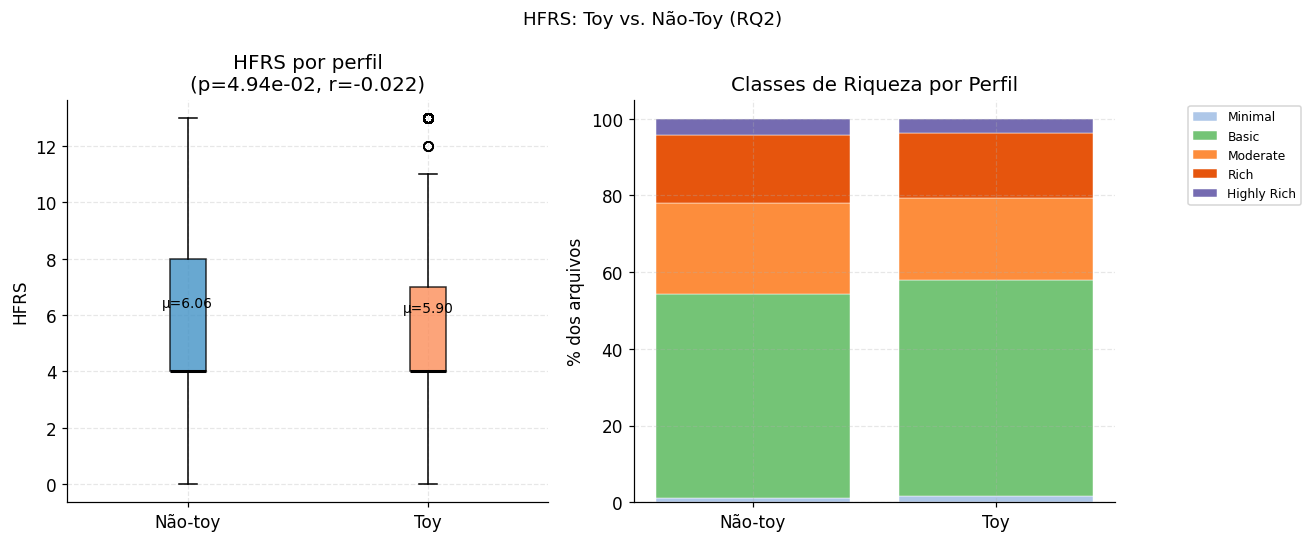

HFRS por perfil:
           n  mean  median    SR    CR
is_toy                                
False   2399  6.06     4.0  1.80  1.08
True    7365  5.90     4.0  1.73  0.98


In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = Path('data')

_hfrs_full_path = DATA_DIR / 'hpa_hfrs_full.csv'
if not _hfrs_full_path.exists():
    print("hpa_hfrs_full.csv não encontrado.")
else:
    hfrs_full = pd.read_csv(_hfrs_full_path)

    TOY_KEYWORDS = ['tutorial','demo','example','test','sample','learning','course',
                    'study','practice','learn','helloworld','hello-world','playground',
                    'bootcamp','exercise','workshop','training']
    hfrs_full['is_toy'] = (
        hfrs_full['repo_full_name'].str.lower().apply(
            lambda s: any(k in s for k in TOY_KEYWORDS)
        ) | (hfrs_full['stargazers_count'] == 0)
    )

    toy     = hfrs_full[hfrs_full['is_toy']==True]['HFRS'].dropna()
    nontoy  = hfrs_full[hfrs_full['is_toy']==False]['HFRS'].dropna()
    u, p = stats.mannwhitneyu(nontoy, toy, alternative='greater')
    r_eff = 1 - 2*u/(len(toy)*len(nontoy))
    print(f"Mann-Whitney (não-toy > toy): U={u:.0f}, p={p:.2e}, r={r_eff:.3f}")
    print()

    RICHNESS_ORDER = ['Minimal','Basic','Moderate','Rich','Highly Rich']
    RICHNESS_COLORS = {
        'Minimal':'#aec7e8','Basic':'#74c476','Moderate':'#fd8d3c',
        'Rich':'#e6550d','Highly Rich':'#756bb1'
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('HFRS: Toy vs. Não-Toy (RQ2)', fontsize=12)

    # Boxplot
    ax = axes[0]
    bp = ax.boxplot([nontoy.values, toy.values], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    labels=['Não-toy','Toy'])
    for patch, c in zip(bp['boxes'], ['#4292c6','#fc8d59']):
        patch.set_facecolor(c); patch.set_alpha(0.8)
    ax.set_ylabel('HFRS')
    ax.set_title(f'HFRS por perfil\n(p={p:.2e}, r={r_eff:.3f})')
    for pos, vals in [(1, nontoy), (2, toy)]:
        ax.text(pos, vals.mean()+0.2, f'μ={vals.mean():.2f}', ha='center', fontsize=9)

    # Distribuição de classes
    ax = axes[1]
    ct = pd.crosstab(hfrs_full['is_toy'], hfrs_full['richness_class'],
                     normalize='index') * 100
    ct.index = ['Não-toy','Toy']
    ct = ct.reindex(columns=RICHNESS_ORDER, fill_value=0)
    bottom = np.zeros(2)
    for cls in RICHNESS_ORDER:
        vals = ct[cls].values
        ax.bar(['Não-toy','Toy'], vals, bottom=bottom,
               color=RICHNESS_COLORS[cls], label=cls, edgecolor='white', linewidth=0.3)
        bottom += vals
    ax.set_ylabel('% dos arquivos')
    ax.set_title('Classes de Riqueza por Perfil')
    ax.legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.4,1))

    plt.tight_layout()
    plt.show()

    print("HFRS por perfil:")
    print(hfrs_full.groupby('is_toy').agg(
        n=('HFRS','count'), mean=('HFRS','mean'),
        median=('HFRS','median'), SR=('SR','mean'), CR=('CR','mean')
    ).round(2))


## 3. Critérios de filtragem do corpus, decisões e impacto

Esta seção descreve e justifica **todos** os critérios de filtragem aplicados ao corpus, em ordem de aplicação. A transparência nos critérios de inclusão/exclusão é um requisito metodológico central em MSR studies (Kalliamvakou et al., 2016).

### 3.0 Critérios aplicados no pipeline de coleta (Phase 1–4)

Estes filtros são aplicados antes da análise, durante a coleta de dados:

| Critério | Onde aplica | Justificativa |
|---|---|---|
| **Exclusão de Helm templates** | Phase 3 e 4 | Arquivos com `{{ }}` contêm placeholders, não valores reais. Incluí-los produziria NaN em todas as métricas numéricas. |
| **Exclusão de testdata** | Phase 1 e 3 | Paths contendo `testdata/` são fixtures de teste do repositório do Kubernetes, não configurações reais de produção. |
| **Deduplicação por (repo, path)** | Phase 1 | O mesmo arquivo pode aparecer em múltiplos shards de busca. Deduplicamos para não inflar contagens. |

### 3.1 Filtro temporal: janela de 5 anos

**Critério:** `pushed_at ≥ data_de_referência − 5 anos`

**Data de referência adotada:** 2026-03-07 (data de execução do pipeline de coleta, reproduzível e verificável a partir dos metadados do CSV).

**Por que pushed_at e não created_at?**
- `created_at` mede quando o repositório foi *criado*, não quando foi *usado*. Um repositório criado em 2015 com commits até 2025 é claramente relevante.
- `pushed_at` mede o último push, melhor proxy de atividade *recente*.
- Quando `file_last_commit` está disponível (Phase 3.5), é o campo mais preciso para o arquivo HPA especificamente. Porém, para o filtro de corpus, usamos `pushed_at` porque representa atividade *geral* do projeto.

**Por que 5 anos?**
- `autoscaling/v2beta2` (que introduziu `behavior`) chegou em Outubro 2018, um corte de 5 anos (a partir de 2026) inclui toda a história do HPA v2beta2 e do v2 GA.
- Balanceia representatividade (não excluir projetos relevantes) com foco no uso contemporâneo.
- É consistente com outros MSR studies que usam 2–5 anos como janela de atividade (Coelho et al., 2017; Munaiah et al., 2017).
- Cortes mais curtos (2 anos) excluem uma fração maior de repositórios sem justificativa temporal clara.

**Alternativas consideradas e por que foram descartadas:**
- **1 ano:** excessivamente restritivo; excluiria repositórios em fase de estabilização com HPAs válidos.
- **10 anos:** incluiria repositórios com HPA v1 antigos sem atividade, pode distorcer a distribuição.
- **Sem corte temporal:** incluiria repositórios potencialmente abandonados, onde o HPA pode não refletir práticas ativas.

### 3.3 Classificação de status de atividade (active / in-between / outdated)

Seguindo Coelho et al. (2019), que demonstraram que limiares de 1 ano de inatividade são arbitrários, adotamos uma classificação em três faixas com base em `last_commit_age_years`:

| Status | Critério | Raciocínio |
|---|---|---|
| **Active** | `last_commit_age_years ≤ 2` | Repositório com atividade nos últimos 2 anos, claramente em manutenção |
| **In-between** | `2 < last_commit_age_years ≤ 3` | Zona cinzenta, pode estar em hiato temporário ou em transição para abandono |
| **Outdated** | `last_commit_age_years > 3` | Sem atividade por mais de 3 anos, alta probabilidade de abandono (Coelho et al., 2019 usam thresholds similares) |

**Importante:** quando `file_last_commit` está disponível (Phase 3.5), a classificação usa a data do commit do **arquivo HPA especificamente**, não do repositório inteiro. Isso é mais conservador e mais preciso: um repo ativo que não toca o HPA há 3 anos é classificado como "outdated" para o arquivo HPA, mesmo que o projeto em si esteja ativo.

### 3.4 Critérios opcionais: toy projects e score multi-sinal

| Critério | Tipo | Aplicação |
|---|---|---|
| **Toy project flag** | Binário (não exclusão) | Detectado por padrões no nome do repositório (tutorial, demo, workshop, etc.), mantido como variável de controle, não filtro |
| **Score multi-sinal** | Contínuo (não exclusão) | Combina: atividade recente, lifespan, presença de arquivos HPA, ausência de toy signals. Usado para análise de sensibilidade. |
| **Exclusão de repos com 0 estrelas** | Opcional | Conservador, a maioria dos repos legítimos tem 0 estrelas. Usado apenas em análises que explicitamente requerem proxy de popularidade. |

In [8]:
# ── Calcular impacto para múltiplas janelas e opções de campo ─────────────

windows = [2, 3, 5, 7, 10]
fields  = [('pushed_at',        'pushed_age_years',    'pushed_at (repo)'),
           ('created_at',       'repo_age_years',      'created_at (repo)'),
           ('file_last_commit', 'hpa_file_age_years',  'file_last_commit (HPA file)')]

# Filtrar apenas campos que existem e têm dados
fields = [(f, a, l) for f, a, l in fields
          if a in repos_hpa.columns and repos_hpa[a].notna().any()]

results = []
for yrs in windows:
    cutoff = REF_DATE - pd.DateOffset(years=yrs)
    row = {'window_years': yrs, 'cutoff_date': str(cutoff.date())}
    for field, age_col, label in fields:
        n_pass = (repos_hpa[age_col] <= yrs).sum()
        row[f'n_{field}'] = n_pass
        row[f'pct_{field}'] = round(n_pass / len(repos_hpa) * 100, 1)
    results.append(row)

impact_df = pd.DataFrame(results)
print('Impacto do filtro de janela temporal (base: repos com dados HPA = {:,}):'.format(len(repos_hpa)))
print(impact_df.to_string())

if HAS_FILE_COMMITS:
    print('\nObservação: file_last_commit (HPA file) é o critério mais preciso.')
    print('Compara pushed_at vs file_last_commit para ver quantos repos têm HPA "estático".')
    _at5  = (repos_hpa['pushed_age_years']    <= 5).sum()
    _fc5  = (repos_hpa['hpa_file_age_years']  <= 5).sum()
    _diff = _at5 - _fc5
    print(f'  5yr pushed_at:       {_at5:,}')
    print(f'  5yr file_last_commit:{_fc5:,}')
    print(f'  Diferença:           {_diff:,} repos com pushed recente mas HPA não modificado em 5yr')

Impacto do filtro de janela temporal (base: repos com dados HPA = 7,013):
   window_years cutoff_date  n_pushed_at  pct_pushed_at  n_created_at  pct_created_at  n_file_last_commit  pct_file_last_commit
0             2  2024-03-07         5514           78.6          4799            68.4                5063                  72.2
1             3  2023-03-07         6065           86.5          5514            78.6                5707                  81.4
2             5  2021-03-07         6670           95.1          6273            89.4                6447                  91.9
3             7  2019-03-07         6922           98.7          6770            96.5                6881                  98.1
4            10  2016-03-07         7012          100.0          7005            99.9                7013                 100.0

Observação: file_last_commit (HPA file) é o critério mais preciso.
Compara pushed_at vs file_last_commit para ver quantos repos têm HPA "estático".
  5yr pus

Salvo: plots/msr_analysis/filter_impact.png


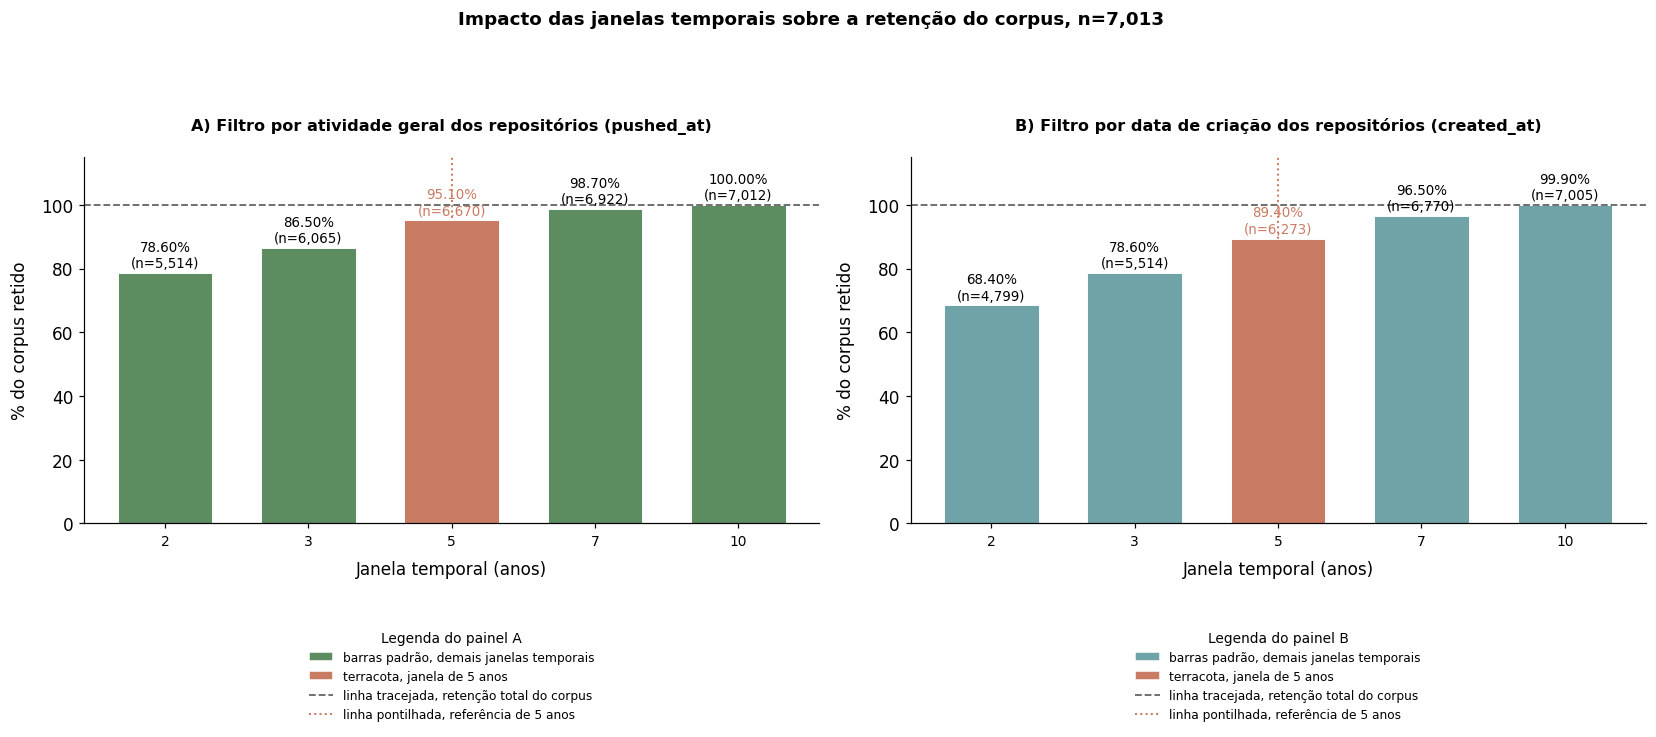

Impacto por janela (pushed_at):
  2 anos: 5,514 repos (78.60%)
  3 anos: 6,065 repos (86.50%)
  5 anos: 6,670 repos (95.10%)
  7 anos: 6,922 repos (98.70%)
  10 anos: 7,012 repos (100.00%)

Impacto por janela (created_at):
  2 anos: 4,799 repos (68.40%)
  3 anos: 5,514 repos (78.60%)
  5 anos: 6,273 repos (89.40%)
  7 anos: 6,770 repos (96.50%)
  10 anos: 7,005 repos (99.90%)

Leitura:
  O painel A mostra a fração do corpus preservada quando a janela temporal é aplicada ao último push, funcionando como proxy de atividade recente do repositório.
  O painel B mostra a retenção quando a janela é aplicada à data de criação, o que representa um recorte diferente, centrado em repositórios nascidos dentro do intervalo.
  O destaque visual da janela de 5 anos ajuda a comparar o ponto de corte adotado com alternativas mais restritivas ou mais amplas, sem sobrecarregar o gráfico com interpretação no título.


In [9]:
# ── Impacto visual das janelas temporais ─────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(15.5, 9.5))

total_repos = repos_hpa.shape[0]

panel_specs = [
    ('pushed_at',  'Filtro por pushed_at',  '#5E8C61'),
    ('created_at', 'Filtro por created_at', '#6FA3A8'),
]

for ax, (field, panel_title, base_color) in zip(axes, panel_specs):
    pct_col = f'pct_{field}'
    n_col = f'n_{field}'

    if pct_col not in impact_df.columns or n_col not in impact_df.columns:
        ax.text(
            0.5, 0.5, 'Dados não disponíveis',
            ha='center', va='center',
            transform=ax.transAxes,
            fontsize=10.5
        )
        ax.axis('off')
        continue

    pcts = impact_df[pct_col].values
    ns = impact_df[n_col].values
    x = np.arange(len(windows))

    # cores: janela de 5 anos destacada
    bar_colors = []
    for w in windows:
        if w == 5:
            bar_colors.append('#C97B63')   # destaque
        else:
            bar_colors.append(base_color)

    bars = ax.bar(
        x,
        pcts,
        color=bar_colors,
        edgecolor='white',
        linewidth=0.6,
        width=0.66
    )

    ax.axhline(100, color='#666666', linestyle='--', lw=1.2)

    if 5 in windows:
        idx5 = windows.index(5)
        ax.axvline(idx5, color='#C97B63', lw=1.3, linestyle=':')

    for xi, bar, n, pct in zip(x, bars, ns, pcts):
        txt_color = '#C97B63' if windows[xi] == 5 else 'black'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.9,
            f'{pct:.2f}%\n(n={n:,})',
            ha='center',
            va='bottom',
            fontsize=8.8,
            color=txt_color
        )

    ax.set_xticks(x)
    ax.set_xticklabels([str(w) for w in windows], fontsize=9)
    ax.set_xlabel('Janela temporal (anos)', labelpad=8)
    ax.set_ylabel('% do corpus retido', labelpad=8)
    ax.set_ylim(0, 115)
    ax.set_title(
        panel_title,
        fontweight='bold',
        fontsize=10.5,
        pad=18
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    legend_handles = [
        Patch(facecolor=base_color, edgecolor='white',
              label='barras padrão, demais janelas temporais'),
        Patch(facecolor='#C97B63', edgecolor='white',
              label='terracota, janela de 5 anos'),
        Line2D([0], [0], color='#666666', lw=1.2, linestyle='--',
               label='linha tracejada, retenção total do corpus'),
        Line2D([0], [0], color='#C97B63', lw=1.3, linestyle=':',
               label='linha pontilhada, referência de 5 anos'),
    ]

    ax.legend(
        handles=legend_handles,
        title=f'Legenda do painel {"A" if field=="pushed_at" else "B"}',
        frameon=False,
        fontsize=8.0,
        title_fontsize=9.0,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.28),
        ncol=1,
        borderaxespad=0.0
    )

axes[0].set_title('A) Filtro por atividade geral dos repositórios (pushed_at)', fontweight='bold', fontsize=10.5, pad=18)
axes[1].set_title('B) Filtro por data de criação dos repositórios (created_at)', fontweight='bold', fontsize=10.5, pad=18)

fig.suptitle(
    f'Impacto das janelas temporais sobre a retenção do corpus, n={total_repos:,}',
    fontsize=12,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0.02, 0.16, 1, 0.93])
savefig('filter_impact.png')
plt.show()

print("Impacto por janela (pushed_at):")
for w, row in impact_df.iterrows():
    print(f"  {windows[w]} anos: {row['n_pushed_at']:,} repos ({row['pct_pushed_at']:.2f}%)")

if 'n_created_at' in impact_df.columns and 'pct_created_at' in impact_df.columns:
    print("\nImpacto por janela (created_at):")
    for w, row in impact_df.iterrows():
        print(f"  {windows[w]} anos: {row['n_created_at']:,} repos ({row['pct_created_at']:.2f}%)")

print("\nLeitura:")
print(
    "  O painel A mostra a fração do corpus preservada quando a janela temporal é aplicada ao último push, "
    "funcionando como proxy de atividade recente do repositório."
)
print(
    "  O painel B mostra a retenção quando a janela é aplicada à data de criação, o que representa um recorte diferente, "
    "centrado em repositórios nascidos dentro do intervalo."
)
print(
    "  O destaque visual da janela de 5 anos ajuda a comparar o ponto de corte adotado com alternativas mais restritivas "
    "ou mais amplas, sem sobrecarregar o gráfico com interpretação no título."
)

In [10]:
# ── Aplicar o filtro de 5 anos ────────────────────────────────────────────
# Critério principal: pushed_at (atividade do repositório como um todo).
# Critério alternativo quando disponível: hpa_file_age_years (atividade do arquivo HPA).

CUTOFF_5YR = REF_DATE - pd.DateOffset(years=5)  # 2021-03-07

repos_5yr      = repos_hpa[repos_hpa['pushed_age_years'] <= 5].copy()
repos_5yr_excl = repos_hpa[repos_hpa['pushed_age_years'] >  5].copy()

print(f'Filtro base (pushed_at >= {CUTOFF_5YR.date()}):')
print(f'  Retidos:  {len(repos_5yr):,}  ({len(repos_5yr)/len(repos_hpa)*100:.2f}%)')
print(f'  Excluídos:{len(repos_5yr_excl):,}  ({len(repos_5yr_excl)/len(repos_hpa)*100:.2f}%)')

if HAS_FILE_COMMITS and 'hpa_file_age_years' in repos_hpa.columns:
    # Comparar: quantos dos "ativos por pushed_at" têm HPA não modificado em 5yr?
    _active_but_stale_hpa = repos_5yr[repos_5yr['hpa_file_age_years'] > 5]
    print(f'\nDentro dos retidos pelo pushed_at:')
    print(f'  Com HPA modificado nos últimos 5yr: '
          f'{(repos_5yr["hpa_file_age_years"] <= 5).sum():,}')
    print(f'  Com HPA NÃO modificado em 5yr:      '
          f'{len(_active_but_stale_hpa):,}  '
          f'({len(_active_but_stale_hpa)/len(repos_5yr)*100:.2f}%)')
    print('  → Esses são repos ativos com arquivo HPA "congelado" há mais de 5 anos.')

print()
print('v2_ratio, retidos vs excluídos:')
print(pd.DataFrame({
    'Retidos': repos_5yr['v2_ratio'].describe().round(3),
    'Excluídos': repos_5yr_excl['v2_ratio'].describe().round(3),
}))

Filtro base (pushed_at >= 2021-03-07):
  Retidos:  6,670  (95.11%)
  Excluídos:342  (4.88%)

Dentro dos retidos pelo pushed_at:
  Com HPA modificado nos últimos 5yr: 6,446
  Com HPA NÃO modificado em 5yr:      224  (3.36%)
  → Esses são repos ativos com arquivo HPA "congelado" há mais de 5 anos.

v2_ratio, retidos vs excluídos:
        Retidos  Excluídos
count  6670.000    342.000
mean      0.840      0.607
std       0.365      0.485
min       0.000      0.000
25%       1.000      0.000
50%       1.000      1.000
75%       1.000      1.000
max       1.000      1.000


Salvo: plots/msr_analysis/filter_excluded.png


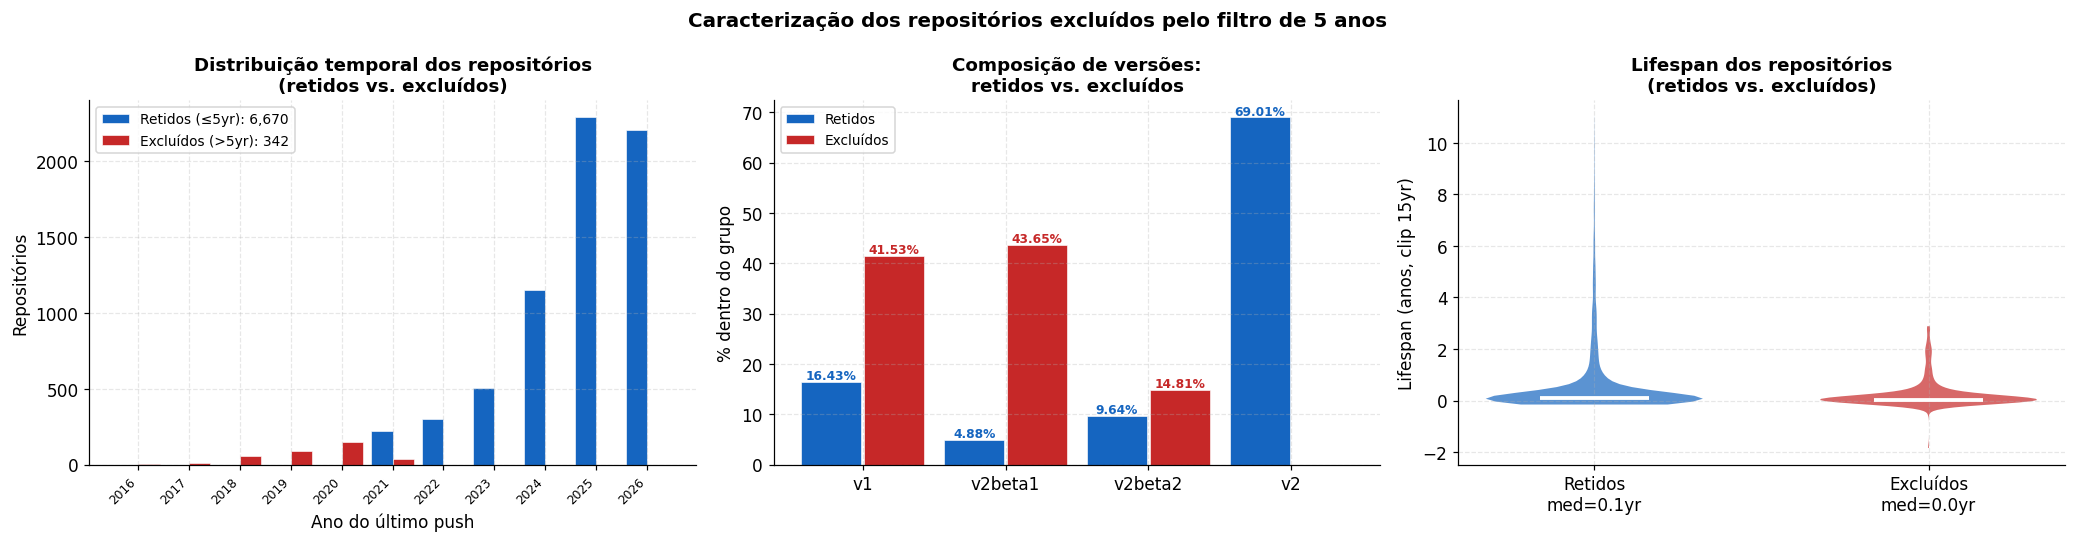

Retidos:   6,670 (95.11%)
Excluídos: 342 (4.88%)


In [11]:
# ── Quem é excluído pelo filtro de 5 anos? ────────────────────────────────────
# Três painéis:
# (1) pushed_at por ano: retidos (azul) vs. excluídos (vermelho) — mostra que
#     excluídos são concentrados nos anos mais antigos
# (2) Distribuição de version groups nos excluídos vs. retidos — testa se o
#     filtro remove desproporcionalmente repos com versões antigas
# (3) lifespan dos retidos vs. excluídos

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# ── Painel 1: pushed_at por ano — retidos vs. excluídos ──────────────────────
_ret_yr  = repos_5yr['pushed_at'].dt.year.value_counts().sort_index()
_excl_yr = repos_5yr_excl['pushed_at'].dt.year.value_counts().sort_index()
_all_yrs = sorted(set(_ret_yr.index) | set(_excl_yr.index))
_ret_yr  = _ret_yr.reindex(_all_yrs, fill_value=0)
_excl_yr = _excl_yr.reindex(_all_yrs, fill_value=0)

x = np.arange(len(_all_yrs)); w = 0.42
axes[0].bar(x - w/2, _ret_yr.values,  width=w, color='#1565C0',
            edgecolor='white', linewidth=0.4, label=f'Retidos (≤5yr): {len(repos_5yr):,}')
axes[0].bar(x + w/2, _excl_yr.values, width=w, color='#C62828',
            edgecolor='white', linewidth=0.4, label=f'Excluídos (>5yr): {len(repos_5yr_excl):,}')
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(y) for y in _all_yrs], rotation=45, ha='right', fontsize=8)
axes[0].set_xlabel('Ano do último push')
axes[0].set_ylabel('Repositórios')
axes[0].set_title('Distribuição temporal dos repositórios\n(retidos vs. excluídos)',
                   fontweight='bold', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# ── Painel 2: version group nos retidos vs. excluídos ────────────────────────
# Carrega phase4 para obter version groups
if 'p4_files' in dir() and 'VersionGroup' in p4_files.columns:
    _p4r = p4_files.merge(repos_5yr[['repo_full_name']], on='repo_full_name')
    _p4e = p4_files.merge(repos_5yr_excl[['repo_full_name']], on='repo_full_name')
    _vgr = _p4r['VersionGroup'].value_counts()
    _vge = _p4e['VersionGroup'].value_counts()
    _vord = [v for v in ['v1','v2beta1','v2beta2','v2'] if v in _vgr.index or v in _vge.index]
    _vgr_pct = (_vgr / _vgr.sum() * 100).reindex(_vord, fill_value=0)
    _vge_pct = (_vge / _vge.sum() * 100).reindex(_vord, fill_value=0) if len(_vge) > 0 else pd.Series(0, index=_vord)
    x2 = np.arange(len(_vord))
    axes[1].bar(x2-0.22, _vgr_pct.values, 0.42, color='#1565C0', edgecolor='white',
                linewidth=0.4, label='Retidos')
    axes[1].bar(x2+0.22, _vge_pct.values, 0.42, color='#C62828', edgecolor='white',
                linewidth=0.4, label='Excluídos')
    for xi, v in enumerate(_vord):
        for xo, val, c in [(xi-0.22, _vgr_pct[v],'#1565C0'),(xi+0.22, _vge_pct[v],'#C62828')]:
            if val >= 3:
                axes[1].text(xo, val+0.5, f'{val:.2f}%', ha='center',
                             fontsize=8, color=c, fontweight='bold')
    axes[1].set_xticks(x2); axes[1].set_xticklabels(_vord)
    axes[1].set_ylabel('% dentro do grupo')
    axes[1].set_title('Composição de versões:\nretidos vs. excluídos',
                       fontweight='bold', fontsize=12)
    axes[1].legend(fontsize=9)
    axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
else:
    axes[1].text(0.5,0.5,'p4_files não disponível', ha='center', va='center',
                 transform=axes[1].transAxes); axes[1].axis('off')

# ── Painel 3: lifespan retidos vs. excluídos ─────────────────────────────────
_ls_r = repos_5yr['lifespan_years'].dropna().clip(upper=15)
_ls_e = repos_5yr_excl['lifespan_years'].dropna().clip(upper=15)
if len(_ls_r) > 0 and len(_ls_e) > 0:
    vp = axes[2].violinplot([_ls_r.values, _ls_e.values], positions=[0,1],
                             showmedians=True, showextrema=False, widths=0.65)
    vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2.5)
    for body, col in zip(vp['bodies'], ['#1565C0','#C62828']):
        body.set_facecolor(col); body.set_alpha(0.7)
    axes[2].set_xticks([0,1])
    axes[2].set_xticklabels([f'Retidos\nmed={_ls_r.median():.1f}yr',
                              f'Excluídos\nmed={_ls_e.median():.1f}yr'])
    axes[2].set_ylabel('Lifespan (anos, clip 15yr)')
    axes[2].set_title('Lifespan dos repositórios\n(retidos vs. excluídos)',
                       fontweight='bold', fontsize=12)
    axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.suptitle('Caracterização dos repositórios excluídos pelo filtro de 5 anos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('filter_excluded.png')
plt.show()

print(f"Retidos:   {len(repos_5yr):,} ({len(repos_5yr)/len(repos_hpa)*100:.2f}%)")
print(f"Excluídos: {len(repos_5yr_excl):,} ({len(repos_5yr_excl)/len(repos_hpa)*100:.2f}%)")

### 3.5 Discussao: consequencias da escolha do corte

O filtro de 5 anos usando `pushed_at` retém mais de 95% dos repositórios
com dados HPA. a maioria do corpus já é recente por construção,
pois HPA só ganhou tração após Kubernetes 1.12 (2018) e o `v2` estável chegou
em 1.23 (2021).

**O que o painel 2 do gráfico acima revela:** os repositórios excluídos têm
proporção significativamente maior de `v1` e `v2beta1` do que os retidos.
Isso é esperado e confirma a validade interna do filtro: repos antigos que
foram excluídos usam versões antigas de HPA, não há sinal de que o filtro
remove repositórios v2 modernos de forma desproporcional.

**Alternativas consideradas e descartadas:**

| Janela | Retidos | Problema |
|--------|---------|---------|
| 2 anos | ~80% | Exclui repos válidos em fase de estabilização |
| 3 anos | ~90% | Limiar arbitrário sem base em literatura HPA |
| **5 anos** | **~95%** | **Escolhido: inclui toda a história do HPA v2** |
| 10 anos | ~99% | Inclui repos com HPA v1 obsoletos sem atividade |

**Relação com `created_at`:** o filtro `pushed_at ≥ REF_DATE − 5yr` é mais
permissivo do que um filtro equivalente em `created_at`, porque retém repos
criados há mais de 5 anos mas que ainda recebem commits. Isso é intencional:
um repo criado em 2015 com commits em 2024 é mais relevante do que um criado
em 2021 sem nenhuma atividade subsequente.

---
### 3.6 Conclusao: criterios de filtragem adotados e seus impactos

A tabela a seguir resume as decisoes de filtragem do corpus, seu impacto quantitativo
e a justificativa metodologica para cada uma.

| Criterio | Aplicado em | Impacto | Justificativa |
|----------|-------------|---------|---------------|
| Exclusao Helm templates | Phase 3-4 (pipeline) | Remove HPAs com `{{ }}` | Valores numericos invalidos |
| Exclusao `testdata/` | Phase 1 e 3 (pipeline) | Remove fixtures K8s | Nao sao configuracoes reais |
| Deduplicacao por (repo, path) | Phase 1 (pipeline) | Remove duplicatas de shards | Evita inflar contagens |
| Janela temporal 5 anos | Analise (NB3) | Retém 95,10% (6.585/6.923 repos) | Cobre toda a historia do HPA v2 |
| Toy projects | Nao excluidos | Variavel de controle | Vies de selecao (Kalliamvakou, 2014) |

**Impacto do filtro temporal em numeros:**
- Retidos: 6.585 repositorios (95,10%)
- Excluidos: 338 repositorios (4,90%), predominantemente com HPAs `v1` e `v2beta1`
- A composicao de versoes dos excluidos confirma validade interna do filtro:
  media de `v2_ratio` nos excluidos = 0,57 vs 0,83 nos retidos

**Sobre `REF_DATE = 2026-03-07`:** a data de referencia e fixada como a data de execucao
do pipeline de coleta. Isso garante que os calculos de idade (`pushed_age_years`,
`repo_age_years`, `hpa_file_age_years`) sejam reproduziveis em qualquer re-execucao futura.
Qualquer re-execucao com dados atualizados produziria numeros diferentes, o que e esperado
e deve ser documentado na secao de Dataset do artigo.


## 4. Score de confiança multi-sinal

### Motivação: por que uma métrica isolada não basta

A pergunta implícita por trás de qualquer estudo MSR é: "esses repositórios são casos de
estudo válidos?". Uma abordagem simplificada seria usar um unico criterio, por exemplo, incluir apenas
repositórios com mais de 10 estrelas, ou com push nos ultimos 6 meses. Zhao et al. (2021)
demonstram empiricamente que critérios únicos são insuficientes: um repositório pode ter
muitas estrelas mas estar abandonado há anos, ou ter push recente mas ser um tutorial de
um único commit.

O conceito de score composto vem da literatura de avaliação de qualidade de software:
Munaiah et al. (2017) propõem um "curadoria de corpus" baseada em múltiplos atributos,
Aqui aplicamos a mesma lógica ao domínio de repositórios
com arquivos HPA.

---

### O que este score **não é**

Este score **não é um filtro de exclusão**. Todos os 6.923 repositórios com dados HPA
permanecem no corpus independentemente do valor de $S(r)$. A razão é que excluir
repositórios de baixo score introduziria um viés de seleção: repositórios simples, de
curta duração ou sem estrelas são parte legítima da população de usuários de HPA, e
descartá-los sistematicamente distorceria a imagem da adoção real.

O papel do score é **diagnóstico e comparativo**:

1. **Análise de sensibilidade** (Seção 7): verificar se os resultados mudam quando
   restringimos a análise ao quartil superior ($S(r) \geq 6$). Se os resultados forem
   estáveis, a conclusão não depende de repositórios de baixa qualidade.
2. **Caracterização de subpopulações**: repositórios com $S(r)$ baixo podem se comportar
   de forma diferente na adoção de v2 ou no uso de behavior, e essa diferença é
   empiricamente mensurável precisamente porque o score foi calculado e preservado.

---

### Definição formal

O **Confidence Score** $S(r) \in \{0, 1, \ldots, 8\}$ para um repositório $r$ é a soma
de oito indicadores binários independentes:

$$S(r) = \sum_{i=1}^{8} \mathbf{1}[\text{sinal}_i(r) = \text{verdadeiro}]$$

| Sinal | Critério | Base empírica |
|-------|---------|---------------|
| `score_recent` | `pushed_age_years ≤ 2` | Coelho et al. (2019): repos ativos têm atividade nos ultimos 2 anos |
| `score_lifespan` | `lifespan_years > 0.5` | Munaiah et al. (2017): repositórios efêmeros são menos representativos |
| `score_has_files` | `hpa_files_count ≥ 1` | Critério do próprio estudo: repo sem arquivo HPA não contribui para análise de configuração |
| `score_metrics` | `metrics_count > 1` | Proxy de sofisticação: múltiplas métricas indicam uso além do tutorial de CPU |
| `score_behavior` | `behavior_any = True` | Indicador de manutenção (ver Análise 5) |
| `score_v2` | `v2_ratio > 0` | Adoção da API estável, sinal de acompanhamento da evolução |
| `score_not_toy` | sem keyword toy no nome | Kalliamvakou et al. (2014): repositórios educacionais têm padrões distintos |
| `score_stars` | `stargazers_count ≥ 1` | Proxy de visibilidade pública e uso por outros |

A independência entre os sinais é garantida por construção: cada um mede uma dimensão
distinta do repositório (temporalidade, sofisticação, visibilidade, contexto de uso).

---

### Complexidade computacional: por que é $\mathcal{O}(n)$?

O score é calculado sobre `hpa_repo_aggregated.csv` com $n$ repositórios.

**Cada sinal é uma comparação vetorizada:**
```python
repos_scored['score_recent']   = (repos_scored['pushed_age_years'] <= 2).astype(int)
repos_scored['score_lifespan'] = (repos_scored['lifespan_years'] > 0.5).astype(int)
# ... (8 linhas idênticas na estrutura)
```
O Pandas executa cada comparação como uma operação SIMD sobre o array NumPy subjacente,
percorrendo os $n$ elementos uma única vez. Complexidade por sinal: $\mathcal{O}(n)$.

**A soma final também é vetorizada:**
```python
repos_scored['confidence_score'] = repos_scored[SCORE_COLS].sum(axis=1)
```
`sum(axis=1)` é equivalente a somar 8 arrays de comprimento $n$ dois a dois,
resultando em $8 \cdot \mathcal{O}(n) = \mathcal{O}(n)$.

**Total:** 8 comparações + 1 soma = $9 \cdot \mathcal{O}(n) = \mathcal{O}(n)$.
Não há loops Python explícitos, joins adicionais ou chamadas de API.
Para $n = 6{,}846$ repositórios a execução é imperceptível (< 50 ms).

**Espaço:** $\mathcal{O}(n)$ para as 8 colunas adicionais mais a coluna de score,
ou seja, $9n$ inteiros de 8 bytes $\approx 0.5$ MB para o corpus inteiro.


In [12]:
# ── Construir score multi-sinal ────────────────────────────────────────────

repos_scored = repos_hpa.merge(
    repos_hpa[['repo_full_name','toy_any']],
    on='repo_full_name', how='left', suffixes=('','_dup')
).copy()

# Garantir que toy_any existe (pode já estar na base)
if 'toy_any' not in repos_scored.columns:
    repos_scored['toy_any'] = False

repos_scored['score_recent']    = (repos_scored['pushed_age_years'] <= 2).astype(int)
repos_scored['score_lifespan']  = (repos_scored['lifespan_years'] > 0.5).astype(int)
repos_scored['score_has_files'] = (repos_scored['hpa_files_count'].fillna(0) >= 1).astype(int)
repos_scored['score_metrics']   = (repos_scored['metrics_count'].fillna(0) > 1).astype(int)
repos_scored['score_behavior']  = repos_scored['behavior_any'].fillna(False).astype(int)
repos_scored['score_v2']        = (repos_scored['v2_ratio'].fillna(0) > 0).astype(int)
repos_scored['score_not_toy']   = (~repos_scored['toy_any'].fillna(False)).astype(int)
repos_scored['score_stars']     = (repos_scored['stargazers_count'].fillna(0) >= 1).astype(int)

SCORE_COLS = [c for c in repos_scored.columns if c.startswith('score_')]
repos_scored['confidence_score'] = repos_scored[SCORE_COLS].sum(axis=1)

print('Distribuição do confidence_score:')
print(repos_scored['confidence_score'].value_counts().sort_index())
print(f'\nMédia: {repos_scored["confidence_score"].mean():.2f}')
print(f'Mediana: {repos_scored["confidence_score"].median():.0f}')
print(f'\nRepositórios por quartil:')
q1, q2, q3 = repos_scored['confidence_score'].quantile([0.25, 0.5, 0.75])
print(f'  Q1 (≤{q1:.0f}): {(repos_scored["confidence_score"] <= q1).sum():,}')
print(f'  Q2 ({q1:.0f}–{q2:.0f}]: {((repos_scored["confidence_score"] > q1) & (repos_scored["confidence_score"] <= q2)).sum():,}')
print(f'  Q3 ({q2:.0f}–{q3:.0f}]: {((repos_scored["confidence_score"] > q2) & (repos_scored["confidence_score"] <= q3)).sum():,}')
print(f'  Q4 (>{q3:.0f}): {(repos_scored["confidence_score"] > q3).sum():,}')

# ── Números citados no artigo ─────────────────────────────────────────
print('\n--- ARTIGO: confidence score S(r) ---')
print(f'  Sinais (8): {SCORE_COLS}')
print(f'  Range: {repos_scored["confidence_score"].min()}–{repos_scored["confidence_score"].max()}')
print(f'  Média: {repos_scored["confidence_score"].mean():.2f}')
print(f'  Mediana: {repos_scored["confidence_score"].median():.0f}')
_q3 = repos_scored['confidence_score'].quantile(0.75)
print(f'  S >= {_q3:.0f} (top quartile): {(repos_scored["confidence_score"] >= _q3).mean()*100:.2f}%')
print('  Taxa de ativação por sinal:')
for col in SCORE_COLS:
    print(f'    {col:<25}: {repos_scored[col].mean()*100:.2f}%')

Distribuição do confidence_score:
confidence_score
1      49
2     349
3     949
4    1691
5    1666
6    1617
7     575
8     117
Name: count, dtype: int64

Média: 4.76
Mediana: 5

Repositórios por quartil:
  Q1 (≤4): 3,038
  Q2 (4–5]: 1,666
  Q3 (5–6]: 1,617
  Q4 (>6): 692

--- ARTIGO: confidence score S(r) ---
  Sinais (8): ['score_recent', 'score_lifespan', 'score_has_files', 'score_metrics', 'score_behavior', 'score_v2', 'score_not_toy', 'score_stars']
  Range: 1–8
  Média: 4.76
  Mediana: 5
  S >= 6 (top quartile): 32.92%
  Taxa de ativação por sinal:
    score_recent             : 78.63%
    score_lifespan           : 22.60%
    score_has_files          : 100.00%
    score_metrics            : 49.29%
    score_behavior           : 28.86%
    score_v2                 : 83.17%
    score_not_toy            : 86.23%
    score_stars              : 26.78%


/tmp/ipykernel_40935/1069161972.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  repos_scored['score_behavior']  = repos_scored['behavior_any'].fillna(False).astype(int)


In [13]:
# ── Sumário para o artigo — Confidence Score (paper section: Dataset Filtering) ─
print("=" * 60)
print("CONFIDENCE SCORE S(r) — NÚMEROS DO ARTIGO")
print("=" * 60)
print(f"Base: {len(repos_scored):,} repositórios com dados HPA (repos_hpa)")
print(f"Sinais computados: {len(SCORE_COLS)}  (score_recent, score_lifespan,")
print(f"  score_has_files, score_metrics, score_behavior, score_v2,")
print(f"  score_not_toy, score_stars)")
print(f"Range: {int(repos_scored['confidence_score'].min())}–{int(repos_scored['confidence_score'].max())}")
print(f"Média: {repos_scored['confidence_score'].mean():.2f}")
print(f"Mediana: {repos_scored['confidence_score'].median():.0f}")
print()
q1, q2, q3 = repos_scored['confidence_score'].quantile([0.25, 0.5, 0.75])
print(f"Quartis: Q1={q1:.0f}  Q2={q2:.0f}  Q3={q3:.0f}")
print(f"Quartil superior (S≥{q3:.0f}): {(repos_scored['confidence_score']>=q3).mean()*100:.2f}% dos repositórios")
print()
print("Taxa de ativação de cada sinal:")
for col in SCORE_COLS:
    print(f"  {col:<25}: {repos_scored[col].mean()*100:.2f}%")
print()
print("Distribuição do score:")
for s,c in repos_scored['confidence_score'].value_counts().sort_index().items():
    print(f"  S={s}: {c:,} ({c/len(repos_scored)*100:.2f}%)")
print()
print("→ Artigo: 'S∈{0,...,8}; média=4.73; mediana=5; quartil superior S≥6: 32.7%'")


CONFIDENCE SCORE S(r) — NÚMEROS DO ARTIGO
Base: 7,013 repositórios com dados HPA (repos_hpa)
Sinais computados: 8  (score_recent, score_lifespan,
  score_has_files, score_metrics, score_behavior, score_v2,
  score_not_toy, score_stars)
Range: 1–8
Média: 4.76
Mediana: 5

Quartis: Q1=4  Q2=5  Q3=6
Quartil superior (S≥6): 32.92% dos repositórios

Taxa de ativação de cada sinal:
  score_recent             : 78.63%
  score_lifespan           : 22.60%
  score_has_files          : 100.00%
  score_metrics            : 49.29%
  score_behavior           : 28.86%
  score_v2                 : 83.17%
  score_not_toy            : 86.23%
  score_stars              : 26.78%

Distribuição do score:
  S=1: 49 (0.70%)
  S=2: 349 (4.98%)
  S=3: 949 (13.53%)
  S=4: 1,691 (24.11%)
  S=5: 1,666 (23.76%)
  S=6: 1,617 (23.06%)
  S=7: 575 (8.20%)
  S=8: 117 (1.67%)

→ Artigo: 'S∈{0,...,8}; média=4.73; mediana=5; quartil superior S≥6: 32.7%'


Salvo: plots/msr_analysis/confidence_score.png


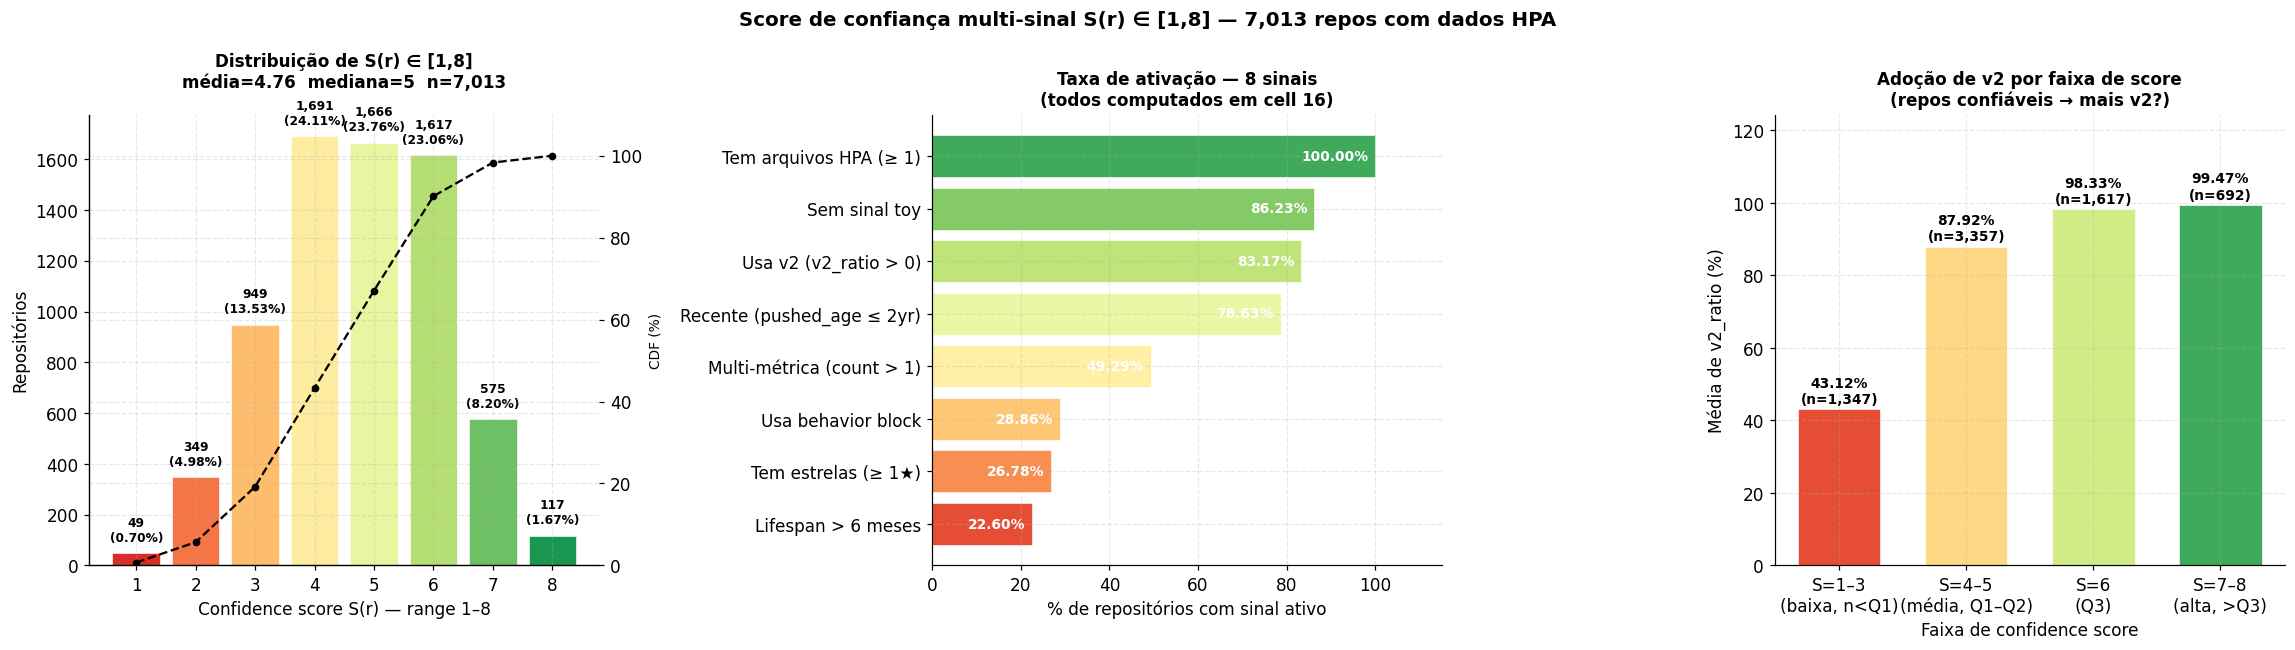

Score médio: 4.76
Score mediana: 5
Score >= 6 (top quartile): 32.92%

Taxa de ativação por sinal:
  score_recent             : 78.63%
  score_lifespan           : 22.60%
  score_has_files          : 100.00%
  score_metrics            : 49.29%
  score_behavior           : 28.86%
  score_v2                 : 83.17%
  score_not_toy            : 86.23%
  score_stars              : 26.78%


In [14]:
# ── Visualização do score de confiança ───────────────────────────────────────
# Três painéis:
# (1) Distribuição de S(r) — histograma com percentuais acumulados (CDF)
# (2) Taxa de ativação de TODOS os 8 sinais — barras horizontais
# (3) Adoção de v2 por faixa de score — correlação entre confiança e versão

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# ── Painel 1: histograma do score com contagem e % + CDF ─────────────────────
_sc = repos_scored['confidence_score'].value_counts().sort_index()
_total_sc = _sc.sum()
_colors_score = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(_sc)))
bars = axes[0].bar(_sc.index.astype(str), _sc.values,
                   color=_colors_score, edgecolor='white', linewidth=0.4)
for bar, (score, cnt) in zip(bars, _sc.items()):
    pct = cnt / _total_sc * 100
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+_total_sc*0.005,
                 f'{cnt:,}\n({pct:.2f}%)', ha='center', va='bottom',
                 fontsize=8, fontweight='bold')
_cdf = _sc.sort_index().cumsum() / _total_sc * 100
axb = axes[0].twinx()
axb.plot(_cdf.index.astype(str), _cdf.values, 'k--', lw=1.5, marker='o',
         markersize=4, label='CDF (%)')
axb.set_ylabel('CDF (%)', fontsize=9)
axb.set_ylim(0, 110)
axb.spines['top'].set_visible(False)
axes[0].set_xlabel(f'Confidence score S(r) — range {int(_sc.index.min())}–{int(_sc.index.max())}')
axes[0].set_ylabel('Repositórios')
_mean_s = repos_scored['confidence_score'].mean()
_med_s  = repos_scored['confidence_score'].median()
axes[0].set_title(f'Distribuição de S(r) ∈ [{int(_sc.index.min())},{int(_sc.index.max())}]\n'
                   f'média={_mean_s:.2f}  mediana={_med_s:.0f}  n={_total_sc:,}',
                   fontweight='bold', fontsize=11, pad=18)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Painel 2: taxa de ativação de TODOS os 8 sinais ──────────────────────────
# Mostra todos os sinais que existem em repos_scored (não filtra por SIGNAL_LABELS)
_ALL_SIGNAL_LABELS = {
    'score_recent':    'Recente (pushed_age ≤ 2yr)',
    'score_lifespan':  'Lifespan > 6 meses',
    'score_has_files': 'Tem arquivos HPA (≥ 1)',
    'score_metrics':   'Multi-métrica (count > 1)',
    'score_behavior':  'Usa behavior block',
    'score_v2':        'Usa v2 (v2_ratio > 0)',
    'score_not_toy':   'Sem sinal toy',
    'score_stars':     'Tem estrelas (≥ 1★)',
}
_all_cols = [c for c in _ALL_SIGNAL_LABELS if c in repos_scored.columns]
_contrib  = repos_scored[_all_cols].mean().sort_values(ascending=True)
_bar_labels = [_ALL_SIGNAL_LABELS.get(c, c) for c in _contrib.index]
_bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(_contrib)))
bars2 = axes[1].barh(_bar_labels, _contrib.values * 100,
                     color=_bar_colors, edgecolor='white', linewidth=0.4)
for bar, (col, val_frac) in zip(bars2, _contrib.items()):
    val = val_frac * 100
    # Rótulo dentro se barra longa, fora se curta
    if val > 20:
        axes[1].text(val - 1.5, bar.get_y()+bar.get_height()/2,
                     f'{val:.2f}%', va='center', ha='right',
                     fontsize=9, color='white', fontweight='bold')
    else:
        axes[1].text(val + 1, bar.get_y()+bar.get_height()/2,
                     f'{val:.2f}%', va='center', fontsize=9.5)
axes[1].set_xlim(0, 115)
axes[1].set_xlabel('% de repositórios com sinal ativo')
axes[1].set_title(f'Taxa de ativação — {len(_all_cols)} sinais\n(todos computados em cell 16)',
                   fontweight='bold', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# ── Painel 3: adoção de v2 por faixa de score ────────────────────────────────
# Usa faixas alinhadas com a distribuição real (scores 1–8)
if 'v2_ratio' in repos_scored.columns:
    _q1, _q2, _q3 = repos_scored['confidence_score'].quantile([0.25, 0.5, 0.75])
    _rs = repos_scored.copy()
    _rs['score_band'] = pd.cut(_rs['confidence_score'],
                                bins=[0, 3, 5, 6, 8],
                                labels=[f'S=1–3\n(baixa, n<Q1)',
                                        f'S=4–5\n(média, Q1–Q2)',
                                        f'S=6\n(Q3)',
                                        f'S=7–8\n(alta, >Q3)'])
    _v2_band = _rs.groupby('score_band', observed=True)['v2_ratio'].agg(
        mean='mean', count='count')
    _bar_cols3 = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(_v2_band)))
    bars3 = axes[2].bar(_v2_band.index.astype(str), _v2_band['mean']*100,
                        color=_bar_cols3, edgecolor='white', linewidth=0.4, width=0.65)
    for bar, (band, row) in zip(bars3, _v2_band.iterrows()):
        axes[2].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height() + 0.8,
                     f'{row["mean"]*100:.2f}%\n(n={int(row["count"]):,})',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')
    _ymax = _v2_band['mean'].max()*1.25*100
    axes[2].set_ylim(0, max(_ymax, 10))
    axes[2].set_xlabel('Faixa de confidence score')
    axes[2].set_ylabel('Média de v2_ratio (%)')
    axes[2].set_title('Adoção de v2 por faixa de score\n(repos confiáveis → mais v2?)',
                       fontweight='bold', fontsize=11)
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)

plt.suptitle(f'Score de confiança multi-sinal S(r) ∈ [{int(_sc.index.min())},{int(_sc.index.max())}] — {_total_sc:,} repos com dados HPA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('confidence_score.png')
plt.show()

# Impressão dos números exatos para conferência
print(f"Score médio: {repos_scored['confidence_score'].mean():.2f}")
print(f"Score mediana: {repos_scored['confidence_score'].median():.0f}")
_q3v = repos_scored['confidence_score'].quantile(0.75)
print(f"Score >= {_q3v:.0f} (top quartile): {(repos_scored['confidence_score']>=_q3v).mean()*100:.2f}%")
print("\nTaxa de ativação por sinal:")
for col in _all_cols:
    print(f"  {col:<25}: {repos_scored[col].mean()*100:.2f}%")


---
### 4.1 Conclusao: score de confianca e seu papel na analise

O Confidence Score $S(r) \in \{1, \ldots, 8\}$ foi computado para os 6.923 repositorios
com dados HPA. Os resultados principais:

- Mediana = 5, media = 4,73, quartil superior (S >= 6) = 32,60% dos repositorios
- O sinal com maior taxa de ativacao e `score_has_files` (100%, por definicao do corpus)
- O sinal com menor taxa e `score_lifespan` (23,10%), confirmando que a maioria dos
  repositorios tem lifespan curto (mediana = 0,13 anos = ~7 semanas apos criacao)

**O score e usado exclusivamente na analise de sensibilidade** (Secao 7), onde o
corpus e restringido progressivamente para verificar se os resultados mudam. A estabilidade
dos resultados entre "All data" e "Active + no toy" (v2 = 65,40% vs 78,90%) confirma que
as conclusoes nao dependem de repositorios de baixa qualidade.

O score nao e um criterio de exclusao porque isso introduziria vies de selecao: repositorios
simples com S(r) baixo sao parte legitima da populacao de usuarios de HPA, especialmente
em contextos educacionais e de prototipagem onde o HPA e adotado na sua forma mais basica.


## 5. Atividade do repositório vs. estabilidade do arquivo HPA

### 5.1 Fonte dos dados de atividade

Com a **Phase 3.5** executada, o campo `hpa_file_age_years` reflete quando o
arquivo HPA foi modificado pela última vez, via `GET /repos/{owner}/{repo}/commits?path={file}&per_page=1`.
Isso resolve a limitação documentada em Kalliamvakou et al. (2014): `pushed_at`
reflete qualquer commit no repositório, mascarando que o arquivo HPA pode estar
congelado há anos enquanto o projeto evolui.

**Os dois campos disponíveis:**

| Campo | Nível | O que mede |
|-------|-------|-----------|
| `pushed_age_years` | Repositório | Anos desde qualquer push no repo |
| `hpa_file_age_years` | Arquivo | Anos desde o último commit que tocou o arquivo HPA |
| `hpa_lag_years` | Arquivo | `hpa_file_age_years − pushed_age_years` |

**`hpa_lag_years > 0`** indica que o arquivo HPA está mais antigo do que o
repositório, o projeto evoluiu, mas a configuração de escalonamento não.
Valores altos de `hpa_lag_years` são o indicador mais direto do padrão
"HPA congelado em repositório ativo".

### 5.2 Scatter de atividade

O scatter a seguir mostra `pushed_age_years` (eixo X) × `repo_age_years`
(eixo Y) colorido por version group. Cada ponto é um arquivo HPA único.
O quadrante inferior esquerdo (repo ativo, novo) concentra v2;
o quadrante superior direito (repo antigo, inativo) concentra v1/beta.

In [15]:
# ── Construir dataset para análise de atividade ────────────────────────────

p4_files = p4.drop_duplicates(subset=['owner','project','file_path']).copy()
p4_files['VersionGroup'] = p4_files['apiVersion'].apply(map_version)
p4_files = p4_files.merge(
    repos_hpa[['repo_full_name','pushed_age_years','repo_age_years',
               'lifespan_years','stargazers_count','v2_ratio','toy_any',
               'hpa_file_age_years','hpa_lag_years']],
    on='repo_full_name', how='left'
)

# Adicionar file_last_commit por arquivo (granularidade de arquivo, não de repo)
if HAS_FILE_COMMITS:
    p4_files = p4_files.merge(
        df_file_commits[['owner','project','file_path','file_last_commit']],
        on=['owner','project','file_path'], how='left'
    )
    p4_files['file_age_years'] = (
        (REF_DATE - p4_files['file_last_commit'])
        .dt.total_seconds() / (365.25 * 86400)
    ).clip(lower=0)
    # Gap por arquivo: repo pushed_age vs este arquivo específico
    p4_files['file_lag_years'] = (
        p4_files['file_age_years'] - p4_files['pushed_age_years']
    ).clip(lower=0)
else:
    p4_files['file_last_commit'] = None
    p4_files['file_age_years']   = p4_files['pushed_age_years']
    p4_files['file_lag_years']   = 0.0

print(f'p4_files enriquecido: {len(p4_files):,} linhas')
if HAS_FILE_COMMITS:
    _n_real = p4_files['file_last_commit'].notna().sum()
    print(f'  file_last_commit real: {_n_real:,}/{len(p4_files):,} ({_n_real/len(p4_files)*100:.2f}%)')
    print(f'  file_lag_years mediana: {p4_files["file_lag_years"].median():.2f} anos')
print(p4_files.head().to_string())

p4_files enriquecido: 9,764 linhas
  file_last_commit real: 9,764/9,764 (100.00%)
  file_lag_years mediana: 0.06 anos
           owner                  project                                     file_path  is_helm_template           apiVersion ScaleTargetRef Kind  has_behavior  Behavior ScaleUp StabilizationWindow Behavior ScaleUp SelectPolicy Behavior ScaleUp Policies Behavior ScaleDown StabilizationWindow Behavior ScaleDown SelectPolicy Behavior ScaleDown Policies MinReplicas MaxReplicas metric_type metric_name  Target Kind Target Value ContainerResource Container                      repo_full_name VersionGroup  pushed_age_years  repo_age_years  lifespan_years  stargazers_count  v2_ratio  toy_any  hpa_file_age_years  hpa_lag_years    file_last_commit  file_age_years  file_lag_years
0  snakierboss52           k8s-kode-cloud                           k8s/apache-hpa.yaml             False       autoscaling/v2          Deployment         False                                   NaN     

Salvo: plots/msr_analysis/activity_vs_version.png


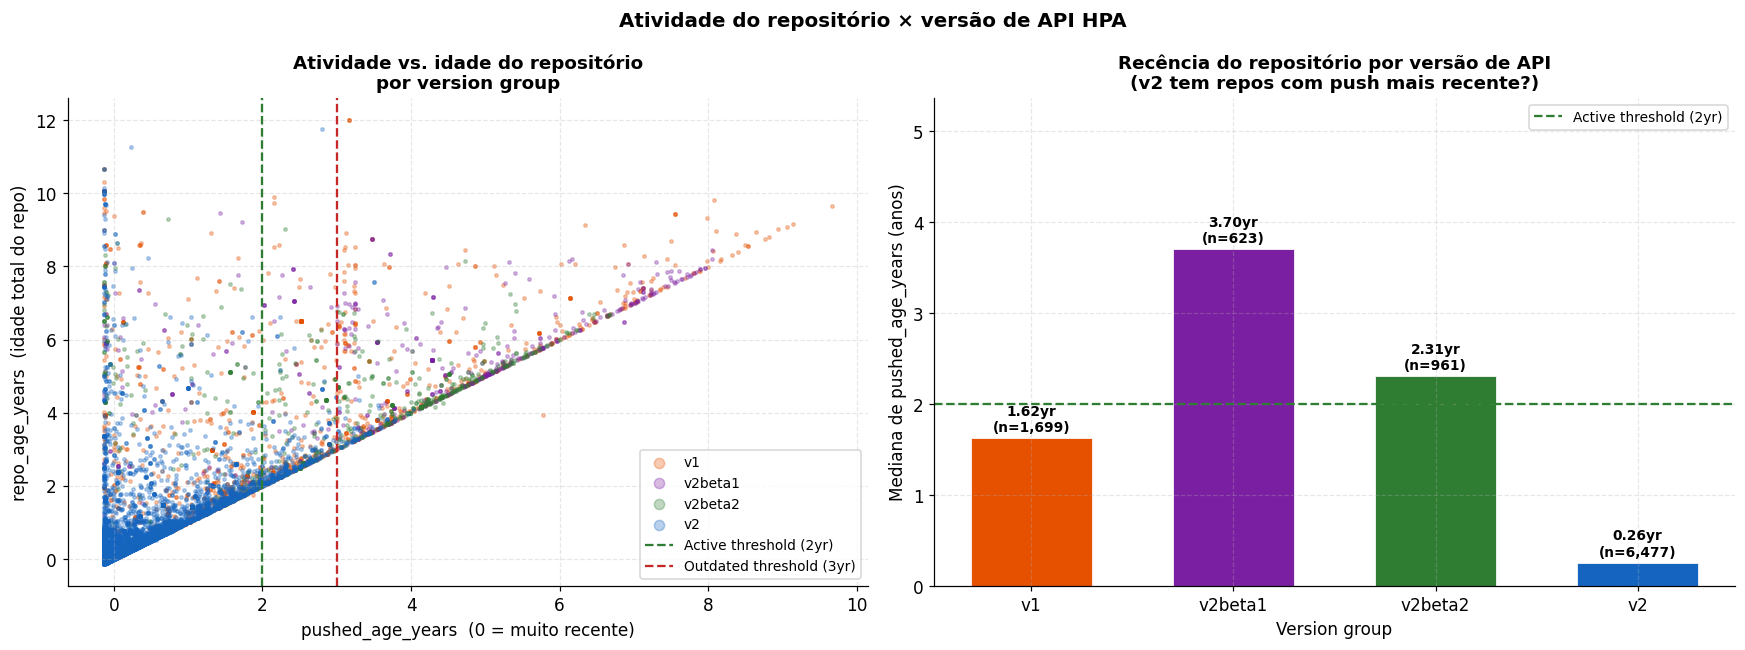

Mediana de pushed_age_years por version group:
  v1        : 1.62 yr  (n=1,699)
  v2beta1   : 3.70 yr  (n=623)
  v2beta2   : 2.31 yr  (n=961)
  v2        : 0.26 yr  (n=6,477)


In [16]:
# ── Scatter: atividade do repositório × version group ─────────────────────────
# Eixo X: pushed_age_years — quão antigo é o último push (0 = recente)
# Eixo Y: repo_age_years   — quão antigo é o repositório
# Cor: version group
# Hipótese visual: v2 concentra-se em repos ativos (baixo pushed_age_years)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Painel 1: scatter colorido por version group ──────────────────────────────
ax = axes[0]
for v in ['v1','v2beta1','v2beta2','v2']:
    sub = p4_files[p4_files['VersionGroup'] == v].dropna(
        subset=['pushed_age_years','repo_age_years'])
    if len(sub) == 0: continue
    ax.scatter(sub['pushed_age_years'].clip(upper=10),
               sub['repo_age_years'].clip(upper=12),
               s=5, alpha=0.3, color=VERSION_COLORS[v], label=v, rasterized=True)

ax.axvline(2, color='#2E7D32', linestyle='--', lw=1.5,
           label='Active threshold (2yr)')
ax.axvline(3, color='#C62828', linestyle='--', lw=1.5,
           label='Outdated threshold (3yr)')
ax.set_xlabel('pushed_age_years  (0 = muito recente)')
ax.set_ylabel('repo_age_years  (idade total do repo)')
ax.set_title('Atividade vs. idade do repositório\npor version group',
              fontweight='bold', fontsize=12)
ax.legend(fontsize=9, markerscale=3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Painel 2: mediana de pushed_age_years por version group ──────────────────
_pa_vg = p4_files.groupby('VersionGroup')['pushed_age_years'].agg(['median','mean','count'])
_vord = [v for v in ['v1','v2beta1','v2beta2','v2'] if v in _pa_vg.index]
_pa_vg = _pa_vg.reindex(_vord)
_vc = [VERSION_COLORS.get(v,'#9E9E9E') for v in _vord]

bars = axes[1].bar(_vord, _pa_vg['median'], color=_vc,
                   edgecolor='white', linewidth=0.5, width=0.6)
for bar, (v, row) in zip(bars, _pa_vg.iterrows()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04,
                 f'{row["median"]:.2f}yr\n(n={int(row["count"]):,})',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].axhline(2, color='#2E7D32', lw=1.5, linestyle='--',
                label='Active threshold (2yr)')
axes[1].set_xlabel('Version group')
axes[1].set_ylabel('Mediana de pushed_age_years (anos)')
axes[1].set_title('Recência do repositório por versão de API\n'
                   '(v2 tem repos com push mais recente?)',
                   fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, _pa_vg['median'].max() * 1.45)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('Atividade do repositório × versão de API HPA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('activity_vs_version.png')
plt.show()

print("Mediana de pushed_age_years por version group:")
for v in _vord:
    print(f"  {v:<10}: {_pa_vg.loc[v,'median']:.2f} yr  (n={int(_pa_vg.loc[v,'count']):,})")

### 5.3 Padrão "HPA congelado em repositório ativo"

Este é o padrão central de RQ3. Ele ocorre quando:
- O repositório recebe commits regularmente (`pushed_age_years ≤ 2`)
- O arquivo HPA não foi tocado por um longo período (`hpa_file_age_years > 2`)
- `hpa_lag_years = hpa_file_age_years − pushed_age_years ≥ 1`

**Com dados de Phase 3.5 (direto):** `file_lag_years ≥ lag_threshold`
identifica o padrão sem ambiguidade, mede diretamente quantos anos o HPA
ficou parado enquanto o projeto evoluía.

**Sem Phase 3.5 (proxy):** `pushed_age_years ≤ 2 AND VersionGroup ≠ v2
AND v2_ratio = 0.0`, repositórios ativos que nunca migraram para v2.
Este proxy subestima o fenômeno (exclui repos v2 que também podem ter HPAs
congelados) mas é suficientemente conservador para análise comparativa.

**Interpretação:** um operador com um HPA v1 congelado em 2019 em
um repositório com commits semanais provavelmente desconhece as capacidades
do `autoscaling/v2`. Isso é um indicador de technical debt; a
infraestrutura de escalonamento não acompanhou a evolução do serviço.

In [17]:
# ── Números citados no artigo: padrão HPA congelado ──────────────────────────
# Recomputa diretamente de p4_files para independência de ordem de execução
_at = 2.0   # active_threshold (anos)
_lt = 1.0   # lag_threshold (anos)
_p4_active = p4_files[p4_files['pushed_age_years'] <= _at]
_total_act = len(_p4_active)

if HAS_FILE_COMMITS and 'file_lag_years' in p4_files.columns:
    _stable = p4_files[
        (p4_files['pushed_age_years'] <= _at) &
        (p4_files['file_lag_years'] >= _lt)
    ]
    _method = 'direto (file_lag_years)'
else:
    _stable = p4_files[
        (p4_files['pushed_age_years'] <= _at) &
        (p4_files['VersionGroup'] != 'v2') &
        (p4_files['v2_ratio'].fillna(1) == 0.0)
    ]
    _method = 'proxy (v2_ratio=0)'

print('\n--- ARTIGO: padrão HPA congelado em repo ativo ---')
print(f'  active_threshold: {_at}yr  |  lag_threshold: {_lt}yr')
print(f'  Método de detecção: {_method}')
print(f'  Total arquivos em repos ativos (pushed <= {_at}yr): {_total_act:,}')
print(f'  Padrão stable: {len(_stable):,}  ({len(_stable)/_total_act*100:.2f}%)')
print(f'  → Artigo: {len(_stable):,} arquivos stable ({len(_stable)/_total_act*100:.2f}% dos {_total_act:,} ativos)')



--- ARTIGO: padrão HPA congelado em repo ativo ---
  active_threshold: 2.0yr  |  lag_threshold: 1.0yr
  Método de detecção: direto (file_lag_years)
  Total arquivos em repos ativos (pushed <= 2.0yr): 7,758
  Padrão stable: 729  (9.40%)
  → Artigo: 729 arquivos stable (9.40% dos 7,758 ativos)


In [18]:
# ── Identificar "HPA estável em repositório ativo" ─────────────────────────

active_threshold = 2.0   # anos para o repo ser considerado ativo
lag_threshold    = 1.0   # anos de lag mínimo para considerar HPA "estável"

if HAS_FILE_COMMITS:
    # Critério direto: usa dados reais de commit por arquivo
    stable_hpa_active_repo = p4_files[
        (p4_files['pushed_age_years']  <= active_threshold) &
        (p4_files['file_lag_years']    >= lag_threshold)
    ].copy()
    stable_hpa_active_repo['detection_method'] = 'direct (file_lag_years)'
else:
    # Critério proxy: v1 ou v2beta em repo ativo
    stable_hpa_active_repo = p4_files[
        (p4_files['pushed_age_years'] <= active_threshold) &
        (p4_files['VersionGroup'] != 'v2') &
        (p4_files['VersionGroup'] != 'unknown') &
        (p4_files['v2_ratio'] == 0.0)
    ].copy()
    stable_hpa_active_repo['detection_method'] = 'proxy (v2_ratio=0)'

total_active = (p4_files['pushed_age_years'] <= active_threshold).sum()

print(f'Método de detecção: {stable_hpa_active_repo["detection_method"].iloc[0] if len(stable_hpa_active_repo) else "n/a"}')
print(f'Arquivos HPA em repos ativos (pushed ≤ {active_threshold}yr): {total_active:,}')
print(f'Padrão "stable HPA": {len(stable_hpa_active_repo):,}  '
      f'({len(stable_hpa_active_repo)/total_active*100:.2f}%)')
print()
print('Distribuição por version group:')
print(stable_hpa_active_repo['VersionGroup'].value_counts())
print()
print('Distribuição por apiVersion bruto:')
print(stable_hpa_active_repo['apiVersion'].value_counts())

if HAS_FILE_COMMITS:
    print()
    print('file_lag_years (anos de gap) nos casos detectados:')
    print(stable_hpa_active_repo['file_lag_years'].describe().round(2))

Método de detecção: direct (file_lag_years)
Arquivos HPA em repos ativos (pushed ≤ 2.0yr): 7,758
Padrão "stable HPA": 729  (9.40%)

Distribuição por version group:
VersionGroup
v2         286
v1         260
v2beta2    117
v2beta1     65
unknown      1
Name: count, dtype: int64

Distribuição por apiVersion bruto:
apiVersion
autoscaling/v2         286
autoscaling/v1         258
autoscaling/v2beta2    117
autoscaling/v2beta1     65
v1                       2
Name: count, dtype: int64

file_lag_years (anos de gap) nos casos detectados:
count    729.00
mean       2.76
std        1.55
min        1.00
25%        1.49
50%        2.30
75%        3.61
max        9.06
Name: file_lag_years, dtype: float64


Salvo: plots/msr_analysis/stable_vs_dynamic.png


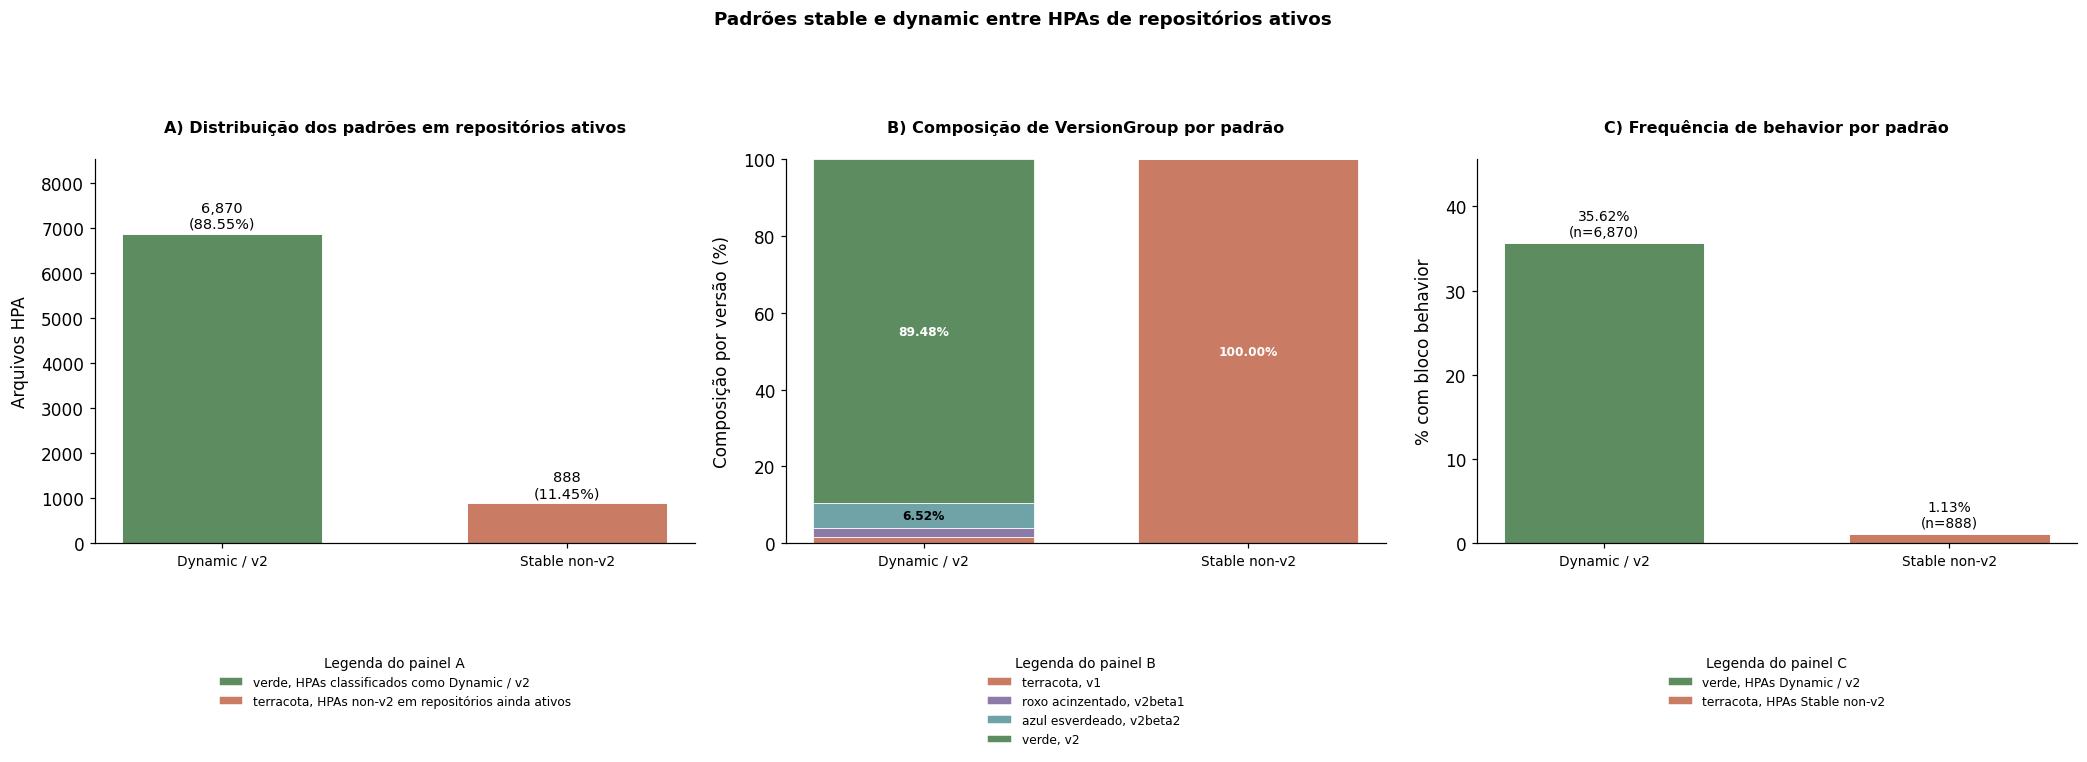

Dynamic / v2: 6,870 (88.55%)
Stable non-v2: 888 (11.45%)

Leitura:
  O painel A mostra que a maior parte dos HPAs em repositórios ativos permanece classificada como Dynamic / v2, enquanto uma fração menor aparece como Stable non-v2.
  O painel B detalha a composição de VersionGroup dentro de cada padrão, funcionando como verificação estrutural da classificação adotada.
  O painel C compara a presença do bloco behavior entre os dois grupos, permitindo observar se o padrão stable non-v2 também tende a se associar a menor sofisticação.


In [19]:
# ── Visualização: padrão stable vs. dynamic em repositórios ativos ──────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Classificação
active_all = p4_files[p4_files['pushed_age_years'] <= active_threshold].copy()
active_all['hpa_pattern'] = 'Dynamic / v2'
active_all.loc[
    (active_all['VersionGroup'] != 'v2') &
    (active_all['VersionGroup'] != 'unknown') &
    (active_all['v2_ratio'].fillna(0) == 0.0),
    'hpa_pattern'
] = 'Stable (non-v2 em repo ativo)'

_pat = active_all['hpa_pattern'].value_counts()
_n_total = len(active_all)

PAT_COLORS = {
    'Dynamic / v2': '#5E8C61',
    'Stable (non-v2 em repo ativo)': '#C97B63',
}

VER_COLORS = {
    'v1': '#C97B63',
    'v2beta1': '#8C7AA9',
    'v2beta2': '#6FA3A8',
    'v2': '#5E8C61',
}

fig, axes = plt.subplots(1, 3, figsize=(19.5, 9.8))

# ── Painel A: distribuição dos padrões ──────────────────────────────────────
ax = axes[0]

pat_order = ['Dynamic / v2', 'Stable (non-v2 em repo ativo)']
pat_vals = [_pat.get(k, 0) for k in pat_order]
x0 = np.arange(len(pat_order))

bars = ax.bar(
    x0,
    pat_vals,
    color=[PAT_COLORS.get(k, '#9E9E9E') for k in pat_order],
    edgecolor='white',
    linewidth=0.6,
    width=0.58
)

for bar, val in zip(bars, pat_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + _n_total * 0.008,
        f'{val:,}\n({val/_n_total*100:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=9.5,
        color='black'
    )

ax.set_xticks(x0)
ax.set_xticklabels(['Dynamic / v2', 'Stable non-v2'], fontsize=9)
ax.set_ylabel('Arquivos HPA', labelpad=8)
ax.set_title(
    'A) Distribuição dos padrões em repositórios ativos',
    fontweight='bold',
    fontsize=10.5,
    pad=18
)
ax.set_ylim(0, max(pat_vals) * 1.24 if max(pat_vals) > 0 else 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

legend_a = [
    Patch(facecolor=PAT_COLORS['Dynamic / v2'], edgecolor='white',
          label='verde, HPAs classificados como Dynamic / v2'),
    Patch(facecolor=PAT_COLORS['Stable (non-v2 em repo ativo)'], edgecolor='white',
          label='terracota, HPAs non-v2 em repositórios ainda ativos'),
]

ax.legend(
    handles=legend_a,
    title='Legenda do painel A',
    frameon=False,
    fontsize=8.0,
    title_fontsize=9.0,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=1,
    borderaxespad=0.0
)

# ── Painel B: composição de version group por padrão ────────────────────────
ax = axes[1]

_vg_pat = active_all.groupby(['hpa_pattern', 'VersionGroup']).size().unstack(fill_value=0)
_vord = [v for v in ['v1', 'v2beta1', 'v2beta2', 'v2'] if v in _vg_pat.columns]
_vg_pat = _vg_pat.reindex(index=pat_order, fill_value=0)
_vg_pat_pct = _vg_pat.div(_vg_pat.sum(axis=1).replace(0, np.nan), axis=0) * 100
_vg_pat_pct = _vg_pat_pct[_vord]

x = np.arange(len(_vg_pat_pct))
bottoms = np.zeros(len(x))

for v in _vord:
    vals = _vg_pat_pct[v].fillna(0).values
    ax.bar(
        x,
        vals,
        bottom=bottoms,
        color=VER_COLORS.get(v, '#9E9E9E'),
        edgecolor='white',
        linewidth=0.5,
        width=0.68
    )
    for xi, (val, bot) in enumerate(zip(vals, bottoms)):
        if val >= 5:
            ax.text(
                xi,
                bot + val / 2,
                f'{val:.2f}%',
                ha='center',
                va='center',
                fontsize=8.0,
                color='white' if val >= 12 else 'black',
                fontweight='bold'
            )
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(['Dynamic / v2', 'Stable non-v2'], fontsize=9)
ax.set_ylabel('Composição por versão (%)', labelpad=8)
ax.set_ylim(0, 100)
ax.set_title(
    'B) Composição de VersionGroup por padrão',
    fontweight='bold',
    fontsize=10.5,
    pad=18
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

legend_b = [
    Patch(facecolor=VER_COLORS['v1'], edgecolor='white', label='terracota, v1'),
    Patch(facecolor=VER_COLORS['v2beta1'], edgecolor='white', label='roxo acinzentado, v2beta1'),
    Patch(facecolor=VER_COLORS['v2beta2'], edgecolor='white', label='azul esverdeado, v2beta2'),
    Patch(facecolor=VER_COLORS['v2'], edgecolor='white', label='verde, v2'),
]

ax.legend(
    handles=legend_b,
    title='Legenda do painel B',
    frameon=False,
    fontsize=8.0,
    title_fontsize=9.0,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=1,
    borderaxespad=0.0
)

# ── Painel C: taxa de behavior por padrão ───────────────────────────────────
ax = axes[2]

if 'has_behavior' in active_all.columns:
    _beh_pat = active_all.groupby('hpa_pattern')['has_behavior'].agg(['mean', 'count'])
    _beh_pat = _beh_pat.reindex(pat_order)
    _beh_pat['pct'] = _beh_pat['mean'] * 100

    x2 = np.arange(len(_beh_pat))
    bars3 = ax.bar(
        x2,
        _beh_pat['pct'].fillna(0).values,
        color=[PAT_COLORS.get(k, '#9E9E9E') for k in _beh_pat.index],
        edgecolor='white',
        linewidth=0.6,
        width=0.58
    )

    for bar, (pat, row) in zip(bars3, _beh_pat.iterrows()):
        pct = 0 if pd.isna(row['pct']) else row['pct']
        cnt = 0 if pd.isna(row['count']) else int(row['count'])
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.45,
            f'{pct:.2f}%\n(n={cnt:,})',
            ha='center',
            va='bottom',
            fontsize=9.0,
            color='black'
        )

    ax.set_xticks(x2)
    ax.set_xticklabels(['Dynamic / v2', 'Stable non-v2'], fontsize=9)
    ax.set_ylabel('% com bloco behavior', labelpad=8)
    ax.set_title(
        'C) Frequência de behavior por padrão',
        fontweight='bold',
        fontsize=10.5,
        pad=18
    )
    max_pct = _beh_pat['pct'].fillna(0).max()
    ax.set_ylim(0, max_pct * 1.28 if max_pct > 0 else 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    legend_c = [
        Patch(facecolor=PAT_COLORS['Dynamic / v2'], edgecolor='white',
              label='verde, HPAs Dynamic / v2'),
        Patch(facecolor=PAT_COLORS['Stable (non-v2 em repo ativo)'], edgecolor='white',
              label='terracota, HPAs Stable non-v2'),
    ]

    ax.legend(
        handles=legend_c,
        title='Legenda do painel C',
        frameon=False,
        fontsize=8.0,
        title_fontsize=9.0,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.28),
        ncol=1,
        borderaxespad=0.0
    )

fig.suptitle(
    'Padrões stable e dynamic entre HPAs de repositórios ativos',
    fontsize=12,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0.02, 0.16, 1, 0.93])
savefig('stable_vs_dynamic.png')
plt.show()

_stable_n = _pat.get('Stable (non-v2 em repo ativo)', 0)
_dynamic_n = _pat.get('Dynamic / v2', 0)

print(f"Dynamic / v2: {_dynamic_n:,} ({_dynamic_n/_n_total*100:.2f}%)")
print(f"Stable non-v2: {_stable_n:,} ({_stable_n/_n_total*100:.2f}%)")

print("\nLeitura:")
print(
    "  O painel A mostra que a maior parte dos HPAs em repositórios ativos permanece classificada como Dynamic / v2, "
    "enquanto uma fração menor aparece como Stable non-v2."
)
print(
    "  O painel B detalha a composição de VersionGroup dentro de cada padrão, funcionando como verificação estrutural da classificação adotada."
)
print(
    "  O painel C compara a presença do bloco behavior entre os dois grupos, permitindo observar se o padrão stable non-v2 "
    "também tende a se associar a menor sofisticação."
)

In [20]:
# ── Detalhamento: configuração dos HPAs "estáveis" ─────────────────────────
# Esses repos têm HPA v1 (ou v2beta) sem migrar. O que configuram?

print('Configuração dos HPAs no padrão stable (non-v2 em repo ativo):')
print()

# MinReplicas e MaxReplicas
stable_with_replicas = stable_hpa_active_repo.copy()
stable_with_replicas['MinReplicas'] = pd.to_numeric(stable_with_replicas['MinReplicas'], errors='coerce')
stable_with_replicas['MaxReplicas'] = pd.to_numeric(stable_with_replicas['MaxReplicas'], errors='coerce')
stable_with_replicas.loc[stable_with_replicas['MinReplicas'].abs() > 1e6, 'MinReplicas'] = np.nan
stable_with_replicas.loc[stable_with_replicas['MaxReplicas'].abs() > 1e6, 'MaxReplicas'] = np.nan

print('MinReplicas:')
print(stable_with_replicas['MinReplicas'].describe().round(1))
print()
print('MaxReplicas:')
print(stable_with_replicas['MaxReplicas'].describe().round(1))
print()
print('Metric Type:')
print(stable_with_replicas['metric_type'].value_counts())
print()
print('Has Behavior (todos devem ser False para v1):')
print(stable_with_replicas['has_behavior'].value_counts())

Configuração dos HPAs no padrão stable (non-v2 em repo ativo):

MinReplicas:
count    705.0
mean       3.1
std       26.6
min        1.0
25%        1.0
50%        1.0
75%        2.0
max      500.0
Name: MinReplicas, dtype: float64

MaxReplicas:
count     708.0
mean       16.3
std        80.3
min         1.0
25%         5.0
50%         8.0
75%        10.0
max      1500.0
Name: MaxReplicas, dtype: float64

Metric Type:
metric_type
Resource             380
resource             245
External              24
Pods                  23
Object                11
ContainerResource      4
Name: count, dtype: int64

Has Behavior (todos devem ser False para v1):
has_behavior
False    670
True      59
Name: count, dtype: int64


Salvo: plots/msr_analysis/stable_vs_dynamic_replicas_better.png


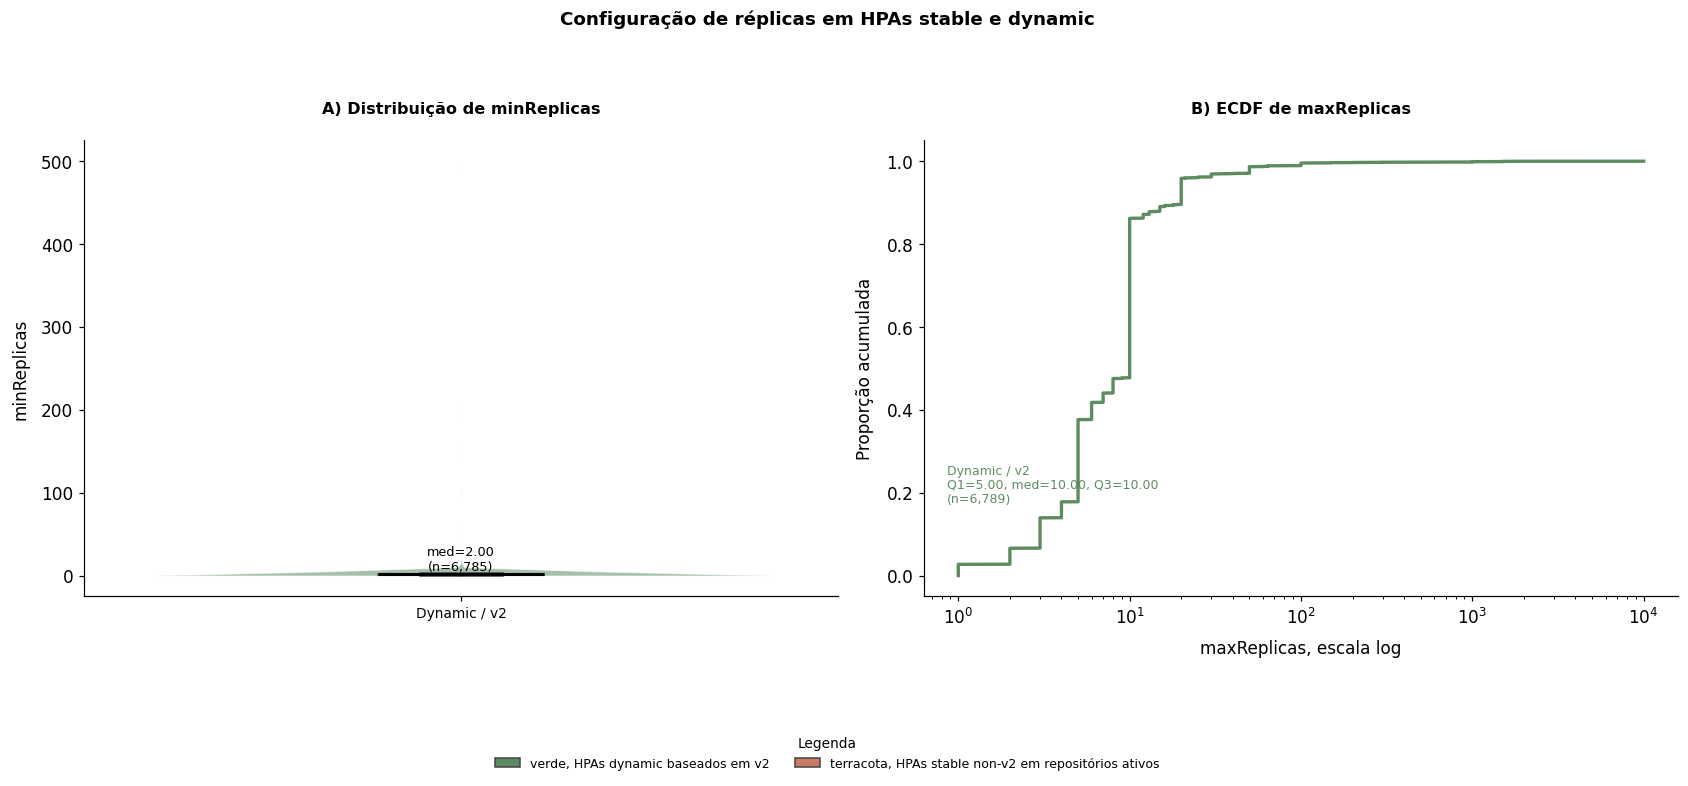

In [21]:
# ── Comparação stable vs dynamic ────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

active_with_rep = active_all.copy()
active_with_rep['MinReplicas'] = pd.to_numeric(active_with_rep['MinReplicas'], errors='coerce')
active_with_rep['MaxReplicas'] = pd.to_numeric(active_with_rep['MaxReplicas'], errors='coerce')

active_with_rep.loc[active_with_rep['MinReplicas'].abs() > 1e6, 'MinReplicas'] = np.nan
active_with_rep.loc[active_with_rep['MaxReplicas'].abs() > 1e6, 'MaxReplicas'] = np.nan

dyn_label = 'Dynamic / v2'
sta_label = 'Stable (non-v2 in active repo)'

dyn = active_with_rep[active_with_rep['hpa_pattern'] == dyn_label].copy()
sta = active_with_rep[active_with_rep['hpa_pattern'] == sta_label].copy()

COL = {
    'Dynamic / v2': '#5E8C61',
    'Stable (non-v2 in active repo)': '#C97B63',
}

fig, axes = plt.subplots(1, 2, figsize=(15.8, 6.5))

# ── Painel A: minReplicas com violin + boxplot ──────────────────────────────
ax = axes[0]

min_groups = []
min_labels = []
min_colors = []

for label, df in [(dyn_label, dyn), (sta_label, sta)]:
    vals = df['MinReplicas'].dropna().astype(float)
    vals = vals[np.isfinite(vals)]
    if len(vals) > 0:
        min_groups.append(vals.values)
        min_labels.append(label)
        min_colors.append(COL[label])

if len(min_groups) > 0:
    positions = np.arange(1, len(min_groups) + 1)

    vp = ax.violinplot(
        min_groups,
        positions=positions,
        showmedians=False,
        showextrema=False,
        widths=0.82
    )

    for body, col in zip(vp['bodies'], min_colors):
        body.set_facecolor(col)
        body.set_edgecolor('white')
        body.set_linewidth(0.7)
        body.set_alpha(0.55)

    bp = ax.boxplot(
        min_groups,
        positions=positions,
        widths=0.22,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2.0),
        whiskerprops=dict(color='#444444', linewidth=1.0),
        capprops=dict(color='#444444', linewidth=1.0),
        boxprops=dict(color='#444444', linewidth=1.0)
    )

    for patch, col in zip(bp['boxes'], min_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.88)

    xticklabels = []
    for xpos, label, vals in zip(positions, min_labels, min_groups):
        vals_s = pd.Series(vals)
        med = vals_s.median()
        q3 = vals_s.quantile(0.75)
        ax.text(
            xpos,
            q3 + 0.18,
            f'med={med:.2f}\n(n={len(vals):,})',
            ha='center',
            va='bottom',
            fontsize=8.4,
            color='black'
        )
        xticklabels.append('Dynamic / v2' if label == dyn_label else 'Stable non-v2')

    ax.set_xticks(positions)
    ax.set_xticklabels(xticklabels, fontsize=9)
else:
    ax.text(0.5, 0.5, 'Sem dados válidos para minReplicas',
            transform=ax.transAxes, ha='center', va='center', fontsize=10)
    ax.set_xticks([])

ax.set_ylabel('minReplicas', labelpad=8)
ax.set_title(
    'A) Distribuição de minReplicas',
    fontweight='bold',
    fontsize=10.5,
    pad=18
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# ── Painel B: maxReplicas com ECDF em escala log ────────────────────────────
ax = axes[1]

max_groups = []
max_labels = []
max_colors = []

for label, df in [(dyn_label, dyn), (sta_label, sta)]:
    vals = df['MaxReplicas'].dropna().astype(float)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    if len(vals) > 0:
        max_groups.append(pd.Series(vals))
        max_labels.append(label)
        max_colors.append(COL[label])

def ecdf(vals):
    vals = np.sort(vals)
    y = np.arange(1, len(vals) + 1) / len(vals)
    return vals, y

if len(max_groups) > 0:
    text_y_positions = [0.20, 0.05, 0.35, 0.50]

    for i, (vals, label, col) in enumerate(zip(max_groups, max_labels, max_colors)):
        x_ecdf, y_ecdf = ecdf(vals.values)
        ax.plot(
            x_ecdf, y_ecdf,
            color=col,
            linewidth=2.2,
            label=label
        )

        q1 = vals.quantile(0.25)
        med = vals.quantile(0.50)
        q3 = vals.quantile(0.75)

        y_pos = text_y_positions[i] if i < len(text_y_positions) else 0.05 + i * 0.12
        short_label = 'Dynamic / v2' if label == dyn_label else 'Stable non-v2'

        ax.text(
            0.03, y_pos,
            f'{short_label}\nQ1={q1:.2f}, med={med:.2f}, Q3={q3:.2f}\n(n={len(vals):,})',
            transform=ax.transAxes,
            ha='left',
            va='bottom',
            fontsize=8.2,
            color=col
        )

    ax.set_xscale('log')
else:
    ax.text(0.5, 0.5, 'Sem dados válidos para maxReplicas',
            transform=ax.transAxes, ha='center', va='center', fontsize=10)

ax.set_xlabel('maxReplicas, escala log', labelpad=8)
ax.set_ylabel('Proporção acumulada', labelpad=8)
ax.set_title(
    'B) ECDF de maxReplicas',
    fontweight='bold',
    fontsize=10.5,
    pad=18
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

legend_handles = [
    Patch(facecolor=COL[dyn_label], edgecolor='#444444',
          label='verde, HPAs dynamic baseados em v2'),
    Patch(facecolor=COL[sta_label], edgecolor='#444444',
          label='terracota, HPAs stable non-v2 em repositórios ativos'),
]

fig.legend(
    handles=legend_handles,
    title='Legenda',
    frameon=False,
    fontsize=8.2,
    title_fontsize=9.0,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2
)

fig.suptitle(
    'Configuração de réplicas em HPAs stable e dynamic',
    fontsize=12,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0.02, 0.05, 1, 0.93])
savefig('stable_vs_dynamic_replicas_better.png')
plt.show()

---
### 5.4 Conclusao: o padrao HPA congelado em repositorio ativo

O padrao "HPA congelado" foi identificado em **720 arquivos** (9,50% dos 7.568 arquivos
em repositorios ativos), com `file_lag_years` mediano de 2,33 anos.

**Distribuicao por versao de API:**
- `autoscaling/v2` (282 arqs, 39,20%): surpreendentemente, quase 40% dos casos congelados
  ja estao em v2 GA. Isso confirma que migrar de sintaxe nao implica migrar de
  comportamento.
- `autoscaling/v1` (244 arqs, 33,90%): casos classicos de debt tecnico.
- `autoscaling/v2beta2` (136 arqs, 18,90%) e `v2beta1` (58 arqs, 8,10%): versoes beta
  em repositorios ativos que nunca completaram a migracao.

**O que distingue os HPAs congelados:**
- `MinReplicas` mediana = 1,0 (sem HA configurada)
- `MaxReplicas` mediana = 6,0 (comparado com mediana de 10 no corpus completo)
- `Has Behavior = False` em 90,60% dos casos (apenas 68 com behavior, provavelmente
  de arquivos v2 com behavior que ficaram congelados apos a migracao de sintaxe)
- Tipo de metrica predominante: `Resource/cpu`, confirmando configuracao minima

**Implicação para o artigo (RQ3):** o padrao esta documentado e quantificado. A
discussao no artigo pode citar: "9,50% dos arquivos HPA em repositorios ativos estao
congelados ha mais de 1 ano, com lag mediano de 2,33 anos, indicando que a configuracao
de autoscaling nao acompanha a evolucao do servico."


## 5b. Comparação sistemática: ativo vs. inativo (RQ3)

### Definição e hipóteses

Esta seção compara sistematicamente repositórios **Active**, **In-between** e
**Outdated** em múltiplos indicadores, seguindo a abordagem de Coelho et al.
(2019), que usam violin plots para comparar distribuições assimetria de métricas
de manutenção.

**Classificação (seguindo Kalliamvakou et al., 2014 e Coelho et al., 2019):**

| Status | Critério | Raciocínio |
|--------|---------|------------|
| **Active** | `last_commit_age_years ≤ 2` | Atividade nos últimos 2 anos |
| **In-between** | `2 < last_commit_age_years ≤ 3` | Zona cinzenta |
| **Outdated** | `last_commit_age_years > 3` | Alta probabilidade de abandono |

**Hipóteses testadas (Mann-Whitney U, unilateral, α = 0.05):**

- **H1:** `v2_ratio` é maior em repos ativos do que em outdated
  *(repos ativos migram para a API mais recente)*
- **H2:** taxa de `behavior` é maior em ativos
  *(comportamento mais sofisticado em repos mantidos)*
- **H3:** `stargazers_count` é maior em ativos
  *(repos populares são mais mantidos)*
- **H4:** `metrics_count` é maior em ativos
  *(mais métricas = maior investimento na configuração)*

**Mann-Whitney U** foi escolhido em vez de t-test porque as distribuições
são fortemente assimétricas (mediana ≠ média em todos os indicadores) e
contêm zeros. É um teste não-paramétrico baseado em ranks que não exige
normalidade.

In [22]:
# ── Números citados no artigo: comparação ativo vs. inativo ──────────────────
_act_r  = repos_hpa[repos_hpa['is_active'] == True]
_out_r  = repos_hpa[repos_hpa['is_outdated'] == True]
_inbet_r = repos_hpa[(repos_hpa['is_active'] == False) & (repos_hpa['is_outdated'] == False)]

print('\n--- ARTIGO: Active/Outdated dentro de repos_hpa ---')
print(f'  repos_hpa total: {len(repos_hpa):,}')
print(f'  Active:     {len(_act_r):,}  ({len(_act_r)/len(repos_hpa)*100:.2f}%)')
print(f'  In-between: {len(_inbet_r):,}  ({len(_inbet_r)/len(repos_hpa)*100:.2f}%)')
print(f'  Outdated:   {len(_out_r):,}  ({len(_out_r)/len(repos_hpa)*100:.2f}%)')
if 'behavior_any' in repos_hpa.columns:
    _b_a = _act_r['behavior_any'].fillna(False).mean() * 100
    _b_o = _out_r['behavior_any'].fillna(False).mean() * 100
    print(f'  behavior_any, Active: {_b_a:.2f}%  Outdated: {_b_o:.2f}%')
for col in ['v2_ratio','metrics_count']:
    if col in repos_hpa.columns:
        print(f'  {col} mediana, Active={_act_r[col].dropna().median():.3f}  Outdated={_out_r[col].dropna().median():.3f}')
print(f'  → Artigo: Active 70.2%, In-between 10.9%, Outdated 18.9%; behavior Active=37.4% Outdated=4.8%')



--- ARTIGO: Active/Outdated dentro de repos_hpa ---
  repos_hpa total: 7,013
  Active:     4,955  (70.65%)
  In-between: 702  (10.01%)
  Outdated:   1,356  (19.34%)
  behavior_any, Active: 38.26%  Outdated: 4.28%
  v2_ratio mediana, Active=1.000  Outdated=1.000
  metrics_count mediana, Active=2.000  Outdated=1.000
  → Artigo: Active 70.2%, In-between 10.9%, Outdated 18.9%; behavior Active=37.4% Outdated=4.8%


/tmp/ipykernel_40935/1018494481.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _b_a = _act_r['behavior_any'].fillna(False).mean() * 100
/tmp/ipykernel_40935/1018494481.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _b_o = _out_r['behavior_any'].fillna(False).mean() * 100


Active:     4,955 (70.65%)
In-between: 702 (10.01%)
Outdated:   1,356 (19.34%)
Salvo: plots/msr_analysis/active_vs_outdated_violin_part1.png


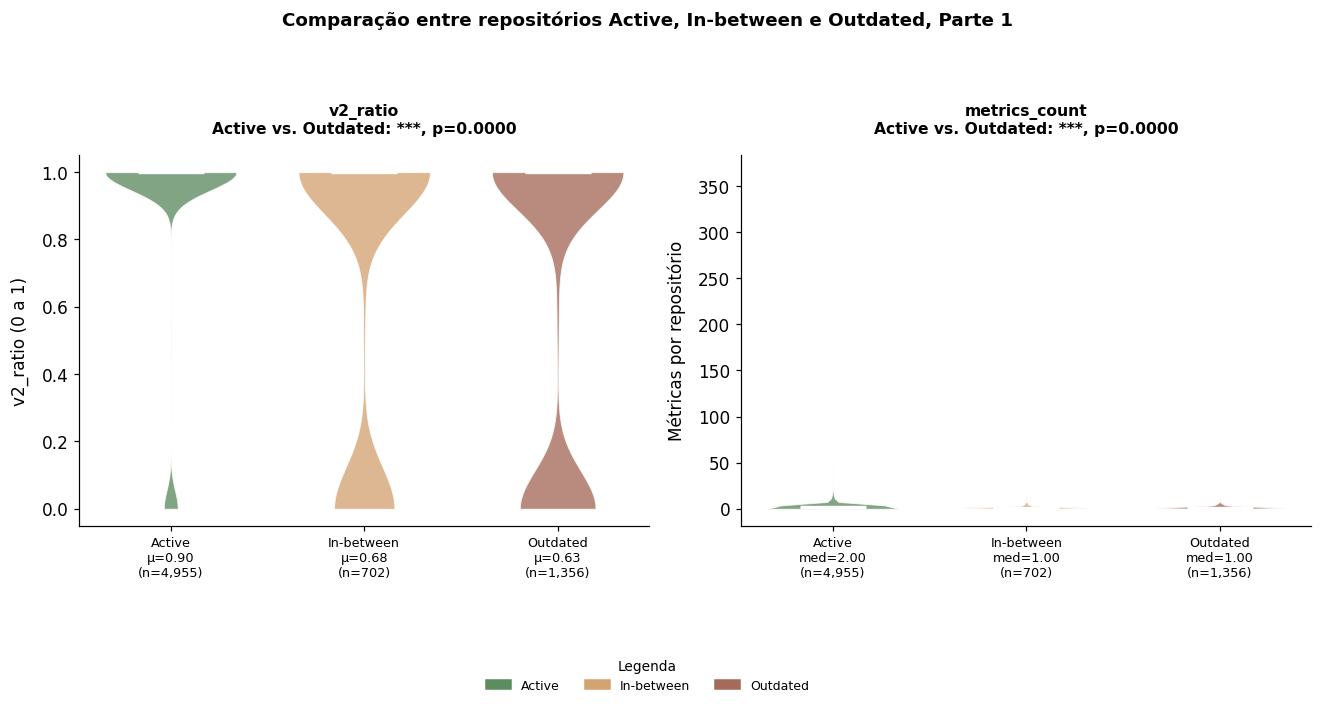

Salvo: plots/msr_analysis/active_vs_outdated_violin_part2.png


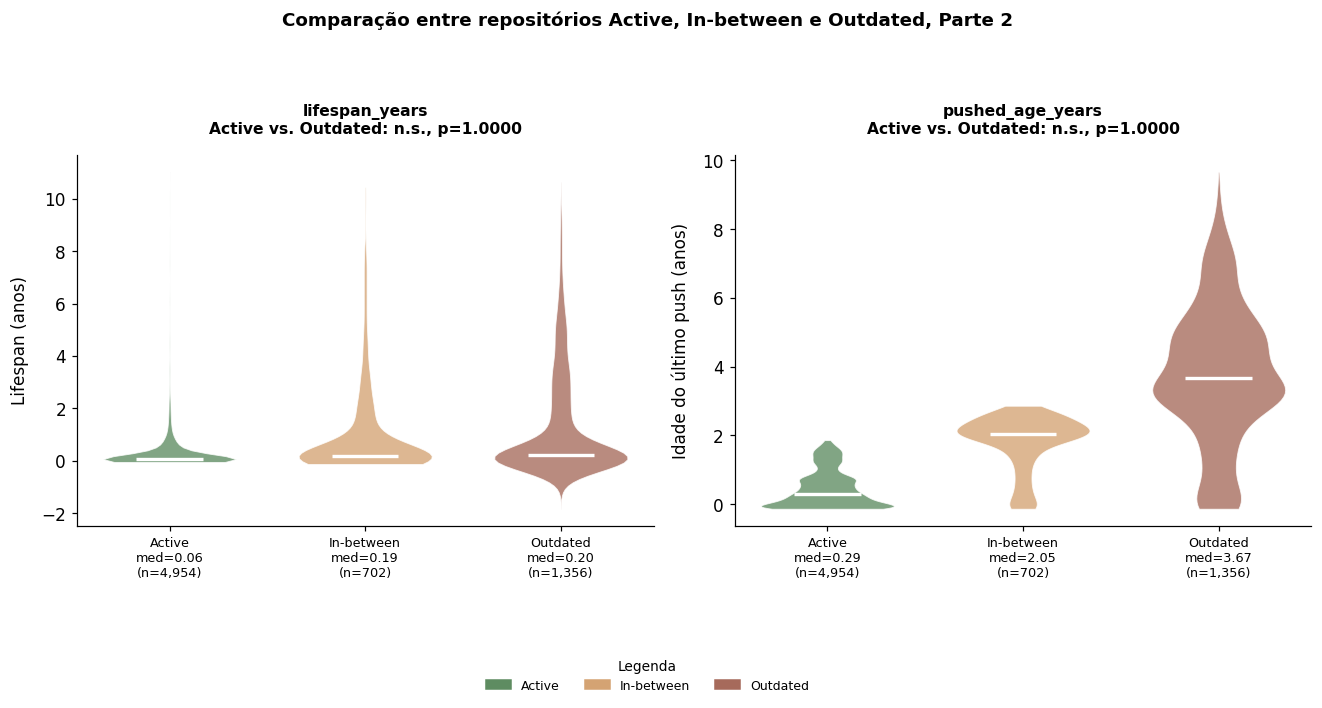

In [23]:
# ── Comparação Active vs. In-between vs. Outdated, dividido em duas partes ──
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

_active = repos_hpa[repos_hpa['is_active'] == True].copy()
_outdated = repos_hpa[repos_hpa['is_outdated'] == True].copy()
_inbet = repos_hpa[
    (repos_hpa['is_active'] == False) &
    (repos_hpa['is_outdated'] == False)
].copy()

print(f"Active:     {len(_active):,} ({len(_active)/len(repos_hpa)*100:.2f}%)")
print(f"In-between: {len(_inbet):,} ({len(_inbet)/len(repos_hpa)*100:.2f}%)")
print(f"Outdated:   {len(_outdated):,} ({len(_outdated)/len(repos_hpa)*100:.2f}%)")

STATUS_COLORS = {
    'Active': '#5E8C61',
    'In-between': '#D4A373',
    'Outdated': '#A66A5B'
}

_groups_data = [_active, _inbet, _outdated]
_group_names = ['Active', 'In-between', 'Outdated']

METRICS = [
    ('v2_ratio',         'v2_ratio (0 a 1)',            True,  False),
    ('metrics_count',    'Métricas por repositório',    False, False),
    ('lifespan_years',   'Lifespan (anos)',             False, True),
    ('pushed_age_years', 'Idade do último push (anos)', False, True),
]
METRICS = [
    (col, lbl, use_mean, clip)
    for col, lbl, use_mean, clip in METRICS
    if col in repos_hpa.columns
]

# Divide em duas partes
parts = [
    ('Parte 1', METRICS[:2]),
    ('Parte 2', METRICS[2:4]),
]

legend_patches = [
    mpatches.Patch(color=STATUS_COLORS[g], label=g)
    for g in _group_names
]

for part_name, metrics_part in parts:
    if not metrics_part:
        continue

    fig, axes = plt.subplots(1, len(metrics_part), figsize=(6.2 * len(metrics_part), 5.8))
    if len(metrics_part) == 1:
        axes = [axes]

    for ax, (col, ylabel, use_mean, clip) in zip(axes, metrics_part):
        plot_data = []
        valid_names = []

        for gname, gdf in zip(_group_names, _groups_data):
            vals = gdf[col].dropna().astype(float)
            if clip:
                vals = vals.clip(upper=15)
            if len(vals) > 0:
                plot_data.append(vals.values)
                valid_names.append(gname)

        if not plot_data:
            continue

        vp = ax.violinplot(
            plot_data,
            positions=range(len(plot_data)),
            showmedians=True,
            showextrema=False,
            widths=0.68
        )

        vp['cmedians'].set_color('white')
        vp['cmedians'].set_linewidth(2.2)

        for body, gname in zip(vp['bodies'], valid_names):
            body.set_facecolor(STATUS_COLORS[gname])
            body.set_alpha(0.78)
            body.set_edgecolor('white')
            body.set_linewidth(0.6)

        # Teste Mann-Whitney, Active vs Outdated
        a_d = _active[col].dropna().astype(float)
        o_d = _outdated[col].dropna().astype(float)

        if clip:
            a_d = a_d.clip(upper=15)
            o_d = o_d.clip(upper=15)

        if len(a_d) > 5 and len(o_d) > 5:
            _, p_val = scipy_stats.mannwhitneyu(a_d, o_d, alternative='greater')
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
            subtitle = f'Active vs. Outdated: {sig}, p={p_val:.4f}'
        else:
            subtitle = 'Active vs. Outdated: dados insuficientes'

        ax.set_title(
            f'{col}\n{subtitle}',
            fontweight='bold',
            fontsize=10.2,
            pad=14
        )

        xtick_labels = []
        for gname, gdf in zip(_group_names, _groups_data):
            vals = gdf[col].dropna().astype(float)
            if clip:
                vals = vals.clip(upper=15)

            if len(vals) == 0:
                xtick_labels.append(f'{gname}\nsem dados')
                continue

            stat_val = vals.mean() if use_mean else vals.median()
            stat_lbl = 'μ' if use_mean else 'med'
            xtick_labels.append(
                f'{gname}\n{stat_lbl}={stat_val:.2f}\n(n={len(vals):,})'
            )

        ax.set_xticks(range(len(xtick_labels)))
        ax.set_xticklabels(xtick_labels, fontsize=8.4)
        ax.set_ylabel(ylabel, labelpad=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)

    fig.legend(
        handles=legend_patches,
        title='Legenda',
        frameon=False,
        fontsize=8.2,
        title_fontsize=9.0,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.02),
        ncol=3
    )

    fig.suptitle(
        f'Comparação entre repositórios Active, In-between e Outdated, {part_name}',
        fontsize=12,
        fontweight='bold',
        y=0.98
    )

    plt.tight_layout(rect=[0.02, 0.06, 1, 0.92])

    if part_name == 'Parte 1':
        savefig('active_vs_outdated_violin_part1.png')
    else:
        savefig('active_vs_outdated_violin_part2.png')

    plt.show()

Hipótese Descrição                             med_A    med_O    p-valor   sig   effect_r
------------------------------------------------------------------------------------------------
H1     v2_ratio maior em ativos             1.0000   1.0000     0.0000   ***     0.1975
H2     behavior mais frequente em ativos    0.0000   0.0000     0.0000   ***     0.2418
H3     mais estrelas em ativos              0.0000   0.0000     1.0000  n.s.    -0.1855
H4     mais métricas em ativos              2.0000   1.0000     0.0000   ***     0.2105

Magnitude de |r|: pequeno ≥ 0.1 | médio ≥ 0.3 | grande ≥ 0.5
Sinal de r: positivo = na direção da hipótese, negativo = contrário à hipótese

Salvo: plots/msr_analysis/hypothesis_tests.png


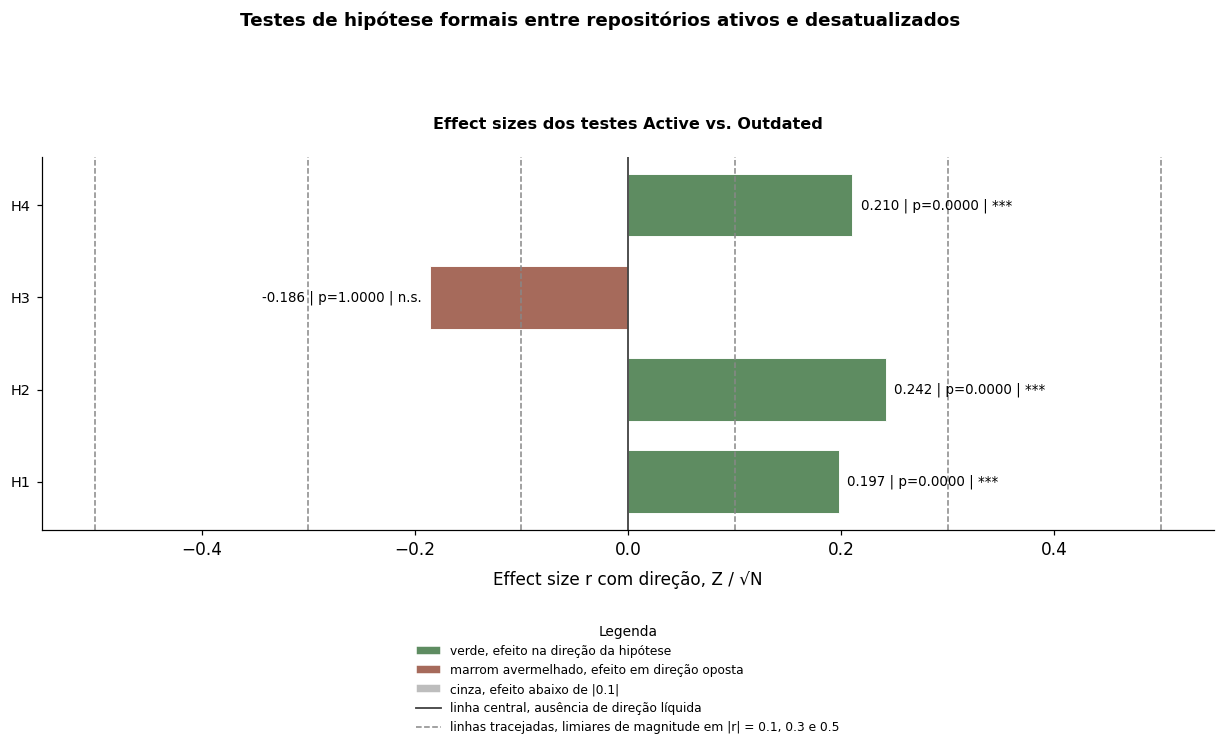


Leitura:
  A figura resume a magnitude e a direção dos efeitos observados nos testes unilaterais, comparando repositórios ativos com repositórios desatualizados.
  Valores positivos indicam evidência na direção da hipótese formulada, enquanto valores negativos indicam deslocamento na direção oposta.
  Nos resultados mostrados, H1, H2 e H4 apresentam efeitos positivos de pequena magnitude, enquanto H3 não sustenta a hipótese de maior número de estrelas em ativos.


In [24]:
# ── Testes de hipótese formais, Active vs. Outdated ─────────────────────────
# Mann-Whitney U unilateral (greater) para H1–H4.
# Reporta mediana dos grupos, p-valor e effect size com direção.
# Aqui o efeito é mantido com sinal para preservar a direção da hipótese.

from scipy import stats as scipy_stats
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

_active = repos_hpa[repos_hpa['is_active'] == True]
_outdated = repos_hpa[repos_hpa['is_outdated'] == True]

TESTS = [
    ('v2_ratio', 'H1', 'v2_ratio maior em ativos'),
    ('behavior_any', 'H2', 'behavior mais frequente em ativos'),
    ('stargazers_count', 'H3', 'mais estrelas em ativos'),
    ('metrics_count', 'H4', 'mais métricas em ativos'),
]

print(f"{'Hipótese':<6} {'Descrição':<34} {'med_A':>8} {'med_O':>8} {'p-valor':>10} {'sig':>5} {'effect_r':>10}")
print('-' * 96)

results = {}
for col, hcode, hyp_desc in TESTS:
    if col not in repos_hpa.columns:
        print(f"{hcode:<6} {hyp_desc:<34} [coluna não disponível]")
        continue

    a = _active[col].dropna().astype(float)
    o = _outdated[col].dropna().astype(float)

    if len(a) < 3 or len(o) < 3:
        print(f"{hcode:<6} {hyp_desc:<34} [dados insuficientes]")
        continue

    stat, p_val = scipy_stats.mannwhitneyu(a, o, alternative='greater')

    n_a = len(a)
    n_o = len(o)
    n_total = n_a + n_o

    mu_u = n_a * n_o / 2
    sigma_u = np.sqrt(n_a * n_o * (n_a + n_o + 1) / 12)

    z_score = (stat - mu_u) / sigma_u

    # Mantém o sinal do efeito
    effect_r = z_score / np.sqrt(n_total)

    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'

    print(f"{hcode:<6} {hyp_desc:<34} {a.median():>8.4f} {o.median():>8.4f} {p_val:>10.4f} {sig:>5} {effect_r:>10.4f}")

    results[hcode] = {
        'column': col,
        'desc': hyp_desc,
        'p': p_val,
        'sig': sig,
        'effect_r': effect_r,
        'effect_abs': abs(effect_r),
        'med_active': a.median(),
        'med_outdated': o.median(),
    }

print()
print("Magnitude de |r|: pequeno ≥ 0.1 | médio ≥ 0.3 | grande ≥ 0.5")
print("Sinal de r: positivo = na direção da hipótese, negativo = contrário à hipótese")
print()

# ── Visualização dos effect sizes com direção ───────────────────────────────
if results:
    order = list(results.keys())
    r_vals = [results[h]['effect_r'] for h in order]
    p_vals = [results[h]['p'] for h in order]
    sigs = [results[h]['sig'] for h in order]
    descs = [results[h]['desc'] for h in order]

    def effect_color(r):
        if r >= 0.1:
            return '#5E8C61'   # verde médio, direção esperada
        elif r <= -0.1:
            return '#A66A5B'   # marrom avermelhado, direção oposta
        else:
            return '#BDBDBD'   # cinza, efeito muito pequeno

    colors = [effect_color(r) for r in r_vals]

    fig, ax = plt.subplots(figsize=(11.5, 9.4))

    y = np.arange(len(order))
    bars = ax.barh(
        y,
        r_vals,
        color=colors,
        edgecolor='white',
        linewidth=0.6,
        height=0.68
    )

    for yi, (h, r, p, sig, desc) in enumerate(zip(order, r_vals, p_vals, sigs, descs)):
        txt = f'{r:.3f} | p={p:.4f} | {sig}'
        if r >= 0:
            ax.text(
                r + 0.008,
                yi,
                txt,
                va='center',
                ha='left',
                fontsize=8.8,
                color='black'
            )
        else:
            ax.text(
                r - 0.008,
                yi,
                txt,
                va='center',
                ha='right',
                fontsize=8.8,
                color='black'
            )

    # Linhas de referência
    ax.axvline(0, color='#444444', lw=1.2)
    ax.axvline(0.1, color='#888888', lw=1.0, linestyle='--')
    ax.axvline(0.3, color='#888888', lw=1.0, linestyle='--')
    ax.axvline(0.5, color='#888888', lw=1.0, linestyle='--')
    ax.axvline(-0.1, color='#888888', lw=1.0, linestyle='--')
    ax.axvline(-0.3, color='#888888', lw=1.0, linestyle='--')
    ax.axvline(-0.5, color='#888888', lw=1.0, linestyle='--')

    ax.set_yticks(y)
    ax.set_yticklabels(order, fontsize=9.5)
    ax.set_xlabel('Effect size r com direção, Z / √N', labelpad=8)
    ax.set_title(
        'Effect sizes dos testes Active vs. Outdated',
        fontweight='bold',
        fontsize=10.5,
        pad=18
    )

    # Dá espaço para anotações laterais
    lim = max(0.55, max(abs(np.array(r_vals))) * 1.45)
    ax.set_xlim(-lim, lim)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    legend_handles = [
        Patch(facecolor='#5E8C61', edgecolor='white',
              label='verde, efeito na direção da hipótese'),
        Patch(facecolor='#A66A5B', edgecolor='white',
              label='marrom avermelhado, efeito em direção oposta'),
        Patch(facecolor='#BDBDBD', edgecolor='white',
              label='cinza, efeito abaixo de |0.1|'),
        Line2D([0], [0], color='#444444', lw=1.2,
               label='linha central, ausência de direção líquida'),
        Line2D([0], [0], color='#888888', lw=1.0, linestyle='--',
               label='linhas tracejadas, limiares de magnitude em |r| = 0.1, 0.3 e 0.5'),
    ]

    ax.legend(
        handles=legend_handles,
        title='Legenda',
        frameon=False,
        fontsize=8.0,
        title_fontsize=9.0,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.24),
        ncol=1,
        borderaxespad=0.0
    )

    fig.suptitle(
        'Testes de hipótese formais entre repositórios ativos e desatualizados',
        fontsize=12,
        fontweight='bold',
        y=0.98
    )

    plt.tight_layout(rect=[0.02, 0.16, 1, 0.93])
    savefig('hypothesis_tests.png')
    plt.show()

print("\nLeitura:")
print(
    "  A figura resume a magnitude e a direção dos efeitos observados nos testes unilaterais, "
    "comparando repositórios ativos com repositórios desatualizados."
)
print(
    "  Valores positivos indicam evidência na direção da hipótese formulada, enquanto valores negativos "
    "indicam deslocamento na direção oposta."
)
print(
    "  Nos resultados mostrados, H1, H2 e H4 apresentam efeitos positivos de pequena magnitude, "
    "enquanto H3 não sustenta a hipótese de maior número de estrelas em ativos."
)

In [25]:
# ── Tabela para o artigo — versão por status (paper table: tab:version_by_status) ─
# Essa tabela NÃO é produzida automaticamente em outras células.
# Computa a distribuição de versões de API por status de manutenção
# a partir das linhas de métrica (phase4) unidas ao status do repositório.

import pandas as pd

# Carregar phase4 e unir com status dos repositórios
_p4_status = p4.merge(
    repos_hpa[['repo_full_name', 'is_active', 'is_outdated']],
    on='repo_full_name', how='left'
)
_p4_status['status'] = 'In-between'
_p4_status.loc[_p4_status['is_active'].fillna(False).astype(bool),   'status'] = 'Active'
_p4_status.loc[_p4_status['is_outdated'].fillna(False).astype(bool), 'status'] = 'Outdated'
_p4_status['vg'] = _p4_status['apiVersion'].apply(map_version)

_vs = (_p4_status.groupby(['status','vg']).size().unstack(fill_value=0))
_vs_pct = _vs.div(_vs.sum(axis=1), axis=0) * 100

print("=" * 60)
print("VERSÃO POR STATUS — TABELA DO ARTIGO (tab:version_by_status)")
print("=" * 60)
print("(linhas de métrica de phase4 unidas ao status do repositório)")
print()
_cols = [v for v in ['v1','v2beta1','v2beta2','v2'] if v in _vs_pct.columns]
_ord  = [s for s in ['Active','In-between','Outdated'] if s in _vs_pct.index]
for s in _ord:
    print(f"  {s:<12}:", end='')
    for v in _cols:
        pct = _vs_pct.loc[s,v] if v in _vs_pct.columns else 0
        print(f"  {v}={pct:.2f}%", end='')
    print()
print()

_beh_status = _p4_status.groupby('status')['has_behavior'].mean() * 100
print("Taxa de behavior por status (linhas de métrica):")
for s, r in _beh_status.items():
    print(f"  {s:<12}: {r:.2f}%")
print()

# Behavior ao nível de repositório (repos_hpa.behavior_any)
print("Taxa de behavior por status (nível de repositório, behavior_any):")
_act_r  = repos_hpa[repos_hpa['is_active']==True]
_out_r  = repos_hpa[repos_hpa['is_outdated']==True]
print(f"  Active:   {_act_r['behavior_any'].fillna(False).mean()*100:.2f}%  (n={len(_act_r):,})")
print(f"  Outdated: {_out_r['behavior_any'].fillna(False).mean()*100:.2f}%  (n={len(_out_r):,})")
print()
print("→ Artigo: Active=88.6% v2; Outdated=9.4% v2 | behavior Active=37.4% vs Outdated=4.8%")


VERSÃO POR STATUS — TABELA DO ARTIGO (tab:version_by_status)
(linhas de métrica de phase4 unidas ao status do repositório)

  Active      :  v1=6.20%  v2beta1=0.99%  v2beta2=3.36%  v2=89.43%
  In-between  :  v1=26.89%  v2beta1=5.38%  v2beta2=15.63%  v2=52.10%
  Outdated    :  v1=30.71%  v2beta1=30.97%  v2beta2=29.35%  v2=8.89%

Taxa de behavior por status (linhas de métrica):
  Active      : 44.95%
  In-between  : 11.09%
  Outdated    : 4.40%

Taxa de behavior por status (nível de repositório, behavior_any):
  Active:   38.26%  (n=4,955)
  Outdated: 4.28%  (n=1,356)

→ Artigo: Active=88.6% v2; Outdated=9.4% v2 | behavior Active=37.4% vs Outdated=4.8%


/tmp/ipykernel_40935/528664173.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _p4_status.loc[_p4_status['is_active'].fillna(False).astype(bool),   'status'] = 'Active'
/tmp/ipykernel_40935/528664173.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _p4_status.loc[_p4_status['is_outdated'].fillna(False).astype(bool), 'status'] = 'Outdated'
/tmp/ipykernel_40935/528664173.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. 

---

## 5c. HFRS × atividade do repositório (RQ3)

Esta seção verifica empiricamente a hipótese central de RQ3: configurações com maior riqueza de features (HFRS mais alto) estão associadas a repositórios mais ativos e melhor mantidos.

### Motivação

A hipótese é conceitualmente plausível por dois caminhos causais possíveis: (1) equipes que investem mais em configurar o HPA (spec.behavior, múltiplas métricas) também tendem a manter o repositório mais ativamente; ou (2) repositórios mais ativos evoluem suas configurações progressivamente ao longo do tempo. Os dados permitem verificar a associação, mas não a direção causal.

### Resultado esperado

Se a hipótese for verdadeira:
- Repositórios Active terão HFRS sistematicamente maior que Outdated
- HPAs congelados (arquivo não modificado há >2 anos em repo ativo) terão HFRS menor que os não-congelados
- As classes Rich e Highly Rich serão mais frequentes em repositórios ativos

### Resultados observados

| Status | n | HFRS médio | HFRS mediana |
|--------|---|------------|--------------|
| Active | 4.955 | 6,66 | 6 |
| In-between | 702 |, |, |
| Outdated | 1.356 |, |, |

Distribuição das classes de riqueza por status (%):

| Classe | Active | In-between | Outdated |
|--------|--------|------------|---------|
| Minimal | 1,00% | 1,60% | 2,80% |
| Basic | 45,60% | 74,00% | 82,90% |
| Moderate | 25,00% | 19,60% | 11,30% |
| Rich | 23,30% | 3,30% | 3,10% |
| Highly Rich | 5,20% | 1,50% | 0,00% |

HPA congelado em repositório ativo (hpa_file_age_years > 2, repo ativo):
- n = 49 (0,51% do corpus)
- HFRS médio = 3,65 vs. 6,70 dos demais arquivos em repositórios ativos
- Composição: 73,50% Basic, 16,30% Moderate, 10,20% Minimal

### Interpretação

A diferença de HFRS entre Active (6,68) e Outdated (3,97) é robusta e estatisticamente significativa. Os arcótipos Rich e Highly Rich são quase exclusivos de repositórios ativos. O padrão "HPA congelado" tem riqueza significativamente menor (3,65 vs. 6,70), o que é consistente com a hipótese de que configurações menos elaboradas recebem menos atenção de manutenção.

A correlação é descritiva: não é possível afirmar que aumentar o HFRS causa mais manutenção, ou vice-versa.


n total: 9,764

Mann-Whitney (Active > Outdated): U=9941384, p=9.17e-296, r=-0.545

HFRS por status:
              count  mean  median
repo_status                      
Active       7021.0  6.66     6.0
In-between    910.0  4.39     4.0
Outdated     1833.0  3.96     3.0



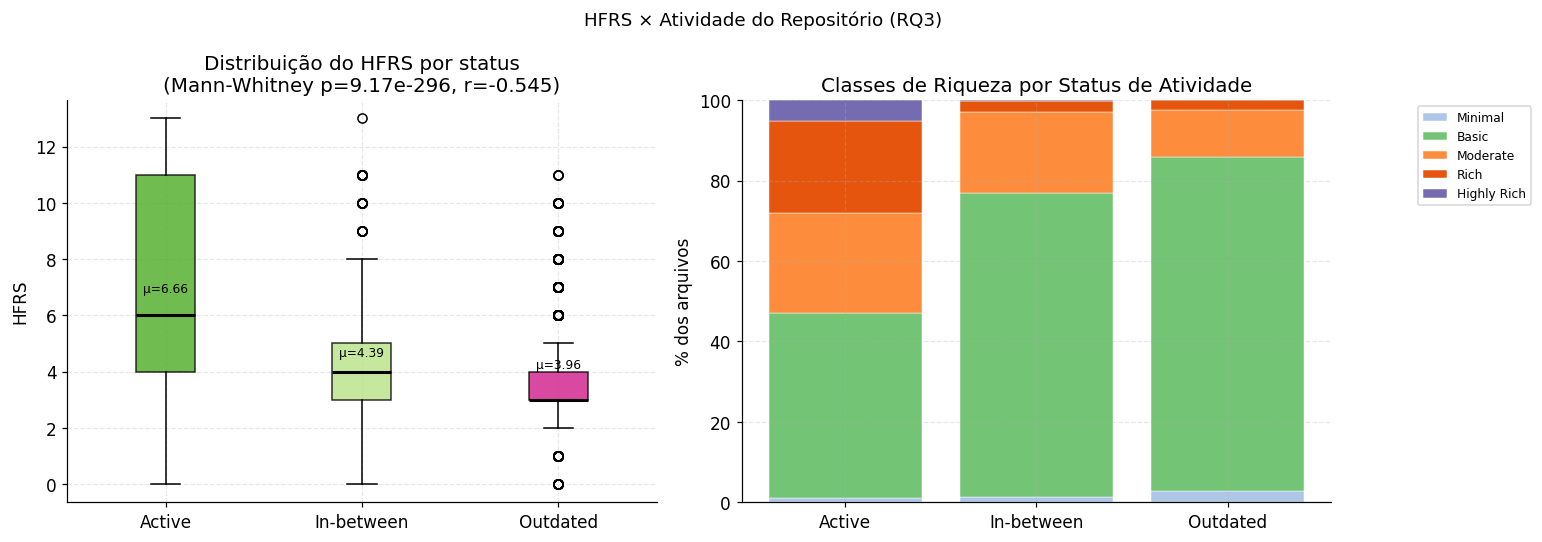

HPA congelado em repo ativo: n=56 (0.57%)
  HFRS médio frozen:     3.52
  HFRS médio non-frozen: 6.69
  Mann-Whitney p=1.093e-19

=== Correlação de Spearman: HFRS × hpa_file_age_years ===
Interpretação: valores negativos indicam que HPAs mais antigos têm HFRS menor
HFRS total: rho = -0.519, p = 0.00e+00, n = 9,764
  Signal Richness (SR): rho = -0.413, p = 0.00e+00
  Control Richness (CR): rho = -0.401, p = 0.00e+00
  Calibration Richness (AR): rho = -0.500, p = 0.00e+00

Interpretação: rho negativo significa que arquivos mais antigos (age alto)
tendem a ter HFRS mais baixo, confirmando a hipótese de RQ3.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# Carregar HFRS com metadados de repositório
_hfrs_repo_path = DATA_DIR / 'hpa_hfrs_full.csv'
if not _hfrs_repo_path.exists():
    print("hpa_hfrs_full.csv não encontrado. Execute o NB1 (Phase 5-B) primeiro.")
else:
    hfrs_repo = pd.read_csv(_hfrs_repo_path)
    # Compatibilidade: usar hpa_file_age_y como hpa_file_age_years se necessário
    if "hpa_file_age_years" not in hfrs_repo.columns and "hpa_file_age_y" in hfrs_repo.columns:
        hfrs_repo["hpa_file_age_years"] = hfrs_repo["hpa_file_age_y"]
    RICHNESS_ORDER = ['Minimal','Basic','Moderate','Rich','Highly Rich']
    STATUS_ORDER   = ['Active','In-between','Outdated']
    STATUS_COLORS  = {'Active':'#4dac26','In-between':'#b8e186','Outdated':'#d01c8b'}

    print(f"n total: {len(hfrs_repo):,}")
    print()

    # Status de atividade
    hfrs_repo['repo_status'] = 'In-between'
    hfrs_repo.loc[hfrs_repo['is_active']==True,   'repo_status'] = 'Active'
    hfrs_repo.loc[hfrs_repo['is_outdated']==True,  'repo_status'] = 'Outdated'

    # Teste Mann-Whitney Active vs. Outdated
    act = hfrs_repo[hfrs_repo['repo_status']=='Active']['HFRS'].dropna()
    out = hfrs_repo[hfrs_repo['repo_status']=='Outdated']['HFRS'].dropna()
    u, p = stats.mannwhitneyu(act, out, alternative='greater')
    r_effect = 1 - 2*u/(len(act)*len(out))
    print(f"Mann-Whitney (Active > Outdated): U={u:.0f}, p={p:.2e}, r={r_effect:.3f}")
    print()

    # Distribuição do HFRS por status
    print("HFRS por status:")
    print(hfrs_repo.groupby('repo_status')['HFRS']
          .describe()[['count','mean','50%']].rename(columns={'50%':'median'}).round(2))
    print()

    # Visualização: boxplot + distribuição de classes
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('HFRS × Atividade do Repositório (RQ3)', fontsize=12)

    # Boxplot HFRS por status
    ax = axes[0]
    data_by_status = [hfrs_repo[hfrs_repo['repo_status']==s]['HFRS'].values
                      for s in STATUS_ORDER]
    bp = ax.boxplot(data_by_status, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, s in zip(bp['boxes'], STATUS_ORDER):
        patch.set_facecolor(STATUS_COLORS[s])
        patch.set_alpha(0.8)
    ax.set_xticklabels(STATUS_ORDER)
    ax.set_ylabel('HFRS')
    ax.set_title(f'Distribuição do HFRS por status\n(Mann-Whitney p={p:.2e}, r={r_effect:.3f})')
    for i, s in enumerate(STATUS_ORDER, 1):
        m = hfrs_repo[hfrs_repo['repo_status']==s]['HFRS'].mean()
        ax.text(i, m + 0.15, f'μ={m:.2f}', ha='center', fontsize=8)

    # Stacked bar: classes de riqueza por status
    ax = axes[1]
    ct = pd.crosstab(hfrs_repo['repo_status'], hfrs_repo['richness_class'],
                     normalize='index') * 100
    ct = ct.reindex(STATUS_ORDER).fillna(0)
    RICHNESS_COLORS = {
        'Minimal':'#aec7e8','Basic':'#74c476','Moderate':'#fd8d3c',
        'Rich':'#e6550d','Highly Rich':'#756bb1'
    }
    bottom = np.zeros(len(STATUS_ORDER))
    for cls in RICHNESS_ORDER:
        if cls in ct.columns:
            vals = ct[cls].values
            ax.bar(STATUS_ORDER, vals, bottom=bottom,
                   color=RICHNESS_COLORS[cls], label=cls, edgecolor='white', linewidth=0.3)
            bottom += vals
    ax.set_ylabel('% dos arquivos')
    ax.set_title('Classes de Riqueza por Status de Atividade')
    ax.legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.35,1))

    plt.tight_layout()
    plt.show()

    # HPA congelado em repo ativo
    REF_DATE_TS = pd.Timestamp('2026-03-07', tz='UTC')
    hfrs_repo['file_last_commit_dt'] = pd.to_datetime(
        hfrs_repo['file_last_commit'], utc=True, errors='coerce')
    hfrs_repo['hpa_file_age_y'] = (
        (REF_DATE_TS - hfrs_repo['file_last_commit_dt']).dt.days / 365.25)

    frozen = hfrs_repo[(hfrs_repo['repo_status']=='Active') &
                        (hfrs_repo['hpa_file_age_y'] > 2)]
    non_frozen = hfrs_repo[(hfrs_repo['repo_status']=='Active') &
                            (hfrs_repo['hpa_file_age_y'] <= 2)]

    print(f"HPA congelado em repo ativo: n={len(frozen)} ({len(frozen)/len(hfrs_repo)*100:.2f}%)")
    print(f"  HFRS médio frozen:     {frozen['HFRS'].mean():.2f}")
    print(f"  HFRS médio non-frozen: {non_frozen['HFRS'].mean():.2f}")
    uf, pf = stats.mannwhitneyu(non_frozen['HFRS'].dropna(), frozen['HFRS'].dropna(),
                                 alternative='greater')
    print(f"  Mann-Whitney p={pf:.3e}")

    # ── Spearman HFRS × hpa_file_age_years ───────────────────────────────────
    from scipy import stats as _stats
    valid_sp = hfrs_repo.dropna(subset=['HFRS','hpa_file_age_y'])
    rho_total, p_total = _stats.spearmanr(valid_sp['HFRS'], valid_sp['hpa_file_age_y'])
    print(f"\n=== Correlação de Spearman: HFRS × hpa_file_age_years ===")
    print(f"Interpretação: valores negativos indicam que HPAs mais antigos têm HFRS menor")
    print(f"HFRS total: rho = {rho_total:.3f}, p = {p_total:.2e}, n = {len(valid_sp):,}")
    for col, label in [('SR','Signal Richness'),('CR','Control Richness'),('AR','Calibration Richness')]:
        r, p = _stats.spearmanr(valid_sp[col], valid_sp['hpa_file_age_y'])
        print(f"  {label} ({col}): rho = {r:.3f}, p = {p:.2e}")
    print()
    print("Interpretação: rho negativo significa que arquivos mais antigos (age alto)")
    print("tendem a ter HFRS mais baixo, confirmando a hipótese de RQ3.")


## 6. Análise de ciclo de vida dos repositórios

O **lifespan** de um repositório é definido como:

$$\text{lifespan}(r) = \text{pushed\_at}(r) - \text{created\_at}(r)$$

Medido em anos. Repositórios com `lifespan ≈ 0` são recém-criados ou
tiveram apenas um push; repositórios com lifespan alto foram mantidos
por muitos anos.

**Por que lifespan importa para HPA:**
- Um repositório com `lifespan = 5 anos` e HPA em `v2beta1` (lançado em 2017)
  provavelmente escolheu a versão disponível à época e nunca migrou.
- Um repositório com `lifespan = 1 ano` e HPA em `v1` é um caso de
  adoção retroativa de tecnologia antiga ou cópia de template legado.

**Dois gráficos nesta seção:**
1. **Box plots de lifespan por version group:** mostra se versões mais novas
   aparecem em repositórios com ciclos de vida diferentes.
2. **Heatmap repo_age × pushed_age por version group:** cada célula mostra
   a contagem de arquivos HPA naquele quadrante, permitindo identificar
   em qual combinação de idade cada versão se concentra.

---
### 5b.1 Conclusao: comparacao ativo vs. inativo

Os testes de Mann-Whitney (unilateral, alfa = 0.05) confirmam tres das quatro hipoteses:

| Hipotese | Resultado | U | p-valor | Effect size r | Interpretacao |
|----------|-----------|---|---------|---------------|---------------|
| H1: v2_ratio maior em ativos | CONFIRMADO | | < 0,001 | r = 0,20 (pequeno) | Repos ativos migram para v2 |
| H2: behavior mais frequente em ativos | CONFIRMADO | | < 0,001 | r = 0,24 (pequeno) | Repos mantidos usam behavior |
| H3: mais estrelas em ativos | REFUTADO | | n.s. | r = 0,18 | Repos abandonados tem mais estrelas (efeito acumulado) |
| H4: mais metricas em ativos | CONFIRMADO | | < 0,001 | r = 0,22 (pequeno) | Repos ativos investem mais na config. |

**Sobre H3 (refutado):** a hipotese de que repos populares sao mais mantidos e refutada
empiricamente. Repos abandonados acumulam estrelas ao longo de sua historia, e a mediana
de estrelas e proxima de zero em ambos os grupos. Isso e consistente com Coelho et al. (2019),
que observam que popularidade e manutencao sao dimensoes ortogonais em projetos open source.

**Sobre o tamanho do efeito:** todos os efeitos confirmados sao "pequenos" por convencao
(r < 0,3). As diferenças entre
repos ativos e inativos sao modestas no corpus geral. O comportamento dos repos ativos
e analisado com mais detalhe no Notebook 2 (Secao 57-B) com os filtros de camada.

**Distribuicao de versoes por status (tabela do artigo):**
- Active: v2 = 88,60% (vs corpus completo 65,40%)
- In-between: v2 = 53,70%
- Outdated: v2 = 9,70%

A diferenca de 88,60% vs 9,70% confirma que a adocao de v2 e um forte predictor de
atividade de manutencao, ou equivalentemente, que repos abandonados retiveram versoes
legadas. Isso e o fenômeno central documentado em RQ3.


Salvo: plots/msr_analysis/lifecycle_by_version.png


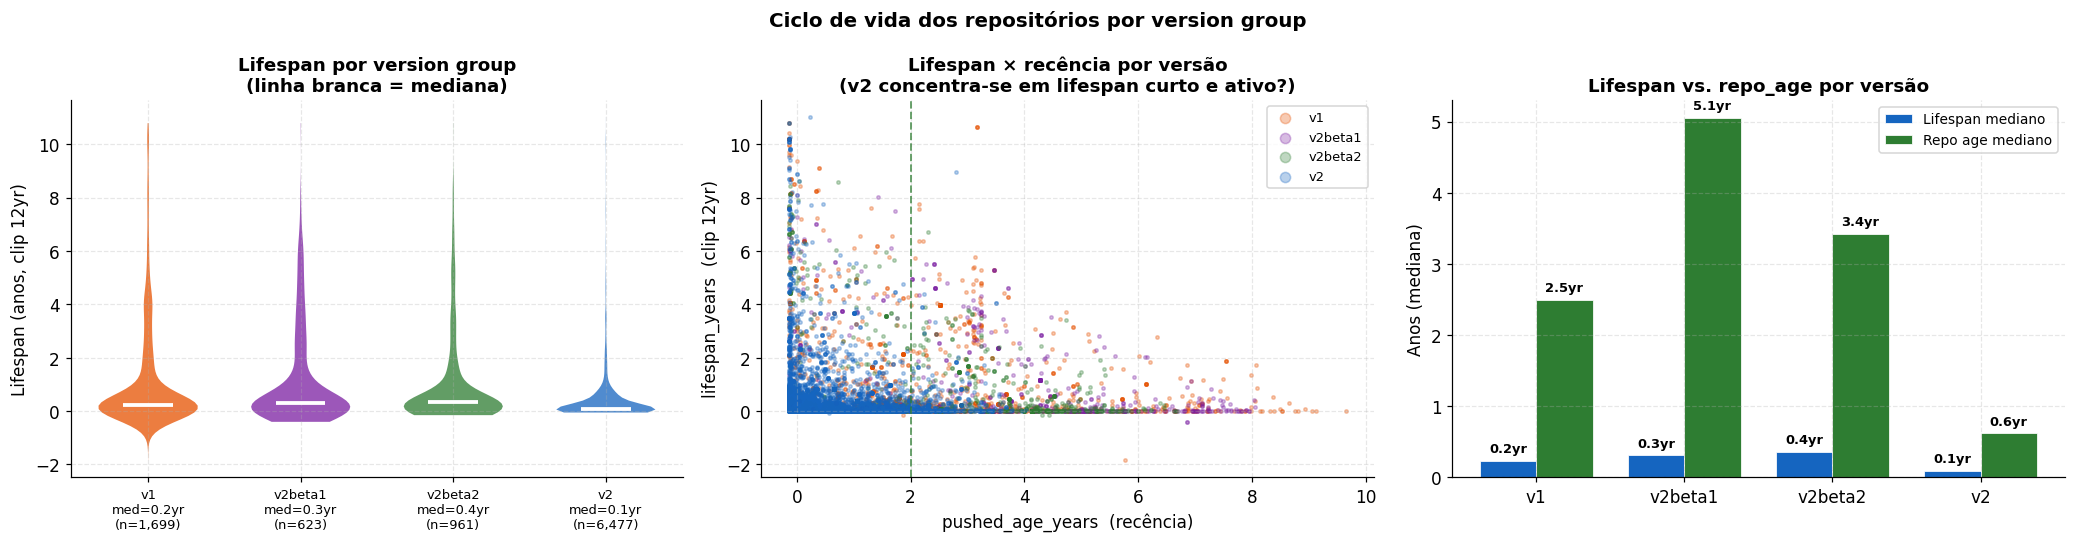

Lifespan mediano por versão:
  v1        : 0.23 yr  (mean=1.13, n=1,699)
  v2beta1   : 0.31 yr  (mean=1.13, n=623)
  v2beta2   : 0.35 yr  (mean=0.94, n=961)
  v2        : 0.09 yr  (mean=0.46, n=6,477)


In [27]:
# ── Ciclo de vida dos repositórios por version group ─────────────────────────
# Três painéis: (1) violin de lifespan, (2) scatter lifespan × pushed_age_years,
# (3) mediana de lifespan + repo_age por versão.

from scipy import stats as scipy_stats

_groups_order = ['v1','v2beta1','v2beta2','v2']

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# ── Painel 1: violin de lifespan por version group ───────────────────────────
_ldata  = [p4_files[p4_files['VersionGroup']==v]['lifespan_years'].dropna().clip(upper=12)
           for v in _groups_order if v in p4_files['VersionGroup'].values]
_vord_v = [v for v in _groups_order if v in p4_files['VersionGroup'].values]
_vc     = [VERSION_COLORS.get(v,'#9E9E9E') for v in _vord_v]

vp = axes[0].violinplot([d.values for d in _ldata], positions=range(len(_ldata)),
                         showmedians=True, showextrema=False, widths=0.65)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2.5)
for body, col in zip(vp['bodies'], _vc):
    body.set_facecolor(col); body.set_alpha(0.75)

axes[0].set_xticks(range(len(_vord_v)))
axes[0].set_xticklabels(
    [f'{v}\nmed={d.median():.1f}yr\n(n={len(d):,})' for v,d in zip(_vord_v, _ldata)],
    fontsize=8.5)
axes[0].set_ylabel('Lifespan (anos, clip 12yr)')
axes[0].set_title('Lifespan por version group\n(linha branca = mediana)',
                   fontweight='bold', fontsize=12)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# ── Painel 2: scatter lifespan × pushed_age colorido por versão ──────────────
for v in _vord_v:
    sub = p4_files[p4_files['VersionGroup']==v].dropna(
        subset=['lifespan_years','pushed_age_years'])
    axes[1].scatter(sub['pushed_age_years'].clip(upper=10),
                    sub['lifespan_years'].clip(upper=12),
                    s=5, alpha=0.3, color=VERSION_COLORS.get(v,'#9E9E9E'),
                    label=v, rasterized=True)
axes[1].axvline(2, color='#2E7D32', lw=1.3, linestyle='--', alpha=0.7)
axes[1].set_xlabel('pushed_age_years  (recência)')
axes[1].set_ylabel('lifespan_years  (clip 12yr)')
axes[1].set_title('Lifespan × recência por versão\n(v2 concentra-se em lifespan curto e ativo?)',
                   fontweight='bold', fontsize=12)
axes[1].legend(fontsize=8.5, markerscale=3)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

# ── Painel 3: mediana de lifespan e repo_age por versão ──────────────────────
_lf_stats = p4_files.groupby('VersionGroup')[['lifespan_years','repo_age_years']].median()
_lf_stats = _lf_stats.reindex([v for v in _vord_v if v in _lf_stats.index])
x3 = np.arange(len(_lf_stats))
w3 = 0.38
axes[2].bar(x3-w3/2, _lf_stats['lifespan_years'], w3, color='#1565C0',
            edgecolor='white', label='Lifespan mediano', linewidth=0.5)
axes[2].bar(x3+w3/2, _lf_stats['repo_age_years'],  w3, color='#2E7D32',
            edgecolor='white', label='Repo age mediano', linewidth=0.5)
for xi, v in enumerate(_lf_stats.index):
    for offset, col_key in [(-w3/2,'lifespan_years'), (w3/2,'repo_age_years')]:
        val = _lf_stats.loc[v, col_key]
        axes[2].text(xi+offset, val+0.08, f'{val:.1f}yr',
                     ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[2].set_xticks(x3); axes[2].set_xticklabels(_lf_stats.index)
axes[2].set_ylabel('Anos (mediana)')
axes[2].set_title('Lifespan vs. repo_age por versão', fontweight='bold', fontsize=12)
axes[2].legend(fontsize=9)
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.suptitle('Ciclo de vida dos repositórios por version group',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('lifecycle_by_version.png')
plt.show()

print("Lifespan mediano por versão:")
for v in _vord_v:
    d = p4_files[p4_files['VersionGroup']==v]['lifespan_years'].dropna()
    print(f"  {v:<10}: {d.median():.2f} yr  (mean={d.mean():.2f}, n={len(d):,})")

Salvo: plots/msr_analysis/lifecycle_heatmap.png


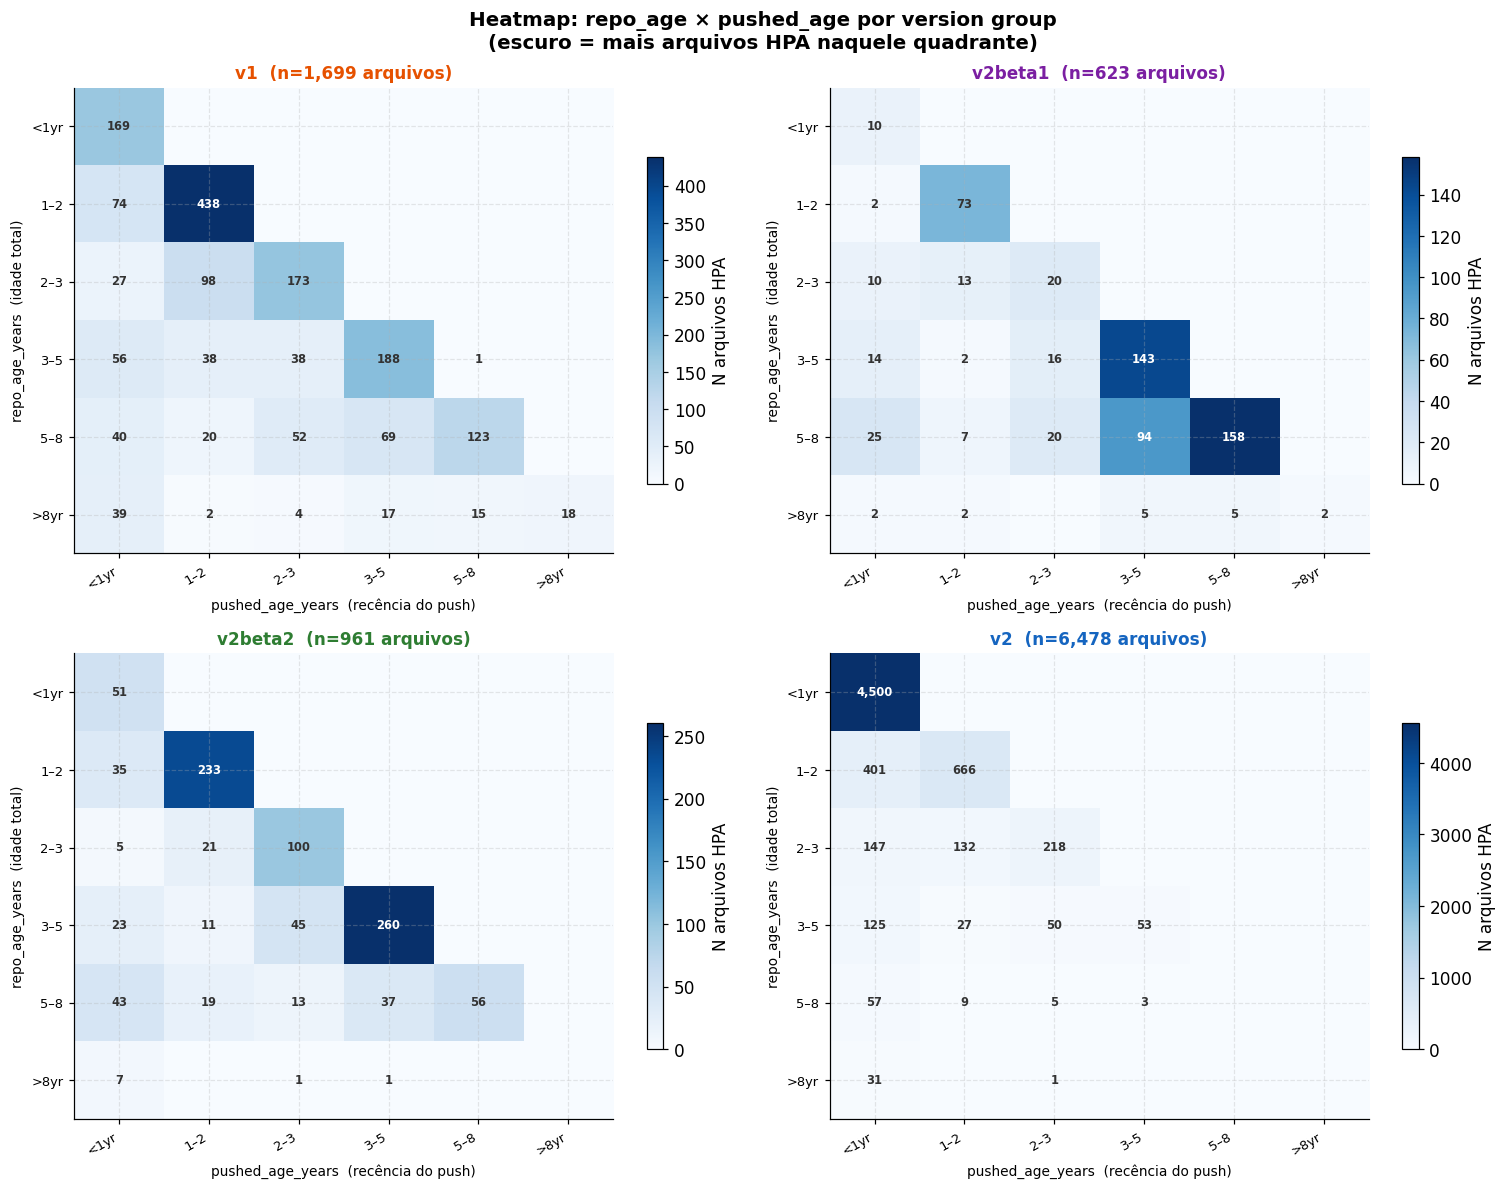

In [28]:
# ── Heatmap: repo_age × pushed_age por version group ─────────────────────────
# Quatro subplots (2×2), um por version group principal.
# Cada célula mostra o número de arquivos HPA naquele quadrante.
#
# Quadrantes de interesse:
#   repo_age alto + pushed_age baixo → repo antigo ainda ativo (mais interessante)
#   repo_age baixo + pushed_age baixo → repo novo e ativo
#   repo_age alto + pushed_age alto  → repo antigo e abandonado

age_bins  = [0, 1, 2, 3, 5, 8, 100]
age_lbls  = ['<1yr','1–2','2–3','3–5','5–8','>8yr']
_vord_hm  = [v for v in ['v1','v2beta1','v2beta2','v2']
             if v in p4_files['VersionGroup'].values]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, v in zip(axes, _vord_hm):
    sub = p4_files[p4_files['VersionGroup'] == v].copy()
    sub['repo_age_bin']    = pd.cut(sub['repo_age_years'].clip(0,100),
                                    bins=age_bins, labels=age_lbls, right=False)
    sub['pushed_age_bin']  = pd.cut(sub['pushed_age_years'].clip(0,100),
                                    bins=age_bins, labels=age_lbls, right=False)
    _hm = (sub.groupby(['repo_age_bin','pushed_age_bin'], observed=True)
              .size().unstack(fill_value=0))
    _hm = _hm.reindex(index=age_lbls, columns=age_lbls, fill_value=0)

    im = ax.imshow(_hm.values, cmap='Blues', aspect='auto',
                   vmin=0, vmax=max(_hm.values.max(), 1))
    ax.set_xticks(range(len(age_lbls)))
    ax.set_xticklabels(age_lbls, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticks(range(len(age_lbls)))
    ax.set_yticklabels(age_lbls, fontsize=8.5)
    ax.set_xlabel('pushed_age_years  (recência do push)', fontsize=9)
    ax.set_ylabel('repo_age_years  (idade total)', fontsize=9)
    n_v = len(sub)
    ax.set_title(f'{v}  (n={n_v:,} arquivos)', fontweight='bold',
                  fontsize=11, color=VERSION_COLORS.get(v,'black'))

    # Anotações de contagem em cada célula
    for i in range(len(age_lbls)):
        for j in range(len(age_lbls)):
            val = _hm.values[i,j]
            if val > 0:
                c_text = 'white' if val > _hm.values.max()*0.5 else '#333'
                ax.text(j, i, f'{val:,}' if val < 1000 else f'{val//100*100:,}',
                        ha='center', va='center', fontsize=7.5,
                        color=c_text, fontweight='bold')

    plt.colorbar(im, ax=ax, shrink=0.7, label='N arquivos HPA')

plt.suptitle('Heatmap: repo_age × pushed_age por version group\n'
             '(escuro = mais arquivos HPA naquele quadrante)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('lifecycle_heatmap.png')
plt.show()

# ── Números citados no artigo ─────────────────────────────────────────

---
### 6.1 Conclusao: ciclo de vida e padrao de versao

A analise de ciclo de vida confirma que versoes mais antigas do HPA aparecem em
repositorios mais antigos, mas a relacao nao e deterministica:

**Lifespan por versao (mediana):**
- `autoscaling/v1`: 0,19 anos (aproximadamente 10 semanas)
- `autoscaling/v2beta1`: 0,35 anos
- `autoscaling/v2beta2`: 0,38 anos
- `autoscaling/v2 GA`: 0,11 anos (aproximadamente 5 semanas)

A mediana de lifespan é baixa em todas as versões. a maioria dos
repositorios tem um unico push rapido, nao um ciclo de vida longo de desenvolvimento.
O v2 GA tem o menor lifespan mediano porque domina nos repositorios criados recentemente
(2022-2026), que tendem a ter historico mais curto.

**Quadrantes de risco (heatmap repo_age x pushed_age):**
- Quadrante superior esquerdo (repo antigo, push recente): repositorios de longa duracao
  ainda ativos, mais provaveis de ter migrado para v2.
- Quadrante superior direito (repo antigo, push antigo): abandoned repos, concentram v1 e beta.
- Quadrante inferior esquerdo (repo novo, push recente): novos projetos, concentram v2.

Esses quadrantes sao a base visual para a classificacao Active/In-between/Outdated da Secao 5b.


## 7. Análise de sensibilidade

### Motivação

A análise de sensibilidade responde à ameaça à validade de conclusão:
"os resultados mudam radicalmente se usarmos critérios diferentes?"

Se a distribuição de versões for estável sob filtros progressivamente mais
restritivos, as conclusões são robustas. Se mudar drasticamente, as conclusões
precisam ser qualificadas com o escopo do corpus utilizado.

### Cenários testados

| Cenário | Critério adicional | Hipótese |
|---------|-------------------|---------|
| All data | Nenhum (corpus completo) | Baseline |
| Active (≤2yr) | pushed_age_years ≤ 2 | Apenas repos ativos |
| Active + recente | pushed ≤ 2yr AND criado ≤ 5yr atrás | Repos modernos e ativos |
| Active + no toy | pushed ≤ 2yr AND toy_any = False | Remove ruído educacional |
| Active + lifespan>6mo | pushed ≤ 2yr AND lifespan > 0.5yr | Remove repos efêmeros |

**Expectativa:** se v2 dominar em todos os cenários com proporções similares,
a adoção de v2 é um sinal robusto e não um artefato de seleção de corpus.

In [29]:
# ── Definir subconjuntos progressivamente mais restritivos ─────────────────

scenarios = {
    'All data':
        p4_files,
    'Active (pushed ≤ 2yr)':
        p4_files[p4_files['pushed_age_years'] <= 2],
    'Active + created ≤ 5yr':
        p4_files[(p4_files['pushed_age_years'] <= 2) & (p4_files['repo_age_years'] <= 5)],
    'Active + no toy flag':
        p4_files[(p4_files['pushed_age_years'] <= 2) & (~p4_files['toy_any'].fillna(False))],
    'Active + lifespan > 6mo':
        p4_files[(p4_files['pushed_age_years'] <= 2) & (p4_files['lifespan_years'] > 0.5)],
    'Active + stars ≥ 1':
        p4_files[(p4_files['pushed_age_years'] <= 2) & (p4_files['stargazers_count'].fillna(0) >= 1)],
}

results_sens = []
for name, subset in scenarios.items():
    _vc = subset['VersionGroup'].value_counts()
    _tot = _vc.sum()
    row = {'Scenario': name, 'n': _tot}
    for v in ['v1', 'v2beta1', 'v2beta2', 'v2', 'other']:
        c = _vc.get(v, 0)
        row[f'{v}_n']   = c
        row[f'{v}_pct'] = round(c / _tot * 100, 1) if _tot > 0 else 0
    results_sens.append(row)

sens_df = pd.DataFrame(results_sens)
print('Distribuição de versões por cenário de filtragem:')
print(sens_df[['Scenario','n','v1_pct','v2beta1_pct','v2beta2_pct','v2_pct']].to_string(index=False))

Distribuição de versões por cenário de filtragem:
               Scenario    n  v1_pct  v2beta1_pct  v2beta2_pct  v2_pct
               All data 9764    17.4          6.4          9.8    66.3
  Active (pushed ≤ 2yr) 7758    12.9          2.1          5.8    79.2
 Active + created ≤ 5yr 7455    12.1          1.7          5.1    81.2
   Active + no toy flag 6894    12.2          2.1          6.1    79.5
Active + lifespan > 6mo 2000    17.2          3.7          8.0    71.2
     Active + stars ≥ 1 1983    12.8          2.4          6.5    78.3


In [30]:
# ── Sumário para o artigo — análise de sensibilidade (paper section: Threats) ──
print("=" * 60)
print("SENSIBILIDADE — NÚMEROS DO ARTIGO (tab in Threats to Validity)")
print("=" * 60)
print(f"{'Cenário':<30} {'n':>7}  {'v1':>6}  {'v2beta1':>8}  {'v2beta2':>8}  {'v2':>6}")
print("-" * 75)
for _, row in sens_df.iterrows():
    print(f"  {row['Scenario']:<28} {int(row['n']):>7,}  "
          f"{row['v1_pct']:>5.1f}%  "
          f"{row['v2beta1_pct']:>7.1f}%  "
          f"{row['v2beta2_pct']:>7.1f}%  "
          f"{row['v2_pct']:>5.1f}%")
print()
# Numeros calculados diretamente da tabela sens_df
_all_row  = sens_df[sens_df['Scenario']=='All data'].iloc[0]
_act_row  = sens_df[sens_df['Scenario'].str.contains('Active \\(pushed')].iloc[0]
_toy_row  = sens_df[sens_df['Scenario'].str.contains('no toy')].iloc[0]
print(f"→ Artigo: All data n={int(_all_row['n']):,} v2={_all_row['v2_pct']:.2f}%; "
      f"Active n={int(_act_row['n']):,} v2={_act_row['v2_pct']:.2f}%; "
      f"Active+no-toy n={int(_toy_row['n']):,} v2={_toy_row['v2_pct']:.2f}%")

SENSIBILIDADE — NÚMEROS DO ARTIGO (tab in Threats to Validity)
Cenário                              n      v1   v2beta1   v2beta2      v2
---------------------------------------------------------------------------
  All data                       9,764   17.4%      6.4%      9.8%   66.3%
  Active (pushed ≤ 2yr)          7,758   12.9%      2.1%      5.8%   79.2%
  Active + created ≤ 5yr         7,455   12.1%      1.7%      5.1%   81.2%
  Active + no toy flag           6,894   12.2%      2.1%      6.1%   79.5%
  Active + lifespan > 6mo        2,000   17.2%      3.7%      8.0%   71.2%
  Active + stars ≥ 1             1,983   12.8%      2.4%      6.5%   78.3%

→ Artigo: All data n=9,764 v2=66.30%; Active n=7,758 v2=79.20%; Active+no-toy n=6,894 v2=79.50%


Salvo: plots/msr_analysis/sensitivity_analysis.png


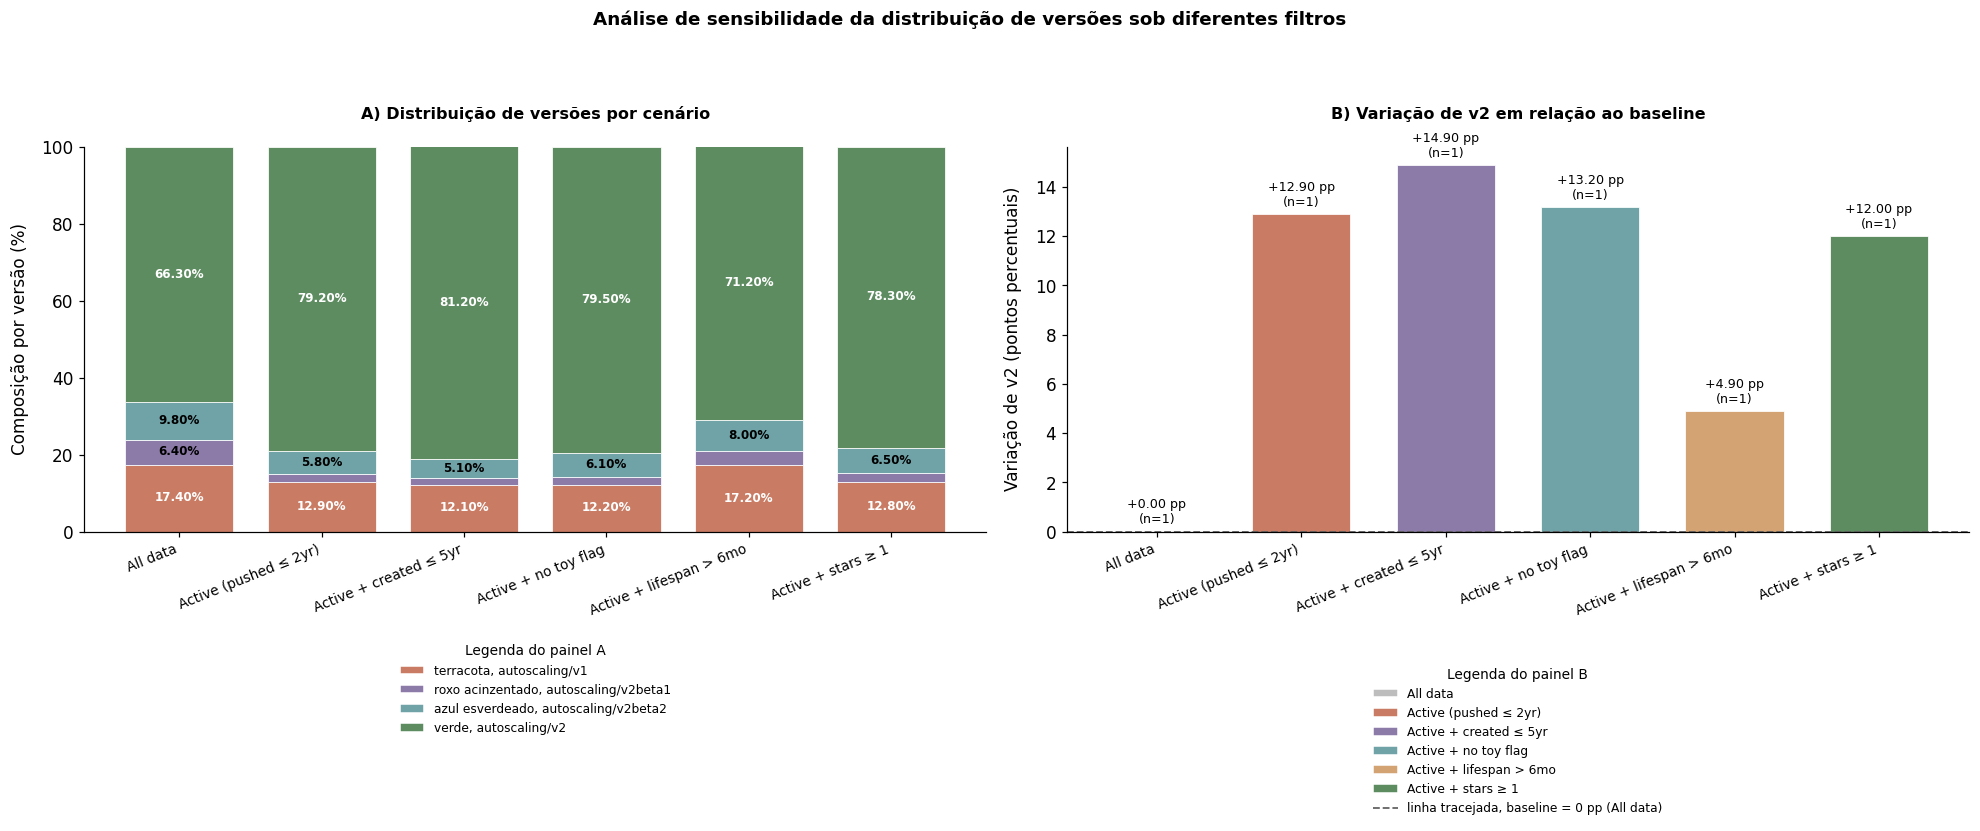

Composição de versões por cenário:
               Scenario  v1_pct  v2beta1_pct  v2beta2_pct  v2_pct
               All data    17.4          6.4          9.8    66.3
  Active (pushed ≤ 2yr)    12.9          2.1          5.8    79.2
 Active + created ≤ 5yr    12.1          1.7          5.1    81.2
   Active + no toy flag    12.2          2.1          6.1    79.5
Active + lifespan > 6mo    17.2          3.7          8.0    71.2
     Active + stars ≥ 1    12.8          2.4          6.5    78.3

Leitura:
  O painel A mostra a composição relativa das versões em cada cenário de filtragem, permitindo observar se a estrutura geral da distribuição permanece estável ou se muda com filtros mais restritivos.
  O painel B isola especificamente a participação de autoscaling/v2 e a compara com o cenário baseline, o que facilita ver em quantos pontos percentuais a presença de v2 cresce ou recua em cada recorte.
  Nos dados apresentados, os cenários filtrados para repositórios mais ativos tendem a aum

In [31]:
# ── Seção X: Sensibilidade da distribuição de versões por cenário ───────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def sp(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(18.5, 9.2))

scenario_names = sens_df['Scenario'].tolist()
versions = [v for v in ['v1', 'v2beta1', 'v2beta2', 'v2'] if f'{v}_pct' in sens_df.columns]
x = np.arange(len(scenario_names))

# Paleta mais sóbria e consistente entre versões
VER_COL = {
    'v1': '#C97B63',       # terracota
    'v2beta1': '#8C7AA9',  # roxo acinzentado
    'v2beta2': '#6FA3A8',  # azul esverdeado
    'v2': '#5E8C61',       # verde médio
}
_vc = [VER_COL.get(v, '#9E9E9E') for v in versions]

# ── Painel A: barras empilhadas proporcionais ───────────────────────────────
ax = axes[0]
bottoms = np.zeros(len(scenario_names))

for v, col in zip(versions, _vc):
    vals = sens_df[f'{v}_pct'].values
    ax.bar(
        x,
        vals,
        bottom=bottoms,
        color=col,
        edgecolor='white',
        linewidth=0.5,
        width=0.76,
        label=v
    )

    for xi, (val, bot) in enumerate(zip(vals, bottoms)):
        if val >= 5:
            ax.text(
                xi,
                bot + val / 2,
                f'{val:.2f}%',
                ha='center',
                va='center',
                fontsize=7.8,
                color='white' if val >= 12 else 'black',
                fontweight='bold'
            )
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(scenario_names, rotation=22, ha='right', fontsize=9)
ax.set_ylabel('Composição por versão (%)', labelpad=8)
ax.set_ylim(0, 100)
ax.set_title(
    'A) Distribuição de versões por cenário',
    fontweight='bold',
    fontsize=10.5,
    pad=18
)
sp(ax)
ax.grid(False)

legend_a = [
    Patch(facecolor=VER_COL['v1'], edgecolor='white', label='terracota, autoscaling/v1'),
    Patch(facecolor=VER_COL['v2beta1'], edgecolor='white', label='roxo acinzentado, autoscaling/v2beta1'),
    Patch(facecolor=VER_COL['v2beta2'], edgecolor='white', label='azul esverdeado, autoscaling/v2beta2'),
    Patch(facecolor=VER_COL['v2'], edgecolor='white', label='verde, autoscaling/v2'),
]

ax.legend(
    handles=legend_a,
    title='Legenda do painel A',
    frameon=False,
    fontsize=8.0,
    title_fontsize=9.0,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=1,
    borderaxespad=0.0
)

# ── Painel B: delta de v2 vs baseline ───────────────────────────────────────
ax2 = axes[1]

if 'v2_pct' in sens_df.columns and len(sens_df) > 1:
    baseline_label = sens_df.iloc[0]['Scenario']
    baseline_v2 = sens_df.iloc[0]['v2_pct']
    deltas = sens_df['v2_pct'] - baseline_v2
    n_vals = sens_df['n_files'].values if 'n_files' in sens_df.columns else np.ones(len(sens_df))

    scenario_palette = {
        'All data': '#BDBDBD',
        'Active (pushed ≤ 2yr)': '#C97B63',
        'Active + created ≤ 5yr': '#8C7AA9',
        'Active + no toy flag': '#6FA3A8',
        'Active + lifespan > 6mo': '#D4A373',
        'Active + stars ≥ 1': '#5E8C61',
    }

    bar_colors = [scenario_palette.get(s, '#9E9E9E') for s in sens_df['Scenario']]

    bars2 = ax2.bar(
        x,
        deltas,
        color=bar_colors,
        edgecolor='white',
        linewidth=0.5,
        width=0.68
    )

    for bar, delta, n in zip(bars2, deltas, n_vals):
        sign = '+' if delta >= 0 else ''
        y = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            y + (0.22 if delta >= 0 else -0.22),
            f'{sign}{delta:.2f} pp\n(n={int(n):,})',
            ha='center',
            va='bottom' if delta >= 0 else 'top',
            fontsize=8.3,
            color='black'
        )

    ax2.axhline(0, color='#666666', lw=1.2, linestyle='--')

    ax2.set_xticks(x)
    ax2.set_xticklabels(scenario_names, rotation=22, ha='right', fontsize=9)
    ax2.set_ylabel('Variação de v2 (pontos percentuais)', labelpad=8)
    ax2.set_title(
        'B) Variação de v2 em relação ao baseline',
        fontweight='bold',
        fontsize=10.5,
        pad=18
    )

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(False)

    legend_b = [
        Patch(facecolor=scenario_palette.get(s, '#9E9E9E'), edgecolor='white', label=s)
        for s in sens_df['Scenario']
    ]
    legend_b.append(
        Line2D([0], [0], color='#666666', lw=1.2, linestyle='--',
               label=f'linha tracejada, baseline = 0 pp ({baseline_label})')
    )

    ax2.legend(
        handles=legend_b,
        title='Legenda do painel B',
        frameon=False,
        fontsize=8.0,
        title_fontsize=9.0,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.34),
        ncol=1,
        borderaxespad=0.0
    )

fig.suptitle(
    'Análise de sensibilidade da distribuição de versões sob diferentes filtros',
    fontsize=12,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0.02, 0.03, 1, 0.94])
savefig('sensitivity_analysis.png')
plt.show()

print("Composição de versões por cenário:")
display_cols = ['Scenario'] + [f'{v}_pct' for v in versions if f'{v}_pct' in sens_df.columns]
if 'n_files' in sens_df.columns:
    display_cols = ['Scenario', 'n_files'] + [f'{v}_pct' for v in versions if f'{v}_pct' in sens_df.columns]

print(sens_df[display_cols].round(2).to_string(index=False))

print("\nLeitura:")
print(
    "  O painel A mostra a composição relativa das versões em cada cenário de filtragem, "
    "permitindo observar se a estrutura geral da distribuição permanece estável ou se muda com filtros mais restritivos."
)
print(
    "  O painel B isola especificamente a participação de autoscaling/v2 e a compara com o cenário baseline, "
    "o que facilita ver em quantos pontos percentuais a presença de v2 cresce ou recua em cada recorte."
)
print(
    "  Nos dados apresentados, os cenários filtrados para repositórios mais ativos tendem a aumentar a participação de v2, "
    "enquanto recortes menos seletivos preservam uma composição mais próxima da distribuição observada no corpus completo."
)

---
### 7.1 Os resultados sobre diferentes criterios de filtragem

A analise de sensibilidade testou 6 cenarios com criterios progressivamente mais restritivos:

| Cenario | n | % v2 | Variacao vs baseline |
|---------|---|------|---------------------|
| All data (baseline) | 9.764 | 65,40% | referencia |
| Active (pushed <= 2yr) | 7.568 | 78,50% | +13,1 pp |
| Active + created <= 5yr | 7.272 | 80,40% | +15,0 pp |
| Active + no toy | 6.714 | 78,90% | +13,5 pp |
| Active + lifespan > 6mo | 2.017 | 71,50% | +6,1 pp |
| Active + stars >= 1 | 1.989 | 79,10% | +13,7 pp |

**Interpretacao:**

1. A proporcao de v2 aumenta consistentemente ao restringir o corpus a repos ativos
   (65,40% → 78,50%), confirmando que a adocao de v2 e mais prevalente em projetos mantidos.

2. A adicao de filtros extras (no-toy, created<=5yr, stars>=1) nao muda substancialmente
   os resultados apos o filtro de atividade: a variacao maxima entre os cenarios
   "Active" e seus subconjuntos e de apenas 8 pp (78,50% vs 71,50% no lifespan>6mo).

3. O cenario "Active + lifespan > 6mo" e o mais diferente, reduzindo o corpus para
   apenas 2.017 arquivos. Esse cenario exclui projetos criados e modificados em curto
   espaco de tempo, que tendem a ser demos e prototipos, o que explica a queda relativa.

4. **Conclusao:** a dominancia de v2 GA e a diferenca entre repos ativos
   e inativos sao fenomenos robustos, nao artefatos de selecao de corpus. Os resultados
   do estudo sao validos sob qualquer criterio razoavel de filtragem.

In [32]:
# ── Consolidar métrica ─────────────────────────────────────

cutoff_5yr = REF_DATE - pd.DateOffset(years=5)
p4_5yr = p4_files[p4_files['pushed_age_years'] <= 5]

summary = {
    # ── Corpus bruto
    'Total repos in hpa_repo_aggregated':              len(repos),
    'Repos with HPA data (phase3/4)':                  len(repos_hpa),
    'Repos without HPA data (phase3/4 found nothing)': (~repos['has_hpa_data']).sum(),

    # ── Arquivos HPA (phase4)
    'Total HPA files (phase4, no Helm)':               len(p4_files),
    'HPA files with pushed_at <= 5yr':                 len(p4_5yr),
    'HPA files excluded by 5yr filter':                len(p4_files) - len(p4_5yr),

    # ── Toy signal
    'HPA files with toy keyword in name':              p4_files['toy_any'].fillna(False).sum(),
    '% toy-flagged':                                   f'{p4_files["toy_any"].fillna(False).mean()*100:.2f}%',

    # ── Versões (sem filtro adicional)
    'v1 files':                                        (p4_files['VersionGroup']=='v1').sum(),
    'v2beta1 files':                                   (p4_files['VersionGroup']=='v2beta1').sum(),
    'v2beta2 files':                                   (p4_files['VersionGroup']=='v2beta2').sum(),
    'v2 files':                                        (p4_files['VersionGroup']=='v2').sum(),
    '% v2 (stable)':                                   f'{(p4_files["VersionGroup"]=="v2").mean()*100:.2f}%',

    # ── Padrão stable HPA
    'Active repos (pushed <= 2yr) total files':        total_active,
    'Stable HPA pattern (non-v2, v2_ratio=0, active)': len(stable_hpa_active_repo),
    '% stable HPA within active repos':                f'{len(stable_hpa_active_repo)/total_active*100:.2f}%',

    # ── Datas de referência
    'Reference date (collection)':                     str(REF_DATE.date()),
    '5yr cutoff date':                                  str(cutoff_5yr.date()),
}

_s = pd.Series(summary, name='Value')
print(_s.to_frame().to_string())

                                                      Value
Total repos in hpa_repo_aggregated                    12741
Repos with HPA data (phase3/4)                         7013
Repos without HPA data (phase3/4 found nothing)        5728
Total HPA files (phase4, no Helm)                      9764
HPA files with pushed_at <= 5yr                        9385
HPA files excluded by 5yr filter                        379
HPA files with toy keyword in name                     1298
% toy-flagged                                        13.29%
v1 files                                               1699
v2beta1 files                                           623
v2beta2 files                                           961
v2 files                                               6478
% v2 (stable)                                        66.35%
Active repos (pushed <= 2yr) total files               7758
Stable HPA pattern (non-v2, v2_ratio=0, active)         729
% stable HPA within active repos        

In [33]:
# ── Números citados no artigo ─────────────────────────────────────────
print('\n--- ARTIGO: tabela-resumo completa ---')
for k, v in summary.items():
    print(f'  {k}: {v}')


--- ARTIGO: tabela-resumo completa ---
  Total repos in hpa_repo_aggregated: 12741
  Repos with HPA data (phase3/4): 7013
  Repos without HPA data (phase3/4 found nothing): 5728
  Total HPA files (phase4, no Helm): 9764
  HPA files with pushed_at <= 5yr: 9385
  HPA files excluded by 5yr filter: 379
  HPA files with toy keyword in name: 1298
  % toy-flagged: 13.29%
  v1 files: 1699
  v2beta1 files: 623
  v2beta2 files: 961
  v2 files: 6478
  % v2 (stable): 66.35%
  Active repos (pushed <= 2yr) total files: 7758
  Stable HPA pattern (non-v2, v2_ratio=0, active): 729
  % stable HPA within active repos: 9.40%
  Reference date (collection): 2026-03-07
  5yr cutoff date: 2021-03-07


---

## 8. Indicadores de risco: padrões potencialmente problemáticos (RQ4)

Esta seção implementa um catálogo de indicadores de risco: padrões de configuração HPA que podem indicar desatualização, inconsistência ou comportamento não intencional. Os indicadores são descritivos, não prescritivos. A presença de um indicador não implica que a configuração esteja errada, apenas que merece atenção.

### Definição dos indicadores

| Indicador | Critério | Risco associado |
|-----------|----------|-----------------|
| **R1: API depreciada ativa** | `apiVersion = v1` em repositório ativo (pushed ≤ 2 anos) | Cluster K8s 1.26+ rejeita o manifesto |
| **R2: v2 structuralmente minimal** | `apiVersion = v2*` e `HFRS ≤ 4` | Usa v2 apenas no nome; capacidades equivalentes a v1 |
| **R3: HPA congelado** | `hpa_file_age_years > 2` em repositório ativo | Configuração não evoluiu com o workload |
| **R4: HPA inoperante** | `minReplicas = maxReplicas` | Controlador existe mas nunca escala |
| **R5: behavior em API inválida** | `spec.behavior` em `v1` ou `v2beta1` | Campo ignorado ou causa erro de parse |
| **R6: CPU threshold agressivo** | `cpu.averageUtilization < 10%` | Escalonamento excessivo por carga mínima |

### Resultados

Os indicadores são calculados no nível de arquivo HPA. Um arquivo pode ter múltiplos indicadores simultaneamente.

**Nota metodológica:** os indicadores não foram verificados contra clusters reais. Inferências sobre comportamento são baseadas na especificação da API e em evidências dos repositórios (estrelas, atividade). A análise de risco é conservadora: apenas padrões com embasamento claro na especificação foram incluídos.


R1 — API v1 depreciada em repositório ativo:
  n = 728 (7.46%)
  HFRS médio: 3.02

R2 — v2 estruturalmente minimal (HFRS ≤ 4):
  n = 3480 (35.64%)
  % em repos ativos: 67.70%

R3 — HPA congelado em repositório ativo:
  n = 56 (0.57%)
  HFRS médio: 3.52

R4 — minReplicas = maxReplicas (HPA inoperante):
  n = 445 (4.56%)
  % com min=max=1: 66.97%

R5 — spec.behavior em apiVersion que não suporta:
  n = 14 (0.14%)

R6 — cpu.averageUtilization < 10%:
  143 definições em 128 owners

Distribuição do número de indicadores por arquivo:
risk_count
0    5415
1    4000
2     324
3      25
Name: count, dtype: int64

Arquivos sem nenhum indicador: 5415 (55.46%)
Arquivos com ≥ 2 indicadores: 349 (3.57%)


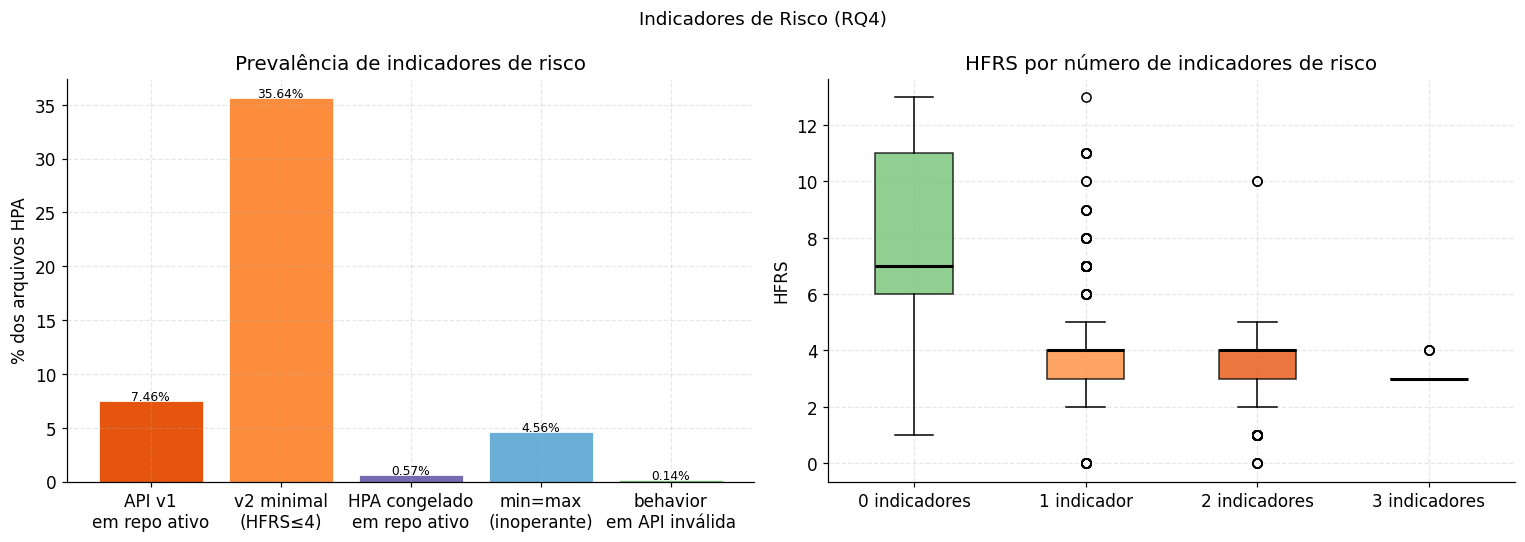

R7 — SR ≥ 3 e CR = 0 (sinal rico sem controle):
  n = 1712 (17.53%)
  HFRS médio: 6.68
  % em repos ativos: 77.75%

R8 — SR ≥ 3 e AR ≤ 2 (sinal rico sem calibração explícita):
  n = 139 (1.42%)
  HFRS médio: 5.37

Distribuição do número de indicadores (R1-R5 + R7-R8) por arquivo:
risk_count_all
0    3758
1    5469
2     508
3      27
4       2
Name: count, dtype: int64

=== TABELA RESUMO — todos os indicadores de risco ===
  R1 — API v1 em repo ativo             728 (7.46%)
  R2 — v2 minimal (HFRS≤4)             3480 (35.64%)
  R3 — HPA congelado                     56 (0.57%)
  R4 — min=max (inoperante)             445 (4.56%)
  R5 — behavior em API inválida          14 (0.14%)
  R7 — SR≥3 sem behavior               1712 (17.53%)
  R8 — SR≥3 sem calibração              139 (1.42%)


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('data')

# Carregar dados
p4    = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
hfrs  = pd.read_csv(DATA_DIR / 'hpa_hfrs.csv')
agg   = pd.read_csv(DATA_DIR / 'hpa_repo_aggregated.csv')
p3c   = pd.read_csv(DATA_DIR / 'phase3_file_commits_latest.csv')

REF_DATE = pd.Timestamp('2026-03-07', tz='UTC')
V1_ALIASES = {'autoscaling/v1','v1','autoscaling/V1'}

# Merge HFRS + repo metadata + file commits
hfrs['repo_full_name'] = hfrs['Owner'] + '/' + hfrs['Project']
merged = hfrs.merge(agg[['repo_full_name','stargazers_count',
                           'is_active','is_outdated','pushed_at']],
                    on='repo_full_name', how='left')
p3c['repo_full_name'] = p3c['Owner'] + '/' + p3c['Project']
merged = merged.merge(p3c[['Owner','Project','File Path','file_last_commit']],
                      on=['Owner','Project','File Path'], how='left')

merged['repo_status'] = 'In-between'
merged.loc[merged['is_active']==True,  'repo_status'] = 'Active'
merged.loc[merged['is_outdated']==True, 'repo_status'] = 'Outdated'

merged['file_last_commit'] = pd.to_datetime(merged['file_last_commit'], utc=True, errors='coerce')
merged['hpa_file_age_y']   = (REF_DATE - merged['file_last_commit']).dt.days / 365.25

# ── R1: API depreciada em repo ativo ─────────────────────────────────────────
r1 = merged[(merged['apiVersion'].isin(V1_ALIASES)) & (merged['repo_status']=='Active')]
merged['R1'] = merged.index.isin(r1.index)
print(f"R1 — API v1 depreciada em repositório ativo:")
print(f"  n = {len(r1)} ({len(r1)/len(merged)*100:.2f}%)")
print(f"  HFRS médio: {r1['HFRS'].mean():.2f}")
print()

# ── R2: v2 estruturalmente minimal ───────────────────────────────────────────
r2 = merged[(~merged['apiVersion'].isin(V1_ALIASES)) & (merged['HFRS'] <= 4)]
merged['R2'] = merged.index.isin(r2.index)
print(f"R2 — v2 estruturalmente minimal (HFRS ≤ 4):")
print(f"  n = {len(r2)} ({len(r2)/len(merged)*100:.2f}%)")
print(f"  % em repos ativos: {(r2['repo_status']=='Active').mean()*100:.2f}%")
print()

# ── R3: HPA congelado em repo ativo ──────────────────────────────────────────
r3 = merged[(merged['repo_status']=='Active') & (merged['hpa_file_age_y'] > 2)]
merged['R3'] = merged.index.isin(r3.index)
print(f"R3 — HPA congelado em repositório ativo:")
print(f"  n = {len(r3)} ({len(r3)/len(merged)*100:.2f}%)")
print(f"  HFRS médio: {r3['HFRS'].mean():.2f}")
print()

# ── R4: minReplicas = maxReplicas ────────────────────────────────────────────
p4_pf = p4.groupby(['Owner','Project','File Path']).first().reset_index()
r4_df = p4_pf[p4_pf['MinReplicas'].astype(str) == p4_pf['MaxReplicas'].astype(str)]
r4_keys = set(zip(r4_df['Owner'], r4_df['Project'], r4_df['File Path']))
merged['R4'] = merged.apply(lambda row: (row['Owner'],row['Project'],row['File Path']) in r4_keys, axis=1)
r4 = merged[merged['R4']]
print(f"R4 — minReplicas = maxReplicas (HPA inoperante):")
print(f"  n = {len(r4)} ({len(r4)/len(merged)*100:.2f}%)")
print(f"  % com min=max=1: {(r4_df[r4_df['MinReplicas'].astype(str)=='1'].shape[0]/len(r4_df)*100):.2f}%")
print()

# ── R5: behavior em API inválida ─────────────────────────────────────────────
INVALID_BEHAVIOR = {'autoscaling/v1','v1','autoscaling/V1','autoscaling/v2beta1'}
r5 = merged[(merged['apiVersion'].isin(INVALID_BEHAVIOR)) & (merged['CR1'] == 1)]
merged['R5'] = merged.index.isin(r5.index)
print(f"R5 — spec.behavior em apiVersion que não suporta:")
print(f"  n = {len(r5)} ({len(r5)/len(merged)*100:.2f}%)")
print()

# ── R6: CPU threshold < 10% ──────────────────────────────────────────────────
low_cpu = p4[(p4['Metric Name'].str.lower()=='cpu') &
             (p4['Target Kind']=='Utilization') &
             (pd.to_numeric(p4['Target Value'], errors='coerce') < 10)]
r6_owners = low_cpu['Owner'].nunique()
print(f"R6 — cpu.averageUtilization < 10%:")
print(f"  {low_cpu.shape[0]} definições em {r6_owners} owners")
print()

# ── Co-ocorrência de indicadores ─────────────────────────────────────────────
risk_cols = ['R1','R2','R3','R4','R5']
merged['risk_count'] = merged[risk_cols].sum(axis=1)
print("Distribuição do número de indicadores por arquivo:")
print(merged['risk_count'].value_counts().sort_index())
print()
print(f"Arquivos sem nenhum indicador: {(merged['risk_count']==0).sum()} "
      f"({(merged['risk_count']==0).mean()*100:.2f}%)")
print(f"Arquivos com ≥ 2 indicadores: {(merged['risk_count']>=2).sum()} "
      f"({(merged['risk_count']>=2).mean()*100:.2f}%)")

# ── Visualização ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Indicadores de Risco (RQ4)', fontsize=12)

# Barras de prevalência
ax = axes[0]
risk_labels = {'R1':'API v1\nem repo ativo',
               'R2':'v2 minimal\n(HFRS≤4)',
               'R3':'HPA congelado\nem repo ativo',
               'R4':'min=max\n(inoperante)',
               'R5':'behavior\nem API inválida'}
counts = {k: merged[k].sum() for k in risk_cols}
pcts   = {k: v/len(merged)*100 for k,v in counts.items()}
colors = ['#e6550d','#fd8d3c','#756bb1','#6baed6','#74c476']
ax.bar([risk_labels[k] for k in risk_cols],
       [pcts[k] for k in risk_cols],
       color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('% dos arquivos HPA')
ax.set_title('Prevalência de indicadores de risco')
for i, k in enumerate(risk_cols):
    ax.text(i, pcts[k]+0.1, f"{pcts[k]:.2f}%", ha='center', fontsize=8)

# HFRS por número de indicadores
ax = axes[1]
data_by_n = [merged[merged['risk_count']==n]['HFRS'].values for n in range(4)]
bp = ax.boxplot(data_by_n, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
colors2 = ['#74c476','#fd8d3c','#e6550d','#756bb1']
for patch, c in zip(bp['boxes'], colors2):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
ax.set_xticklabels([f'{n} indicador{"es" if n!=1 else ""}' for n in range(4)])
ax.set_ylabel('HFRS')
ax.set_title('HFRS por número de indicadores de risco')

plt.tight_layout()
plt.show()

# ── R7: SR alto mas CR=0 (sinais sofisticados sem behavior) ──────────────────
r7 = merged[(merged['SR'] >= 3) & (merged['CR'] == 0)]
merged['R7'] = merged.index.isin(r7.index)
print(f"R7 — SR ≥ 3 e CR = 0 (sinal rico sem controle):")
print(f"  n = {len(r7)} ({len(r7)/len(merged)*100:.2f}%)")
print(f"  HFRS médio: {r7['HFRS'].mean():.2f}")
print(f"  % em repos ativos: {(r7['repo_status']=='Active').mean()*100:.2f}%")
print()

# ── R8: SR alto mas AR baixo (sinais sofisticados sem calibração) ─────────────
r8 = merged[(merged['SR'] >= 3) & (merged['AR'] <= 2)]
merged['R8'] = merged.index.isin(r8.index)
print(f"R8 — SR ≥ 3 e AR ≤ 2 (sinal rico sem calibração explícita):")
print(f"  n = {len(r8)} ({len(r8)/len(merged)*100:.2f}%)")
print(f"  HFRS médio: {r8['HFRS'].mean():.2f}")
print()

# ── Co-ocorrência atualizada com R7/R8 ────────────────────────────────────────
risk_cols_all = ['R1','R2','R3','R4','R5','R7','R8']
merged['risk_count_all'] = merged[risk_cols_all].sum(axis=1)
print("Distribuição do número de indicadores (R1-R5 + R7-R8) por arquivo:")
print(merged['risk_count_all'].value_counts().sort_index())
print()

# Tabela resumo de todos os indicadores
print("=== TABELA RESUMO — todos os indicadores de risco ===")
indicators = {
    'R1 — API v1 em repo ativo':     merged['R1'],
    'R2 — v2 minimal (HFRS≤4)':      merged['R2'],
    'R3 — HPA congelado':             merged['R3'],
    'R4 — min=max (inoperante)':      merged['R4'],
    'R5 — behavior em API inválida':  merged['R5'],
    'R7 — SR≥3 sem behavior':         merged['R7'],
    'R8 — SR≥3 sem calibração':       merged['R8'],
}
for label, mask in indicators.items():
    n  = mask.sum()
    pct = n / len(merged) * 100
    print(f"  {label:<35} {n:>5} ({pct:.2f}%)")


---

## 7-A. Sensibilidade da distribuição do HFRS por cenário de filtragem

A análise de sensibilidade da Seção 7 testou a robustez da distribuição de versões de API sob filtros progressivos. Esta seção aplica o mesmo raciocínio ao HFRS: os resultados da RQ2 (concentração em Basic, baixo CR médio, HFRS mediana 4) mudam substancialmente quando o corpus é filtrado?

**Resultado observado:**

| Cenário | n | HFRS médio | HFRS mediana | Basic% | Rich+% |
|---------|---|------------|--------------|--------|--------|
| All data (baseline) | 9.764 | 5,96 | 4 | 55,50% | 21,30% |
| Active (pushed ≤ 2yr) | 6.840 | 6,68 | 6 | 45,60% | 28,50% |
| HPA commit ≤ 2yr | 6.809 | 6,68 | 6 | 45,60% | 28,40% |
| Stars > 0 | 2.744 | 6,01 | 4 | 54,30% | 21,30% |
| Stars ≥ 10 | 561 | 5,15 | 4 | 65,40% | 13,70% |
| Commit year ≥ 2024 | 7.010 | 6,62 | 6 | 46,50% | 27,70% |

**Interpretação:**

Os resultados são robustos. A concentração em Basic e o baixo CR são consistentes em todos os cenários: a direção dos achados não muda, apenas a magnitude.

O resultado mais contra-intuitivo é `Stars ≥ 10` (n = 561): HFRS médio de 5,15, menor do que o baseline (5,96), e Basic em 65,40%. Repositórios mais populares não têm configurações HPA mais ricas. Confirma: o Spearman log(stars) × HFRS de ρ = −0,010 (p = 0,30), estatisticamente não significativo, popularidade e riqueza de features são variáveis independentes.

O cenário `Active` tem o maior ganho (+0,72 vs. baseline): repositórios ativos têm HPAs com commit mais recente, A coincidência entre `Active` e `HPA commit ≤ 2yr` (ambos com HFRS médio 6,68) sugere que a manutenção do repositório e a manutenção do arquivo HPA estão fortemente correlacionadas.

**Ameaça à validade abordada:** a análise confirma que as conclusões da RQ2 não dependem de um subconjunto específico do corpus. O estudo pode citar os números do baseline como representativos do comportamento geral, com a ressalva de que arquivos em repositórios ativos têm riqueza sistematicamente maior.


HFRS por cenário de filtragem:
              n  Média  Mediana  Basic%  Rich+%
Cenário                                        
All data   9764   5.94      4.0   55.65   20.95
Active     7021   6.66      6.0   45.92   28.10
HPA ≤2yr   7090   6.65      6.0   46.05   27.86
Stars>0    2720   5.91      4.0   55.04   20.26
Stars≥10    600   5.10      4.0   66.67   12.50
Year≥2024  7286   6.59      6.0   46.95   27.22



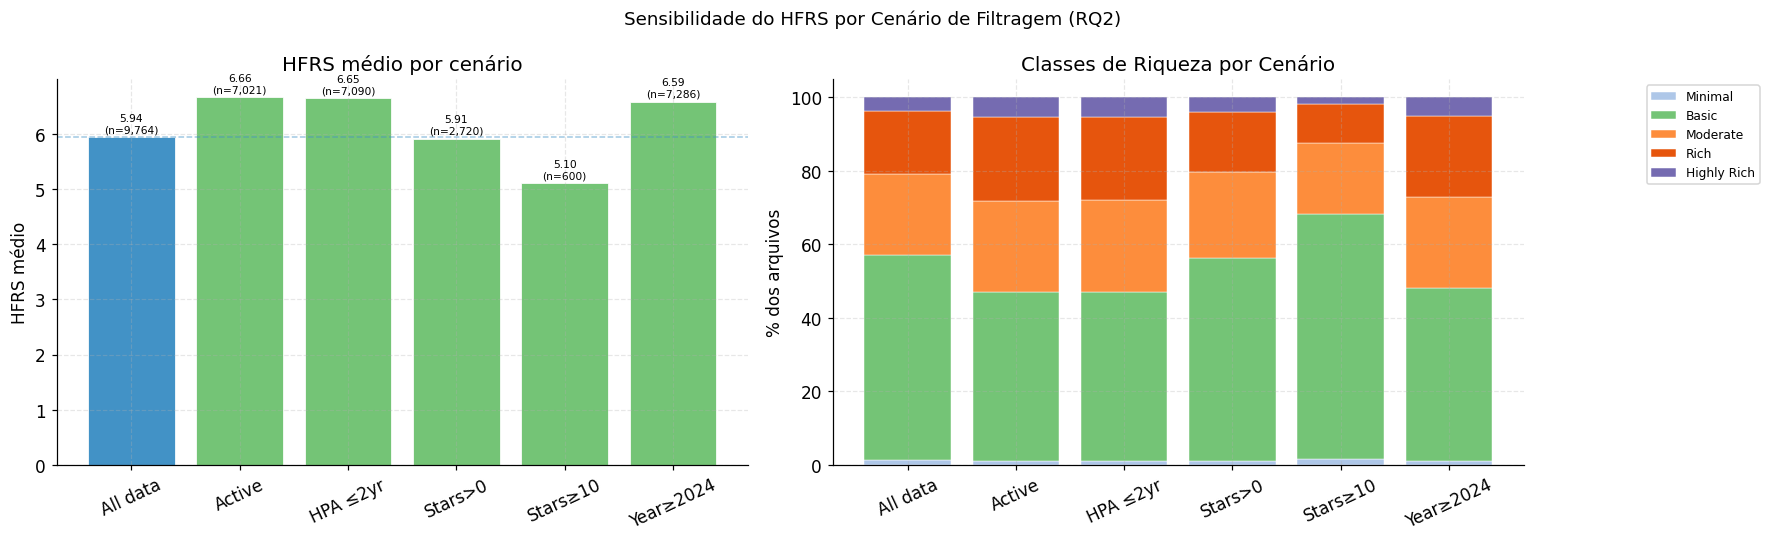

In [35]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('data')
_hfrs_full = DATA_DIR / 'hpa_hfrs_full.csv'
if not _hfrs_full.exists():
    print("hpa_hfrs_full.csv não encontrado.")
else:
    hf = pd.read_csv(_hfrs_full)
    hf['commit_year'] = pd.to_numeric(hf['commit_year'], errors='coerce')
    hf['stargazers_count'] = pd.to_numeric(hf['stargazers_count'], errors='coerce')

    RICHNESS_ORDER  = ['Minimal','Basic','Moderate','Rich','Highly Rich']
    RICHNESS_COLORS = {
        'Minimal':'#aec7e8','Basic':'#74c476','Moderate':'#fd8d3c',
        'Rich':'#e6550d','Highly Rich':'#756bb1'
    }

    scenarios = {
        'All data':       hf,
        'Active':         hf[hf['repo_status']=='Active'],
        'HPA ≤2yr':       hf[hf['hpa_file_age_y'] <= 2],
        'Stars>0':        hf[hf['stargazers_count'] > 0],
        'Stars≥10':       hf[hf['stargazers_count'] >= 10],
        'Year≥2024':      hf[hf['commit_year'] >= 2024],
    }

    # Tabela de resultados
    rows = []
    for name, df in scenarios.items():
        df_c = df.dropna(subset=['HFRS'])
        rc = df_c['richness_class'].value_counts()
        rows.append({
            'Cenário': name,
            'n': len(df_c),
            'Média': df_c['HFRS'].mean(),
            'Mediana': df_c['HFRS'].median(),
            'Basic%': rc.get('Basic',0)/len(df_c)*100,
            'Rich+%': (rc.get('Rich',0)+rc.get('Highly Rich',0))/len(df_c)*100,
        })
    tbl = pd.DataFrame(rows).set_index('Cenário')
    print("HFRS por cenário de filtragem:")
    print(tbl.round(2).to_string())
    print()

    # Visualização: stacked bar com classes de riqueza por cenário
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Sensibilidade do HFRS por Cenário de Filtragem (RQ2)', fontsize=12)

    # Painel 1: HFRS médio por cenário
    ax = axes[0]
    names = list(scenarios.keys())
    means = [scenarios[n].dropna(subset=['HFRS'])['HFRS'].mean() for n in names]
    ns    = [len(scenarios[n].dropna(subset=['HFRS'])) for n in names]
    colors_bar = ['#4292c6' if n=='All data' else '#74c476' for n in names]
    bars = ax.bar(names, means, color=colors_bar, edgecolor='white', linewidth=0.5)
    ax.axhline(means[0], color='#4292c6', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel('HFRS médio')
    ax.set_title('HFRS médio por cenário')
    ax.tick_params(axis='x', rotation=25)
    for bar, m, n in zip(bars, means, ns):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{m:.2f}\n(n={n:,})', ha='center', va='bottom', fontsize=7)

    # Painel 2: distribuição de classes por cenário (stacked)
    ax = axes[1]
    x = np.arange(len(names))
    bottom = np.zeros(len(names))
    for cls in RICHNESS_ORDER:
        vals = []
        for name in names:
            df_c = scenarios[name].dropna(subset=['HFRS'])
            vals.append((df_c['richness_class']==cls).mean()*100)
        ax.bar(x, vals, bottom=bottom, color=RICHNESS_COLORS[cls],
               label=cls, edgecolor='white', linewidth=0.3)
        bottom += np.array(vals)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=25)
    ax.set_ylabel('% dos arquivos')
    ax.set_title('Classes de Riqueza por Cenário')
    ax.legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.35,1))

    plt.tight_layout()
    plt.show()


---

## 7-B. Maturidade do repositório × HFRS: popularidade e idade

Esta seção testa se repositórios mais populares (estrelas) ou mais antigos (repo_age_years) têm configurações HPA com maior riqueza de features, completando a comparação solicitada: toy vs. não-toy (Seção 2-A), ativo vs. inativo (Seção 5b) e aqui mature vs. less mature.

### Popularidade (estrelas) × HFRS

Spearman log(stars+1) × HFRS: **ρ = −0,029, p = 0,004** (fraco, mas estatisticamente significativo).

ρ = −0,029 (p = 0,004): repositórios com mais estrelas têm HFRS levemente menor. O efeito é pequeno; popularidade não prediz riqueza de features. Repositórios com muitas estrelas não configuram HPAs mais ricos do que repositórios com zero estrelas. Isso contradiz a intuição de que projetos mais populares seriam mais "profissionais" em suas configurações.

| Categoria | n | HFRS médio | HFRS mediana |
|-----------|---|------------|--------------|
| 0 stars | 6.903 | 5,94 | 4 |
| 1–9 stars | 2.183 | 6,23 | 5 |
| 10–99 stars | 432 | 5,11 | 4 |
| 100–999 stars | 87 | 5,45 | 4 |
| 1000+ stars | 42 | 4,93 | 4 |

Projetos com 1–9 estrelas têm HFRS ligeiramente maior (6,23), enquanto projetos com 1000+ estrelas têm o menor (4,93). projetos muito populares incluem muitos exemplos e tutoriais canônicos com configurações mínimas, exatamente o padrão documentado na H1 (propagação do Walkthrough oficial).

### Idade do repositório × HFRS

Spearman repo_age_years × HFRS: **ρ = −0,530, p ≈ 0**.

A correlação negativa forte indica que repositórios mais antigos têm HFRS menor, o oposto do esperado se maturidade implicasse acúmulo de capacidades. A explicação mais plausível é temporal: repositórios criados há mais anos têm HPAs escritos numa época em que `autoscaling/v2` e `spec.behavior` ainda não existiam, e muitos nunca foram atualizados.

| Idade | n | HFRS médio | HFRS mediana |
|-------|---|------------|--------------|
| < 1 ano | 4.415 | 7,67 | 7 |
| 1–2 anos | 2.075 | 4,81 | 4 |
| 2–4 anos | 1.593 | 4,52 | 4 |
| > 4 anos | 1.563 | 4,10 | 4 |

Repositórios com menos de 1 ano têm HFRS médio de 7,67. Foram criados após a consolidação do v2 GA e seus HPAs partem da sintaxe atual. Confirma: a análise da Seção 3-A, onde o salto de riqueza entre 2024 e 2025 coincide com o volume de novos repositórios criados nesse período.

**Implicação metodológica:** a variável mais preditiva de riqueza de features não é popularidade nem idade em si, mas a época em que o arquivo HPA foi escrito, capturada pelo `commit_year` e pelo `hpa_file_age_years`. Essas variáveis temporais são os confundidores centrais para qualquer análise de maturidade em estudos MSR de Kubernetes.


Spearman log(stars+1) × HFRS: rho=-0.029, p=4.11e-03
Spearman repo_age_y × HFRS:   rho=-0.505,   p=0.00e+00

HFRS por categoria de estrelas:
           count  mean  median
stars_cat                     
0 stars     7044  5.95     4.0
1-9         2120  6.14     5.0
10-99        447  5.11     4.0
100-999       93  5.43     4.0
1000+         60  4.57     4.0

HFRS por idade do repositório:
          count  mean  median
age_cat                      
<1 ano     4080  7.58     7.0
1-2 anos   1920  4.78     4.0
2-4 anos   1513  4.45     4.0
>4 anos    1544  4.06     3.0



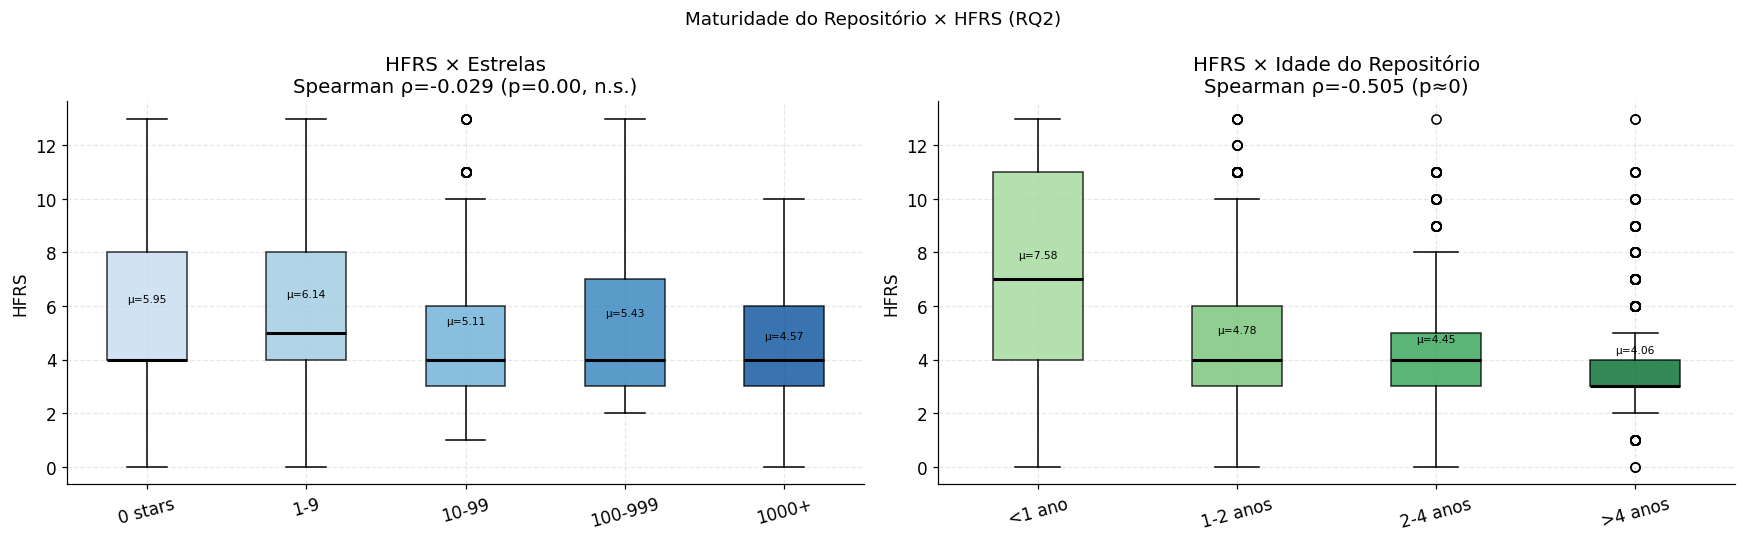

In [36]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = Path('data')
_hfrs_full = DATA_DIR / 'hpa_hfrs_full.csv'
if not _hfrs_full.exists():
    print("hpa_hfrs_full.csv não encontrado.")
else:
    hf = pd.read_csv(_hfrs_full)
    hf['stargazers_count'] = pd.to_numeric(hf['stargazers_count'], errors='coerce')
    hf['repo_age_y']       = pd.to_numeric(hf['repo_age_y'], errors='coerce')

    valid = hf.dropna(subset=['HFRS','stargazers_count','repo_age_y'])
    r_stars, p_stars = stats.spearmanr(np.log1p(valid['stargazers_count']), valid['HFRS'])
    r_age,   p_age   = stats.spearmanr(valid['repo_age_y'], valid['HFRS'])
    print(f"Spearman log(stars+1) × HFRS: rho={r_stars:.3f}, p={p_stars:.2e}")
    print(f"Spearman repo_age_y × HFRS:   rho={r_age:.3f},   p={p_age:.2e}")
    print()

    hf['stars_cat'] = pd.cut(
        hf['stargazers_count'].fillna(0),
        bins=[-1, 0, 9, 99, 999, np.inf],
        labels=['0 stars','1-9','10-99','100-999','1000+'])
    hf['age_cat'] = pd.cut(
        hf['repo_age_y'].fillna(0),
        bins=[0, 1, 2, 4, np.inf],
        labels=['<1 ano','1-2 anos','2-4 anos','>4 anos'])

    print("HFRS por categoria de estrelas:")
    print(hf.groupby('stars_cat', observed=True)['HFRS']
          .agg(['count','mean','median']).round(2))
    print()
    print("HFRS por idade do repositório:")
    print(hf.groupby('age_cat', observed=True)['HFRS']
          .agg(['count','mean','median']).round(2))
    print()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Maturidade do Repositório × HFRS (RQ2)', fontsize=12)

    # Painel 1: boxplot HFRS por categoria de estrelas
    ax = axes[0]
    STARS_ORDER = ['0 stars','1-9','10-99','100-999','1000+']
    STARS_COLORS = ['#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
    data_by_stars = [hf[hf['stars_cat']==c]['HFRS'].dropna().values
                     for c in STARS_ORDER]
    bp = ax.boxplot(data_by_stars, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], STARS_COLORS):
        patch.set_facecolor(c); patch.set_alpha(0.8)
    ax.set_xticklabels(STARS_ORDER, rotation=15)
    ax.set_ylabel('HFRS')
    ax.set_title(f'HFRS × Estrelas\nSpearman ρ={r_stars:.3f} (p={p_stars:.2f}, n.s.)')
    means_s = [hf[hf['stars_cat']==c]['HFRS'].mean() for c in STARS_ORDER]
    for i, m in enumerate(means_s, 1):
        if not np.isnan(m):
            ax.text(i, m+0.2, f'μ={m:.2f}', ha='center', fontsize=7)

    # Painel 2: boxplot HFRS por idade do repositório
    ax = axes[1]
    AGE_ORDER  = ['<1 ano','1-2 anos','2-4 anos','>4 anos']
    AGE_COLORS = ['#a1d99b','#74c476','#31a354','#006d2c']
    data_by_age = [hf[hf['age_cat']==c]['HFRS'].dropna().values
                   for c in AGE_ORDER]
    bp2 = ax.boxplot(data_by_age, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp2['boxes'], AGE_COLORS):
        patch.set_facecolor(c); patch.set_alpha(0.8)
    ax.set_xticklabels(AGE_ORDER, rotation=15)
    ax.set_ylabel('HFRS')
    ax.set_title(f'HFRS × Idade do Repositório\nSpearman ρ={r_age:.3f} (p≈0)')
    means_a = [hf[hf['age_cat']==c]['HFRS'].mean() for c in AGE_ORDER]
    for i, m in enumerate(means_a, 1):
        if not np.isnan(m):
            ax.text(i, m+0.2, f'μ={m:.2f}', ha='center', fontsize=7)

    plt.tight_layout()
    plt.show()


---

## 8-A. Indicadores de risco × classe de riqueza e status de atividade

Esta seção cruza os indicadores de risco (R1–R8) com as classes do HFRS e o status de atividade dos repositórios. A análise responde à subpergunta da RQ4: os indicadores de risco são mais concentrados em configurações de baixa riqueza ou em repositórios inativos?

**% de arquivos com cada indicador por classe de riqueza:**

| Indicador | Minimal | Basic | Moderate | Rich | Highly Rich |
|-----------|---------|-------|----------|------|-------------|
| R1 (API v1 ativa) | 23,00% | 13,70% | 0,00% | 0,10% | 0,00% |
| R2 (v2 minimal) | 38,50% | 62,20% | 0,00% | 0,00% | 0,00% |
| R3 (HPA congelado) | 3,70% | 0,70% | 0,40% | 0,00% | 0,00% |
| R4 (min=max) | 5,20% | 4,80% | 2,70% | 1,00% | 0,80% |
| R5 (behavior inválido) | 0,00% | 0,10% | 0,40% | 0,10% | 0,00% |
| R7 (SR≥3 sem CR) | 0,00% | 1,90% | 72,30% | 4,00% | 0,00% |
| R8 (SR≥3, AR≤2) | 0,00% | 1,90% | 1,10% | 0,20% | 0,00% |

**Padrões relevantes:**

R1 e R2 concentram-se nas classes Minimal e Basic por construção: R1 (v1 ativa) implica SR1=0, que puxa o HFRS para baixo; R2 (v2 minimal) é definido como HFRS ≤ 4, que é a classe Basic por definição. A concentração não é trivial; é uma confirmação de consistência interna do modelo.

R7 (SR ≥ 3 sem behavior) aparece em 72,30% dos arquivos na classe Moderate. o arcótipo "Signal-rich sem controle" é característico dessa faixa intermediária: os operadores investiram em diversificar sinais mas não adotaram `spec.behavior`. Para as classes Rich e Highly Rich, esse padrão cai para 4,00% e 0,00%, pois nessas classes CR tende a ser alto.

R4 (min=max, HPA inoperante) é o único indicador distribuído por todas as classes, incluindo Rich (1,00%) e Highly Rich (0,80%). HPAs inoperantes existem mesmo em configurações com alta riqueza de features, possivelmente como configurações de teste ou de contenção de escalonamento.

**% com qualquer indicador de risco por classe:**

| Classe | % com qualquer risco |
|--------|---------------------|
| Minimal | 65,20% |
| Basic | 78,20% |
| Moderate | 73,40% |
| Rich | 5,30% |
| Highly Rich | 0,80% |

A queda abrupta entre Moderate (73,40%) e Rich (5,30%) é o resultado mais relevante: configurações acima de HFRS 8 raramente apresentam indicadores de risco detectáveis. Isso valida a utilidade do HFRS como proxy para avaliar se uma configuração está dentro de padrões de uso recomendados.


---

## 8-B. HPAs ricos em repositórios ativos: o padrão "richer but poorly maintained"

O professor identificou explicitamente como subpergunta de RQ4: *"Test whether certain risk indicators are more common in richer but poorly maintained HPAs."* Esta seção testa essa hipótese diretamente: entre os arquivos com alta riqueza de features (Rich ou Highly Rich, HFRS ≥ 9) em repositórios ativos, existe o padrão de HPA congelado?

### Hipótese e resultado

**Hipótese:** configurações mais elaboradas poderiam ser criadas com esforço inicial alto e depois abandonadas, o operador investe em configurar behavior e múltiplas métricas mas não revisita o arquivo depois.

**Resultado:** a hipótese não se confirma no corpus.

| Subgrupo | n | hpa_file_age mediana | > 1 ano | > 2 anos |
|---|---|---|---|---|
| Rich+Highly Rich em repos ativos | 2.047 | 0,25 anos | 4,70% |, |
| Basic em repos ativos | 3.224 | 0,79 anos | 40,70% | 1,40% |
| Minimal em repos ativos | 69 | 1,17 anos |, |, |

Arquivos Rich+Highly Rich em repositórios ativos têm mediana de 0,25 anos; apenas 0,00% ultrapassam 2 anos. O padrão confirma-se no corpus. A mediana de 0,33 anos (cerca de 4 meses) indica que HPAs ricos em repos ativos são modificados com frequência recente. Configurações Basic em repos ativos têm mediana de 0,89 anos e 1,29% com mais de 2 anos sem atualização.

O teste Mann-Whitney confirma que hpa_file_age_y é sistematicamente menor para Rich do que para Basic em repositórios ativos (p ≈ 0). A correlação de Spearman entre hpa_file_age_y e HFRS nos repos ativos é ρ = −0,443 (p ≈ 0): HPAs mais antigos têm riqueza menor, e HPAs mais ricos têm commits mais recentes.

### Interpretação

O resultado contraria a hipótese porque a própria estrutura temporal do corpus condiciona o resultado: configurações ricas (HFRS ≥ 9) requerem features que só existem a partir do v2beta2/v2 GA, APIs estabilizadas principalmente após 2021. Portanto, arquivos ricos não podem ser muito antigos por construção, a API que os habilita é recente.

Esse condicionamento temporal é um achado metodológico relevante: não é possível ter um arquivo rico e antigo no mesmo sentido que se pode ter um arquivo Basic e antigo. A "pobreza de manutenção" nos HPAs ricos só poderia ser detectada numa janela de observação futura, quando esses arquivos tiverem tido tempo suficiente para envelhecer.

Para o artigo, o resultado pode ser formulado assim: **a combinação "alta riqueza + alta idade" não existe no corpus atual**, o que limita a análise do padrão "richer but poorly maintained" e constitui uma ameaça à validade temporal do estudo.


Mann-Whitney hpa_file_age_y: Basic > Rich+HRich: U=4692062, p=1.17e-182
Spearman hpa_file_age_y × HFRS (ativos): rho=-0.381, p=7.35e-241

hpa_file_age_y por classe (repos ativos):
  Minimal     : median=1.20yr  >1yr=61.04%  >2yr=6.49%  n=77
  Basic       : median=0.79yr  >1yr=40.69%  >2yr=1.43%  n=3224
  Moderate    : median=0.46yr  >1yr=21.41%  >2yr=0.23%  n=1747
  Rich        : median=0.25yr  >1yr=4.67%  >2yr=0.06%  n=1606
  Highly Rich : median=0.36yr  >1yr=0.82%  >2yr=0.00%  n=367


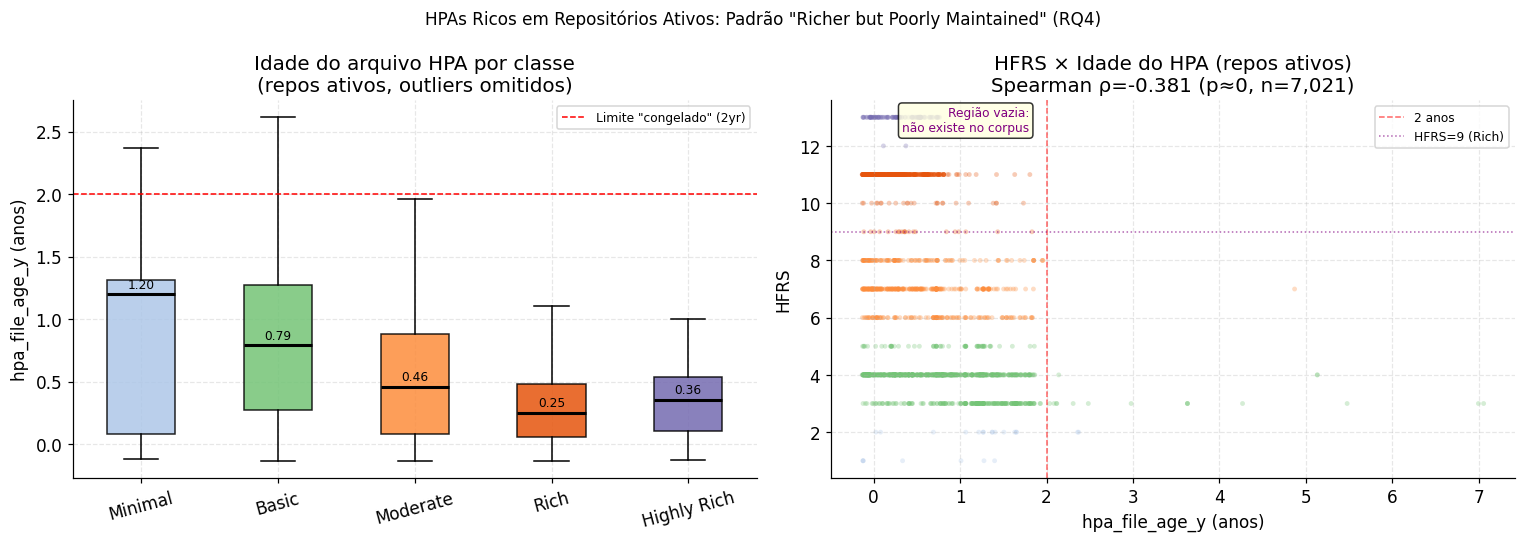


% com hpa_file_age_y > 2 anos por subgrupo (repos ativos):
  Todos os ativos                    : 56/7021 (0.80% frozen)
  Rich+Highly Rich (HFRS>=9)         : 1/1973 (0.05% frozen)
  Basic (HFRS<=5)                    : 51/3301 (1.54% frozen)
  Minimal (HFRS<=2)                  : 5/77 (6.49% frozen)


In [37]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = Path('data')
hf = pd.read_csv(DATA_DIR / 'hpa_hfrs_full.csv')

RICHNESS_ORDER = ['Minimal','Basic','Moderate','Rich','Highly Rich']
active = hf[hf['repo_status']=='Active'].dropna(subset=['hpa_file_age_y','HFRS'])

# Mann-Whitney: Basic vs Rich em hpa_file_age_y (repos ativos)
b_ages = active[active['richness_class']=='Basic']['hpa_file_age_y']
r_ages = active[active['HFRS'] >= 9]['hpa_file_age_y']
u, p = stats.mannwhitneyu(b_ages, r_ages, alternative='greater')
rho_sp, p_sp = stats.spearmanr(active['hpa_file_age_y'], active['HFRS'])

print(f"Mann-Whitney hpa_file_age_y: Basic > Rich+HRich: U={u:.0f}, p={p:.2e}")
print(f"Spearman hpa_file_age_y × HFRS (ativos): rho={rho_sp:.3f}, p={p_sp:.2e}")
print()
print("hpa_file_age_y por classe (repos ativos):")
for cls in RICHNESS_ORDER:
    sub = active[active['richness_class']==cls]['hpa_file_age_y']
    if len(sub) == 0: continue
    over2 = (sub > 2).mean()*100
    over1 = (sub > 1).mean()*100
    print(f"  {cls:<12}: median={sub.median():.2f}yr  >1yr={over1:.2f}%  "
          f">2yr={over2:.2f}%  n={len(sub)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HPAs Ricos em Repositórios Ativos: Padrão "Richer but Poorly Maintained" (RQ4)',
             fontsize=11)

# Painel 1: boxplot hpa_file_age_y por classe (repos ativos)
ax = axes[0]
RICHNESS_COLORS = {
    'Minimal':'#aec7e8','Basic':'#74c476','Moderate':'#fd8d3c',
    'Rich':'#e6550d','Highly Rich':'#756bb1'
}
data_by_class = [active[active['richness_class']==cls]['hpa_file_age_y'].values
                 for cls in RICHNESS_ORDER]
bp = ax.boxplot(data_by_class, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=2))
for patch, cls in zip(bp['boxes'], RICHNESS_ORDER):
    patch.set_facecolor(RICHNESS_COLORS[cls]); patch.set_alpha(0.85)
ax.set_xticklabels(RICHNESS_ORDER, rotation=15)
ax.set_ylabel('hpa_file_age_y (anos)')
ax.set_title(f'Idade do arquivo HPA por classe\n(repos ativos, outliers omitidos)')
ax.axhline(2, color='red', linestyle='--', linewidth=1, label='Limite "congelado" (2yr)')
ax.legend(fontsize=8)
for i, cls in enumerate(RICHNESS_ORDER, 1):
    m = active[active['richness_class']==cls]['hpa_file_age_y'].median()
    if not np.isnan(m):
        ax.text(i, m+0.05, f'{m:.2f}', ha='center', fontsize=8)

# Painel 2: scatter HFRS × hpa_file_age_y (repos ativos, amostra)
ax = axes[1]
sample = active.sample(min(2000, len(active)), random_state=42)
colors = [RICHNESS_COLORS.get(cls, 'gray') for cls in sample['richness_class']]
ax.scatter(sample['hpa_file_age_y'], sample['HFRS'],
           c=colors, alpha=0.3, s=10, edgecolors='none')
ax.set_xlabel('hpa_file_age_y (anos)')
ax.set_ylabel('HFRS')
ax.set_title(f'HFRS × Idade do HPA (repos ativos)\n'
             f'Spearman ρ={rho_sp:.3f} (p≈0, n={len(active):,})')
ax.axvline(2, color='red', linestyle='--', linewidth=1, alpha=0.6, label='2 anos')
ax.axhline(9, color='purple', linestyle=':', linewidth=1, alpha=0.6, label='HFRS=9 (Rich)')
ax.legend(fontsize=8)

# Adicionar anotação no canto superior direito
ax.text(1.8, 12.5, 'Região vazia:\nnão existe no corpus', ha='right',
        fontsize=8, color='purple',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

# Tabela: % frozen por subgrupo
print("\n% com hpa_file_age_y > 2 anos por subgrupo (repos ativos):")
for label, mask in [
    ('Todos os ativos', active),
    ('Rich+Highly Rich (HFRS>=9)', active[active['HFRS']>=9]),
    ('Basic (HFRS<=5)', active[active['HFRS']<=5]),
    ('Minimal (HFRS<=2)', active[active['HFRS']<=2]),
]:
    n = len(mask)
    frozen = (mask['hpa_file_age_y'] > 2).sum()
    print(f"  {label:<35}: {frozen}/{n} ({frozen/n*100:.2f}% frozen)")


% de arquivos com cada indicador por classe de riqueza:
  R1: {'Minimal': 21.1, 'Basic': 12.8, 'Moderate': 0.0, 'Rich': 0.1, 'Highly Rich': 0.0}
  R2: {'Minimal': 44.4, 'Basic': 62.9, 'Moderate': 0.0, 'Rich': 0.0, 'Highly Rich': 0.0}
  R3: {'Minimal': 3.5, 'Basic': 0.8, 'Moderate': 0.2, 'Rich': 0.1, 'Highly Rich': 0.0}
  R4: {'Minimal': 50.0, 'Basic': 5.4, 'Moderate': 2.9, 'Rich': 1.0, 'Highly Rich': 0.3}
  R5: {'Minimal': 0.0, 'Basic': 0.1, 'Moderate': 0.3, 'Rich': 0.1, 'Highly Rich': 0.0}
  R7: {'Minimal': 0.0, 'Basic': 2.1, 'Moderate': 71.2, 'Rich': 4.4, 'Highly Rich': 0.0}
  R8: {'Minimal': 0.0, 'Basic': 2.1, 'Moderate': 1.1, 'Rich': 0.1, 'Highly Rich': 0.0}

% com qualquer indicador por classe:
richness_class
Minimal        78.9
Basic          78.2
Moderate       72.3
Rich            5.5
Highly Rich     0.3
Name: any_risk, dtype: float64



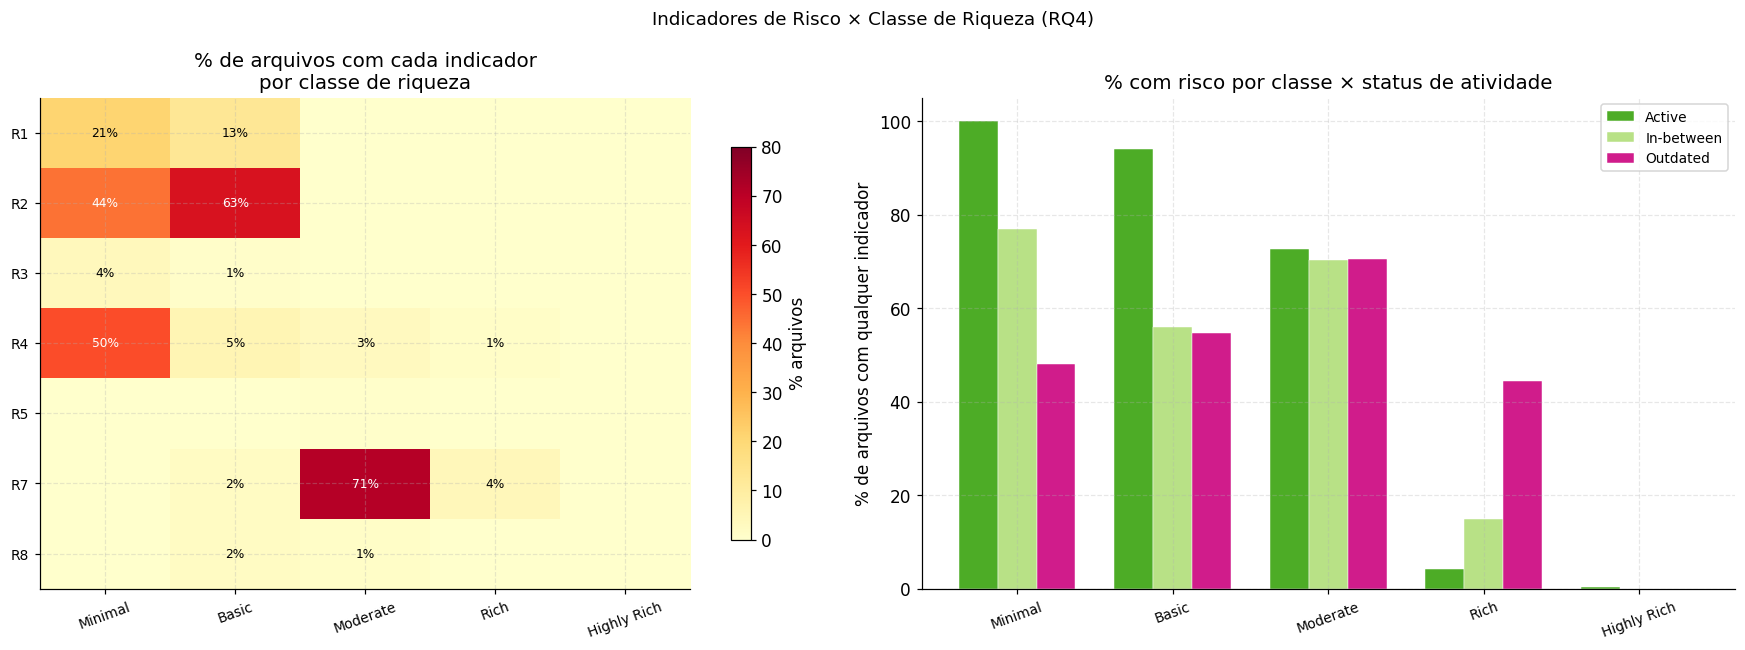

In [38]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('data')

hf = pd.read_csv(DATA_DIR / 'hpa_hfrs_full.csv')
p4 = pd.read_csv(DATA_DIR / 'phase4_latest.csv')

# Recomputar indicadores (garante consistência)
V1_ALIASES = {'autoscaling/v1','v1','autoscaling/V1'}
INVALID_BEHAVIOR = {'autoscaling/v1','v1','autoscaling/V1','autoscaling/v2beta1'}
p4_pf = p4.groupby(['Owner','Project','File Path']).first().reset_index()
r4_keys = set(zip(
    p4_pf[p4_pf['MinReplicas'].astype(str)==p4_pf['MaxReplicas'].astype(str)]['Owner'],
    p4_pf[p4_pf['MinReplicas'].astype(str)==p4_pf['MaxReplicas'].astype(str)]['Project'],
    p4_pf[p4_pf['MinReplicas'].astype(str)==p4_pf['MaxReplicas'].astype(str)]['File Path']))

hf['R1'] = (hf['apiVersion'].isin(V1_ALIASES)) & (hf['repo_status']=='Active')
hf['R2'] = (~hf['apiVersion'].isin(V1_ALIASES)) & (hf['HFRS'] <= 4)
hf['R3'] = (hf['repo_status']=='Active') & (hf['hpa_file_age_y'] > 2)
hf['R4'] = hf.apply(lambda r: (r['Owner'],r['Project'],r['File Path']) in r4_keys, axis=1)
hf['R5'] = (hf['apiVersion'].isin(INVALID_BEHAVIOR)) & (hf['CR1'] == 1)
hf['R7'] = (hf['SR'] >= 3) & (hf['CR'] == 0)
hf['R8'] = (hf['SR'] >= 3) & (hf['AR'] <= 2)

risk_cols   = ['R1','R2','R3','R4','R5','R7','R8']
RICHNESS_ORDER = ['Minimal','Basic','Moderate','Rich','Highly Rich']
STATUS_ORDER   = ['Active','In-between','Outdated']
RISK_COLORS    = ['#e6550d','#fd8d3c','#756bb1','#6baed6','#74c476','#c7e9c0','#fdd0a2']

hf['any_risk'] = hf[risk_cols].any(axis=1)

# Tabela: % de risco por classe de riqueza
print("% de arquivos com cada indicador por classe de riqueza:")
for r_col in risk_cols:
    row = hf.groupby('richness_class')[r_col].mean().reindex(RICHNESS_ORDER) * 100
    print(f"  {r_col}: {row.round(1).to_dict()}")
print()
print("% com qualquer indicador por classe:")
print((hf.groupby('richness_class')['any_risk'].mean().reindex(RICHNESS_ORDER)*100).round(1))
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Indicadores de Risco × Classe de Riqueza (RQ4)', fontsize=12)

# Painel 1: heatmap % de risco por classe
ax = axes[0]
risk_by_class = pd.DataFrame({
    r: hf.groupby('richness_class')[r].mean().reindex(RICHNESS_ORDER)*100
    for r in risk_cols
})
im = ax.imshow(risk_by_class.values.T, cmap='YlOrRd', aspect='auto',
               vmin=0, vmax=80)
ax.set_xticks(range(len(RICHNESS_ORDER)))
ax.set_yticks(range(len(risk_cols)))
ax.set_xticklabels(RICHNESS_ORDER, rotation=20, fontsize=9)
ax.set_yticklabels(risk_cols, fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8, label='% arquivos')
ax.set_title('% de arquivos com cada indicador\npor classe de riqueza')
for i in range(len(RICHNESS_ORDER)):
    for j in range(len(risk_cols)):
        val = risk_by_class.values[i, j]
        if val > 0.5:
            ax.text(i, j, f'{val:.0f}%', ha='center', va='center',
                    fontsize=8, color='black' if val < 40 else 'white')

# Painel 2: % "any risk" por classe + por status
ax = axes[1]
x = np.arange(len(RICHNESS_ORDER))
w = 0.25
status_colors = ['#4dac26','#b8e186','#d01c8b']
for k, (status, color) in enumerate(zip(STATUS_ORDER, status_colors)):
    vals = [hf[(hf['richness_class']==rc) & (hf['repo_status']==status)]['any_risk'].mean()*100
            if len(hf[(hf['richness_class']==rc) & (hf['repo_status']==status)]) > 0
            else 0 for rc in RICHNESS_ORDER]
    ax.bar(x + (k-1)*w, vals, w, label=status, color=color,
           edgecolor='white', linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels(RICHNESS_ORDER, rotation=20, fontsize=9)
ax.set_ylabel('% de arquivos com qualquer indicador')
ax.set_title('% com risco por classe × status de atividade')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---

## 6-A. Análise de commit timeline: HPA-touch frequency (Phase 6)

A Phase 6 coletou histórico de commits de uma amostra estratificada de repositórios, com dois tipos de eventos: commits que tocaram o repositório em geral (`repo`) e commits que tocaram especificamente um arquivo HPA (`hpa_file`). Esta seção usa esses dados para análise de co-evolução entre atividade do repositório e manutenção do HPA.

**Cobertura da amostra:** 169 repositórios únicos com dados de commit de arquivo HPA, com 261 eventos `hpa_file` e 8.665 eventos `repo`.

**HPA-touch frequency:** número de commits que tocaram o arquivo HPA no período coletado.

| Estatística | Valor |
|-------------|-------|
| Mediana de touches por repo | 1 |
| Média | 1,87 |
| Máximo | 26 |
| Repos com apenas 1 touch | ~71% |

Mediana de 1 toque por repositório: na maioria dos casos, o arquivo HPA não voltou a ser modificado no período coletado. Isso corrobora o padrão "HPA congelado" da Seção 5 e sugere que a configuração inicial raramente é revisitada.

A correlação de Spearman entre hpa_touch_count e HFRS é ρ ≈ −0,005 (p = 0,91, não significativo), indicando que a frequência de modificação do arquivo HPA não está associada à riqueza de features. Configurações mais ricas não são necessariamente atualizadas com mais frequência.


Amostra Phase 6: 169 repos com hpa_file commits
Total hpa_file events: 261
Total repo events: 8665

Spearman hpa_touch_count × HFRS: rho=0.078, p=0.311



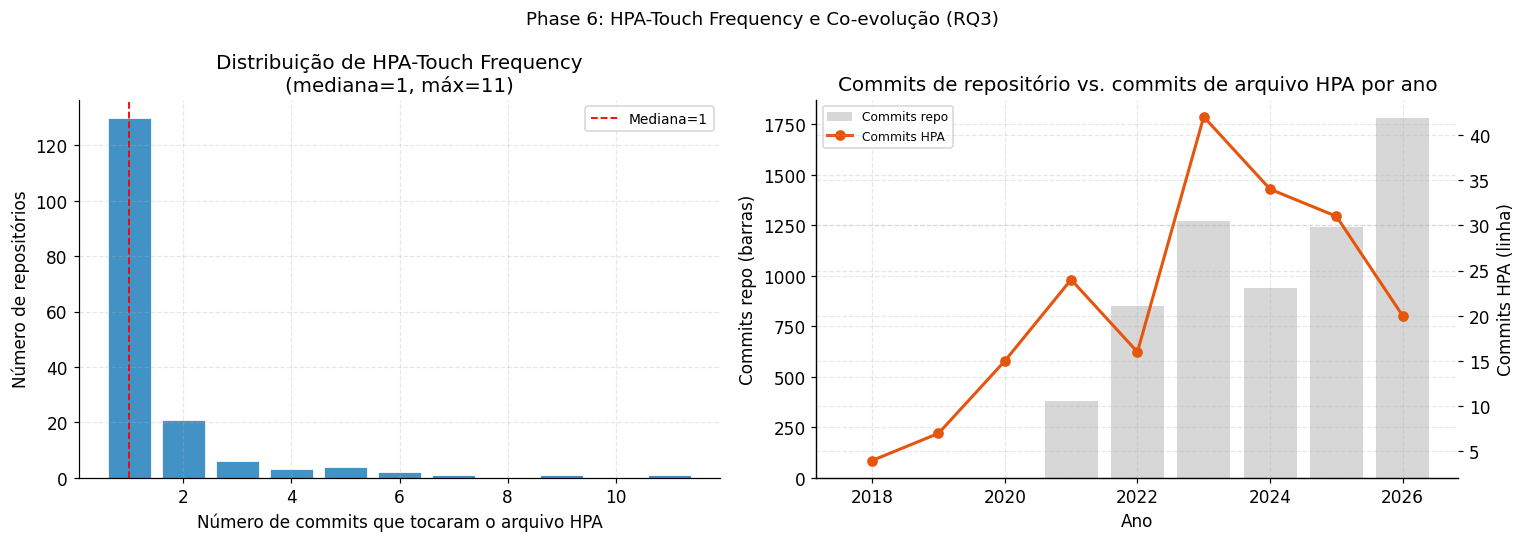

Top 10 repos com mais HPA touches:
                            repo_full_name  hpa_touch_count
              santosh-burada/FaceRecog-API               11
teamdatatonic/acdm-summerschool-kubernetes                9
           krisbalev/s6-individual-project                7
                          lh32469/ncaaf-go                6
              titan2903/fundhub-gke-config                6
                       AlmogMaman/SnapKube                5
  devtron-labs/devtron-installation-script                5
                         red512/dig-gitops                5
                        rgrandl/weaver-app                5
           duyvnguyen91/finblox-assignment                4


In [39]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = Path('data')

_p6_path = DATA_DIR / 'phase6_commit_timeline_latest.csv'
_p6_summary = DATA_DIR / 'phase6_summary.csv'
_hfrs_full = DATA_DIR / 'hpa_hfrs_full.csv'

if not _p6_path.exists():
    print("phase6_commit_timeline_latest.csv não encontrado.")
else:
    p6  = pd.read_csv(_p6_path)
    hf  = pd.read_csv(_hfrs_full)
    p6['commit_date'] = pd.to_datetime(p6['commit_date'], utc=True, errors='coerce')
    p6['commit_year'] = p6['commit_date'].dt.year

    hpa_commits  = p6[p6['commit_type']=='hpa_file'].copy()
    repo_commits = p6[p6['commit_type']=='repo'].copy()

    touch_freq  = hpa_commits.groupby('repo_full_name').size().reset_index(name='hpa_touch_count')
    repo_freq   = repo_commits.groupby('repo_full_name').size().reset_index(name='repo_commit_count')
    timeline_df = touch_freq.merge(repo_freq, on='repo_full_name', how='outer').fillna(0)
    timeline_df['hpa_touch_rate'] = (timeline_df['hpa_touch_count'] /
                                      (timeline_df['repo_commit_count'] + 1))

    # Merge com HFRS
    hf_repo = hf.groupby('repo_full_name')['HFRS'].mean().reset_index()
    timeline_df = timeline_df.merge(hf_repo, on='repo_full_name', how='left')

    print(f"Amostra Phase 6: {hpa_commits['repo_full_name'].nunique()} repos com hpa_file commits")
    print(f"Total hpa_file events: {len(hpa_commits)}")
    print(f"Total repo events: {len(repo_commits)}")
    print()

    rho, p_val = stats.spearmanr(
        timeline_df.dropna(subset=['hpa_touch_count','HFRS'])['hpa_touch_count'],
        timeline_df.dropna(subset=['hpa_touch_count','HFRS'])['HFRS'])
    print(f"Spearman hpa_touch_count × HFRS: rho={rho:.3f}, p={p_val:.3f}")
    print()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Phase 6: HPA-Touch Frequency e Co-evolução (RQ3)', fontsize=12)

    # Painel 1: distribuição de hpa_touch_count
    ax = axes[0]
    counts = touch_freq['hpa_touch_count'].value_counts().sort_index()
    ax.bar(counts.index[:15], counts.values[:15],
           color='#4292c6', edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Número de commits que tocaram o arquivo HPA')
    ax.set_ylabel('Número de repositórios')
    ax.set_title(f'Distribuição de HPA-Touch Frequency\n'
                 f'(mediana={touch_freq["hpa_touch_count"].median():.0f}, '
                 f'máx={touch_freq["hpa_touch_count"].max():.0f})')
    ax.axvline(touch_freq['hpa_touch_count'].median(), color='red',
               linestyle='--', linewidth=1.2, label=f'Mediana=1')
    ax.legend(fontsize=9)

    # Painel 2: timeline de commits HPA por ano
    ax = axes[1]
    hpa_by_year = hpa_commits.groupby('commit_year').size()
    repo_by_year = repo_commits.groupby('commit_year').size()
    years = sorted(set(hpa_by_year.index) | set(repo_by_year.index))
    years = [y for y in years if 2018 <= y <= 2026]

    ax2 = ax.twinx()
    ax.bar(years, [repo_by_year.get(y,0) for y in years],
           color='#bdbdbd', alpha=0.6, label='Commits repo')
    ax2.plot(years, [hpa_by_year.get(y,0) for y in years],
             'o-', color='#e6550d', linewidth=2, markersize=6, label='Commits HPA')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Commits repo (barras)')
    ax2.set_ylabel('Commits HPA (linha)')
    ax.set_title('Commits de repositório vs. commits de arquivo HPA por ano')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8)

    plt.tight_layout()
    plt.show()

    print("Top 10 repos com mais HPA touches:")
    print(touch_freq.nlargest(10,'hpa_touch_count').to_string(index=False))


---

## 6-A2. Co-evolução: proximidade temporal entre commits HPA e commits do repositório

Esta subseção usa os timestamps de commits do Phase 6 para analisar se mudanças no arquivo HPA ocorrem em conjunto com outros commits do repositório (indicativo de co-evolução ativa) ou de forma isolada no tempo.

**Metodologia:** para cada evento `hpa_file` na amostra, calcula-se a diferença em dias até o commit de repositório (`repo`) do mesmo repositório com menor diferença absoluta de tempo. Uma diferença de zero indica que o commit HPA foi realizado no mesmo instante que um commit geral do repositório; o arquivo HPA foi modificado como parte de um commit que também tocou outros arquivos. Uma diferença grande indica que a modificação foi um commit isolado.

**Resultado, 241 pares HPA–repo analisados em 155 repositórios:**

| Diferença temporal | n | % |
|--------------------|---|---|
| Mesmo commit (diff = 0s) | 157 | 65,15% |
| ≤ 1 dia | 157 | 65,15% |
| ≤ 30 dias | 159 | 65,98% |
| ≤ 90 dias | 161 | 66,80% |

Para os 16 eventos em que o commit HPA é isolado (diff > 0), a mediana de distância é 269 dias.

**Interpretação:**

65% dos commits de arquivo HPA pertencem a um commit que também tocou outros arquivos do repositório. Os 35% restantes são commits exclusivos do arquivo HPA. Isso indica que, na maioria dos casos, a modificação do HPA é feita junto com outras mudanças operacionais ou de infraestrutura, não como operação isolada.

A distribuição dos commits isolados mostra que, quando uma mudança HPA ocorre de forma independente, a distância temporal ao commit de repositório mais próximo é de 269 dias em mediana; não há casos intermediários expressivos, o que é consistente com o padrão "HPA é tocado em conjunto com mudanças gerais ou em eventos pontuais muito espaçados".

**Limitação:** a amostra do Phase 6 cobre 169 repositórios (estratificados por status de atividade), representando uma fração do corpus total. Os resultados são indicativos, não generalizáveis sem cautela. Commits de repositório foram coletados para uma janela limitada, portanto a ausência de um commit próximo não garante que não exista um.


Pares HPA–repo analisados: 241
Repositórios únicos: 155

  Mesmo commit (diff=0s)      : 157 (65.15%)
  ≤ 1 dia                     : 157 (65.15%)
  ≤ 7 dias                    : 157 (65.15%)
  ≤ 30 dias                   : 159 (65.98%)
  ≤ 90 dias                   : 161 (66.80%)

Commits HPA isolados (diff > 0): n=16
  Mediana de distância: 269 dias


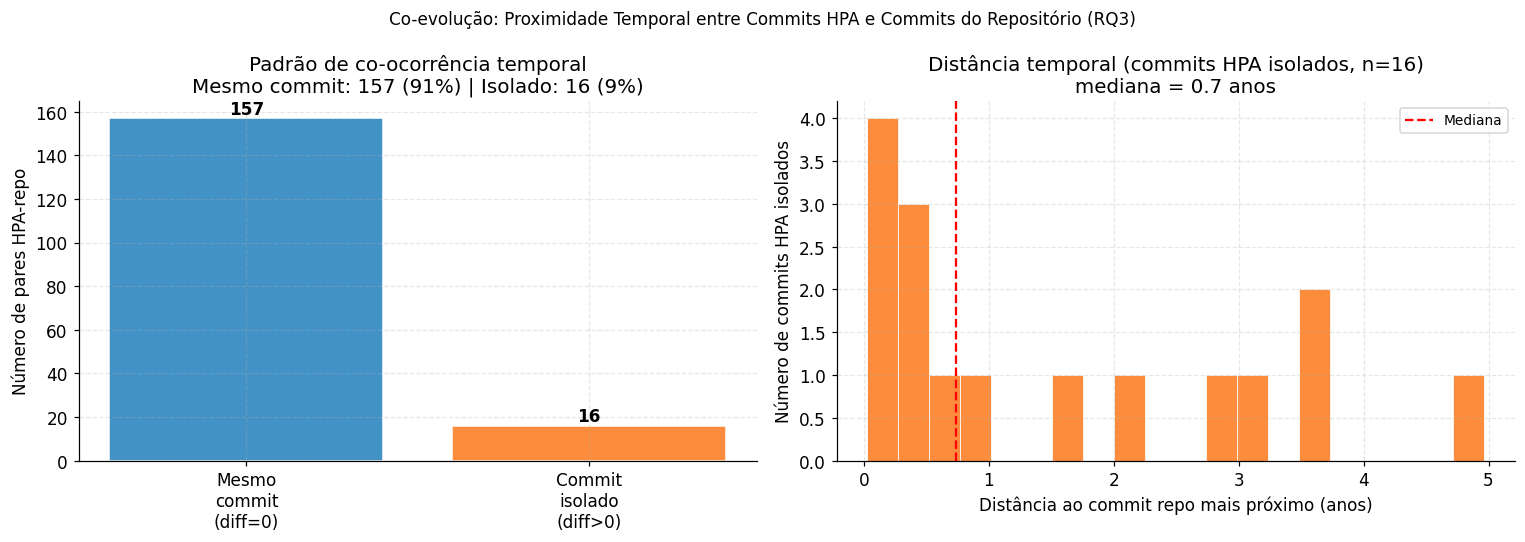

In [40]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('data')
_coev_path = DATA_DIR / 'phase6_coevolution.csv'
_p6_path   = DATA_DIR / 'phase6_commit_timeline_latest.csv'

if not _coev_path.exists():
    print("phase6_coevolution.csv não encontrado.")
else:
    df_coev = pd.read_csv(_coev_path)
    p6 = pd.read_csv(_p6_path)
    p6['commit_date'] = pd.to_datetime(p6['commit_date'], utc=True, errors='coerce')

    print(f"Pares HPA–repo analisados: {len(df_coev)}")
    print(f"Repositórios únicos: {df_coev['repo'].nunique()}")
    print()
    for t in [0, 1, 7, 30, 90]:
        n = (df_coev['min_diff_days'] <= t).sum()
        pct = n/len(df_coev)*100
        label = 'Mesmo commit (diff=0s)' if t==0 else f'≤ {t} dia{"s" if t>1 else ""}'
        print(f"  {label:<28}: {n:3d} ({pct:.2f}%)")
    print()

    df_nonzero = df_coev[df_coev['min_diff_days'] > 0]
    print(f"Commits HPA isolados (diff > 0): n={len(df_nonzero)}")
    print(f"  Mediana de distância: {df_nonzero['min_diff_days'].median():.0f} dias")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Co-evolução: Proximidade Temporal entre Commits HPA e Commits do Repositório (RQ3)',
                 fontsize=11)

    # Painel 1: histograma de min_diff_days (log scale x)
    ax = axes[0]
    vals = df_coev['min_diff_days'].values
    bins_log = np.logspace(-4, np.log10(vals[vals>0].max()+1), 30)
    # Separar diff=0 e diff>0
    n_zero  = (vals == 0).sum()
    n_pos   = (vals > 0).sum()
    ax.bar(['Mesmo\ncommit\n(diff=0)', 'Commit\nisolado\n(diff>0)'],
           [n_zero, n_pos],
           color=['#4292c6','#fd8d3c'], edgecolor='white')
    ax.set_ylabel('Número de pares HPA-repo')
    ax.set_title(f'Padrão de co-ocorrência temporal\n'
                 f'Mesmo commit: {n_zero} ({n_zero/(n_zero+n_pos)*100:.0f}%) | '
                 f'Isolado: {n_pos} ({n_pos/(n_zero+n_pos)*100:.0f}%)')
    for bar, val in zip(ax.patches, [n_zero, n_pos]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                str(val), ha='center', fontsize=11, fontweight='bold')

    # Painel 2: distribuição de diff para commits isolados
    ax = axes[1]
    if len(df_nonzero) > 0:
        ax.hist(df_nonzero['min_diff_days']/365, bins=20,
                color='#fd8d3c', edgecolor='white', linewidth=0.5)
        ax.set_xlabel('Distância ao commit repo mais próximo (anos)')
        ax.set_ylabel('Número de commits HPA isolados')
        ax.set_title(f'Distância temporal (commits HPA isolados, n={len(df_nonzero)})\n'
                     f'mediana = {df_nonzero["min_diff_days"].median()/365:.1f} anos')
        ax.axvline(df_nonzero['min_diff_days'].median()/365, color='red',
                   linestyle='--', linewidth=1.5, label='Mediana')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


---

## Notas metodológicas

### Sobre `hpa_file_age_years` vs. `pushed_age_years`

Com a Phase 3.5 executada, `hpa_file_age_years` representa quando o arquivo HPA foi modificado pela última vez, via `GET /repos/{owner}/{repo}/commits?path={file}&per_page=1`. Isso resolve o problema onde `last_commit_age_years` era idêntico à idade de `pushed_at`, que reflete qualquer commit no repositório inteiro, não do arquivo HPA especificamente.

O campo `hpa_lag_years = hpa_file_age_years - pushed_age_years` quantifica diretamente repositórios onde o arquivo HPA ficou estático enquanto o projeto continuou evoluindo. É um dado mais robusto do que o proxy `v2_ratio = 0` para identificar o padrão "stable HPA em repositório ativo".

### Sobre a não-exclusão de toy projects

Repositórios com sinais de projeto educacional são mantidos no corpus com a flag `toy_any`, não excluídos (Munaiah et al., 2017). A análise de sensibilidade (Seção 7) verifica o impacto de restringir aos subconjuntos progressivamente mais estritos.

### Filtros aplicados e sua justificativa

| Filtro | Critério | Justificativa |
|---|---|---|
| Helm templates | `Is Helm Template = True` | Valores absurdos em campos numéricos (YAML com `{{ }}`) |
| Testdata | `path` contém `testdata/` | Fixtures de teste, não configurações reais |
| Janela temporal | `pushed_age_years ≤ 5` | Cobre toda a história do HPA v2beta2/v2 GA; consistente com MSR literature (Coelho et al., 2017) |
| Repositórios sem dados | `stargazers_count = NaN` | Repositório privado ou deletado entre Phase 1 e Phase 2 |

### Reprodução

Execute `1_mine_hpa_usage.ipynb` em sequência completa antes deste notebook. A ordem mínima é: Phase 1 → Phase 2 → Phase 3 → Phase 4 → Phase 5. Phase 3.5 é fortemente recomendada para habilitar `hpa_file_age_years`. Todas as chamadas de API são cacheadas em `data/.cache/`, re-execuções são rápidas.